In [1]:
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh

from wsapi import * 
from scipy.signal import find_peaks


def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    wsh.apply_profile(new_profile)

    # Step 6: Apply missagh profile to waveshaper
    # gaussian_wave = wsh.gaussian(mu=wsh.nm2thz(1552.4), peak=1, phase=0, sigma=0.4)  
    # bound_gaussian = wsh.BoundFunc(gaussian_wave, wsh.nm2thz(1553.8), wsh.nm2thz(1551), 8)
    # missagh_profile = wsh.compose_func((0, 0, 0), wsh.nm2thz(1553.8), wsh.nm2thz(1551), 1e-3, bound_gaussian)
    # wsh.apply_profile(missagh_profile)  

class CustomLayer(nn.Module):
    def __init__(self, comblines):
        super(CustomLayer, self).__init__()
        self.phi = nn.Parameter(torch.zeros(len(comblines)))

    def forward(self, C, phase, normalization):
        phase = torch.squeeze(phase)
        return self.physical_model(phase[:C.shape[1]], C)
    
    def physical_model(self, phases, coefficients):
        N = coefficients.size(1)
        z = 1
        zero_tensor = torch.full((coefficients.size(0), 1), float(0), dtype=coefficients.dtype, device=coefficients.device)
        C = torch.cat((zero_tensor, coefficients), dim=1)

        k = torch.cat((torch.tensor([float(0)], dtype=phases.dtype, device=phases.device), phases))

        # Preallocate intensity tensor
        intensity = torch.zeros((coefficients.size(0), 2 * N + 1), dtype=torch.float, device=C.device)

        # Use vectorized operations where possible
        m_range = [torch.full((N-1, N-1), i, device=C.device) for i in torch.arange(2, 2 * N + 1)]
        # Separate odd and even tensors based on the integer value inside the tensor
        odd_m = [m for m in m_range if m[0, 0].item() % 2 == 1]
        even_m = [m for m in m_range if m[0, 0].item() % 2 == 0]

        js, ls = torch.meshgrid(torch.arange(1, N, device=C.device), torch.arange(1, N, device=C.device), indexing='ij')
        for m in odd_m:

            valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)

            j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]

            term = 4 * C[:, j] * C[:, m - j] * C[:, l] * C[:, m - l] * torch.exp(1j * (k[j] + k[m - j] - k[l] - k[m - l]) * z)
            intensity[:, m[0]] = term.sum(dim=1)

        for m in even_m:
            if m[0, 0] == 2 or m[0, 0] == 2 * N:
                intensity[:, m[0, 0]] = C[:, m[0, 0] // 2] ** 4
            else:
                valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)

                j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]

                exp_term = torch.exp(1j * (k[j] + k[m - j]) * z)
                middle_term = C[:, m // 2] ** 2 * torch.exp(1j * 2 * k[m // 2] * z)

                term1 = (2 * C[:, j] * C[:, m - j] * exp_term + middle_term).sum(dim=1)
                term2 = (2 * C[:, l] * C[:, m - l] * exp_term.conj() + middle_term.conj()).sum(dim=1)

                intensity[:, m[0]] = (term1 * term2).real
        
        return torch.abs(intensity[:, 2:2 * N + 1])


import os 

def create_folders(name):
    base_path = os.path.join("data_runs", name)
    stability_path = os.path.join(base_path, "stability")
    checkpoints_path = os.path.join(base_path, "checkpoints")
    traces_path = os.path.join(base_path, "traces")

    os.makedirs(stability_path, exist_ok=True)
    os.makedirs(checkpoints_path, exist_ok=True)
    os.makedirs(traces_path, exist_ok=True)

    print(f"Folders ensured:\n- {stability_path}\n- {checkpoints_path}\n- {traces_path}")


In [2]:
import torch
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from skimage.filters import threshold_otsu


IMAGE_SIZE = 14  # Fashion MNIST image size (28x28)

# Custom transformation that applies Otsu's thresholding
class OtsuBinarize(object):
    def __call__(self, image):
        image_np = image.squeeze().numpy()
        thresh = threshold_otsu(image_np)
        binary_np = (image_np > thresh).astype(np.float32)
        return torch.from_numpy(binary_np).unsqueeze(0)

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.NEAREST) #OtsuBinarize(),transforms.Normalize(mean=[0.5], std=[0.5])
])

#train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
# Get indices for samples with label 4 ("object")
desired_digits = [0,1,5]
object_indices = [i for i, (_, label) in enumerate(train_dataset) if label in desired_digits]

# Specify the number of object samples you want
n = 18 #40  # replace with any number you desire

# Select the first n object indices
selected_object_indices = object_indices[:n]

# Create a subset of the dataset containing only the selected objects
object_dataset = Subset(train_dataset, selected_object_indices)

# Optionally, create a DataLoader for the subset
train_loader = DataLoader(object_dataset, batch_size=1, shuffle=True)

# # Now, train_loader will yield batches containing only object images.

# import matplotlib.pyplot as plt

# for i in range(32):# Extract one sample from the object_dataset
#     sample, label = object_dataset[i]

#     # Display the image
#     plt.imshow(sample.squeeze(), cmap='gray')
#     plt.title("object Sample")
#     plt.axis("off")
#     plt.show()


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   success
Connecting to waveshaper...   success
Applying profile...   success
Sweep complete.


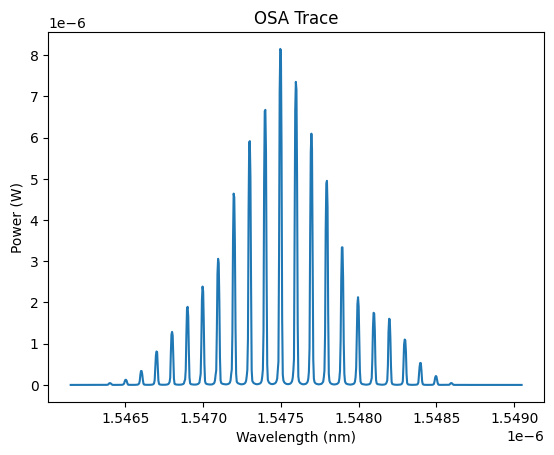

Sweep complete.


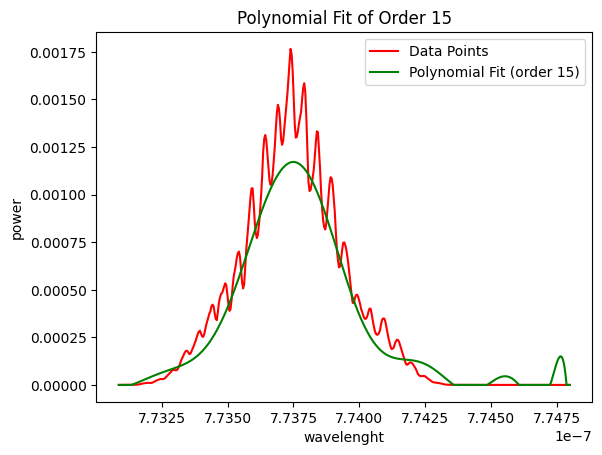

number of maximum points 23
-19.500241288968112
Applying profile...   success
Sweep complete.


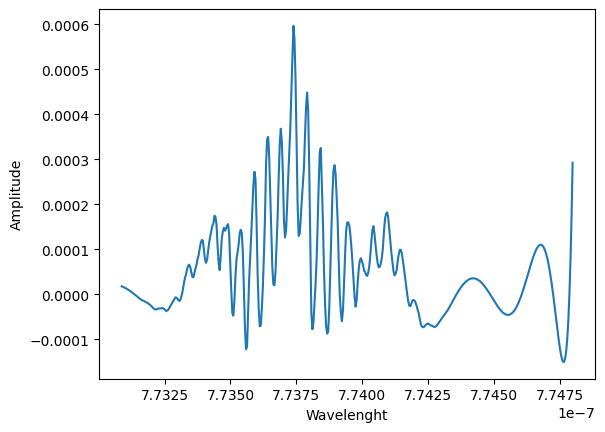

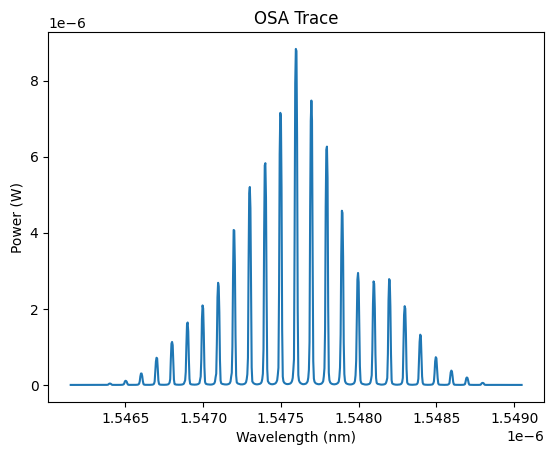

Sweep complete.


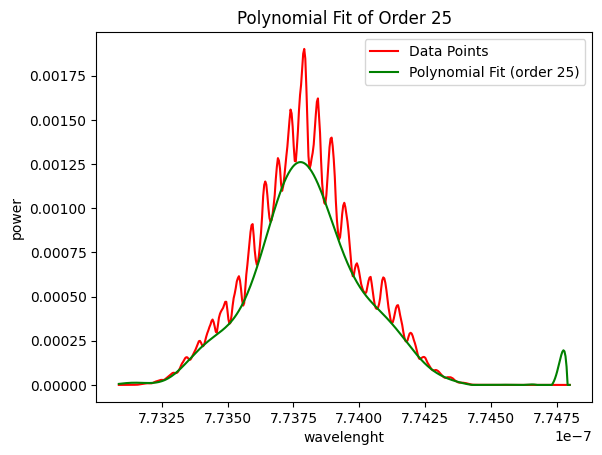

number of maximum points 28
-495.92558222790757


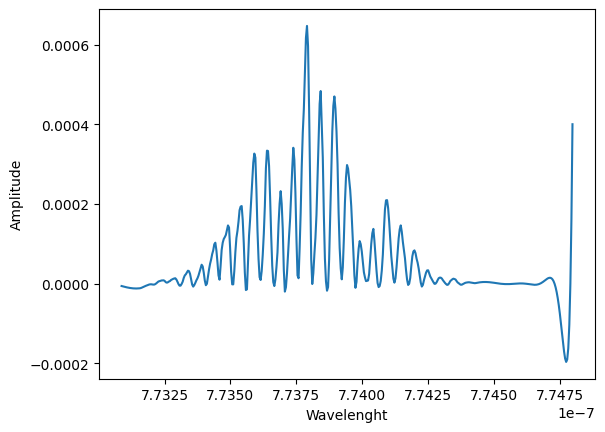

In [3]:
# Connecting to the OSA and Waveshaper, verifying correct behaviour
from osa import OSA
from pat import make_pat_func
import calibration

# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()

# Create a Model
n_comblines = [12, 13]
separation_comblines = 0.2
initial_wl = 1549.598-separation_comblines*16

comblines = [np.arange(initial_wl, initial_wl + i * separation_comblines, separation_comblines) for i in n_comblines]

peaks = [np.ones(n_comblines[i]) for i in range(len(n_comblines))]
channels = [np.ones(n_comblines[i]) for i in range(len(n_comblines))]
phases = [np.zeros(n_comblines[i]) for i in range(len(n_comblines))]
initrang = [122, 122]
finrang = [700, 910]
order = [15, 25]

wavelength_trim = []
poly = []
normalization = []
fraction_m_m = []

for i in range(len(n_comblines)):
    apply_waveshaper_profile(comblines[i], peaks[i], phases[i], channels[i], plot = False)
    wavelengths, power = osa.perform_measurement_OSA(np.mean(comblines[i]), (np.max(comblines[i])-np.mean(comblines[i]))*2+0.5, 0.02, sensitivity = "high3", resolution = 0.02)
    osa.plot_trace(wavelengths, power)

    # Perform calibration
    wavelength, power, polynomial = calibration.do_calibration(osa, center=np.mean(comblines[i])/2-0.1, span=(np.max(comblines[i])-np.mean(comblines[i]))+1, order = order[i], level=2, spacing='lin')
    poly.append(polynomial)
    powerfit = polynomial(wavelength)

    calibration.plot_polynomial_fit(wavelength[initrang[i]:finrang[i]], power[initrang[i]:finrang[i]], wavelength[initrang[i]:finrang[i]], powerfit[initrang[i]:finrang[i]], order=order[i])

    prominence = power - powerfit
    prominence = prominence[initrang[i]:finrang[i]]
    wavelength = wavelength[initrang[i]:finrang[i]]
    wavelength_trim.append(wavelength)
    max_indices, _ = find_peaks(prominence, distance=5, prominence=1e-8)
    print(f'number of maximum points {len(max_indices)}')
    max_x = np.array(wavelength)[max_indices]
    max_y = np.array(prominence)[max_indices]

    fraction_max_min = np.max(max_y)/(max_y[0])
    norm = np.max(power)#1/(fraction_max_min*max_y[0])
    normalization.append(norm)
    fraction_m_m.append(fraction_max_min)
    
    print(fraction_max_min)
    plt.plot(wavelength,prominence)
    plt.xlabel('Wavelenght')
    plt.ylabel('Amplitude')

In [4]:
def lambda_m(lambda_1, delta_lambda, m):
    return 1 / ((2 / lambda_1) - (m - 1) * (abs(delta_lambda) / lambda_1**2))

# Example usage
delta_lambda = separation_comblines  # Example value in nm
m = [np.arange(1,2*n_comblines[i],1) for i in range(len(n_comblines))]  # Example mode number

targets = [lambda_m(initial_wl, delta_lambda, m[i])* 1e-9 for i in range(len(n_comblines))]
print(f"λ_m = {targets}")

max_indices = [[np.argmin(np.abs(wavelength_trim[j] - t)) for t in targets[j]] for j in range(len(n_comblines))]
print(f"Indices {max_indices}")

# Custom PyTorch layer
class WaveshaperLayer(nn.Module):
    def __init__(self, osa, comblines, channels, baseline, initrang, finrang, max_indices, delta_l=0.1, sigma=0.005):
        super(WaveshaperLayer, self).__init__()
        
        self.osa = osa
        self.comblines = comblines
        self.channels = channels
        self.baseline = baseline
        self.delta_l = delta_l
        self.sigma = sigma
        self.initrang = initrang
        self.finrang = finrang
        self.max_indices = max_indices
        
        self.combline_thz = [wsh.nm2thz(combline) for combline in self.comblines]
        self.rang_min = [wsh.nm2thz(combline - delta_l) for combline in self.comblines]
        self.rang_max = [wsh.nm2thz(combline + delta_l) for combline in self.comblines]
        
        self.phases = nn.Parameter(torch.zeros(len(self.comblines)))
        
    def forward(self, peaks, phases, normalization):
        phases_slice = torch.squeeze(phases[:peaks.shape[1]])
        phase = phases_slice.cpu().numpy() if torch.is_tensor(phases_slice) else phases_slice
        peaks_slice = torch.squeeze(peaks[:peaks.shape[1]])
        peak = peaks_slice.cpu().numpy() if torch.is_tensor(peaks_slice) else peaks_slice
        #print(f"The injected phase is {phase} and peaks {peak}")

        apply_waveshaper_profile(self.comblines, peak, phase, self.channels)
        #print(f"mean {np.mean(self.comblines)/2-0.1}")

        wavelength, measurement = self.osa.perform_measurement_OSA(center=np.mean(self.comblines)/2-0.1, span=(np.max(self.comblines)-np.mean(self.comblines))+1, level=0.006, sensitivity = "high2", resolution = 0.02)
        prominence = measurement #- self.baseline(wavelength)
        prominence = calibration.set_measurement_outside_range_to_zero(wavelength, prominence, (np.min(self.comblines)/2-0.3)*1e-9, (np.max(self.comblines)/2+0.3)*1e-9)
        prominence_trim = prominence[self.initrang:self.finrang]
        
        max_y = np.array(prominence_trim)[self.max_indices]
        #plt.plot(prominence)
        #print(f"now normalization {self.normalization}")
        max_y_tensor = (torch.tensor(max_y, dtype=torch.float32)/normalization)
        
        return torch.unsqueeze(max_y_tensor,0)

λ_m = [array([7.73199000e-07, 7.73249003e-07, 7.73299013e-07, 7.73349029e-07,
       7.73399052e-07, 7.73449081e-07, 7.73499116e-07, 7.73549159e-07,
       7.73599207e-07, 7.73649262e-07, 7.73699324e-07, 7.73749392e-07,
       7.73799466e-07, 7.73849547e-07, 7.73899634e-07, 7.73949728e-07,
       7.73999829e-07, 7.74049935e-07, 7.74100049e-07, 7.74150169e-07,
       7.74200295e-07, 7.74250428e-07, 7.74300567e-07]), array([7.73199000e-07, 7.73249003e-07, 7.73299013e-07, 7.73349029e-07,
       7.73399052e-07, 7.73449081e-07, 7.73499116e-07, 7.73549159e-07,
       7.73599207e-07, 7.73649262e-07, 7.73699324e-07, 7.73749392e-07,
       7.73799466e-07, 7.73849547e-07, 7.73899634e-07, 7.73949728e-07,
       7.73999829e-07, 7.74049935e-07, 7.74100049e-07, 7.74150169e-07,
       7.74200295e-07, 7.74250428e-07, 7.74300567e-07, 7.74350713e-07,
       7.74400865e-07])]
Indices [[np.int64(28), np.int64(41), np.int64(53), np.int64(66), np.int64(78), np.int64(91), np.int64(103), np.int64(116), np.int

In [7]:
layer0 = WaveshaperLayer(osa, comblines=comblines[0], channels=channels[0], baseline=poly[0], initrang = initrang[0], finrang = finrang[0], max_indices = max_indices[0])
layer1 = WaveshaperLayer(osa, comblines=comblines[1], channels=channels[1], baseline=poly[1], initrang = initrang[1], finrang = finrang[1], max_indices = max_indices[1])
physical_model0 = CustomLayer(comblines=comblines[0])
physical_model1 = CustomLayer(comblines=comblines[1])

pat_implementation0 = make_pat_func(layer0.forward, physical_model0.forward)
pat_implementation1 = make_pat_func(layer1.forward, physical_model1.forward)

LEARNING_RATE = 1e-3
EPOCHS = 15
CONDITION_DIM = 10
INPUT_DIM = IMAGE_SIZE * IMAGE_SIZE
HIDDEN_DIM1 = n_comblines[0]
LATENT_DIM = n_comblines[1]-CONDITION_DIM
HIDDEN_DIM2 =  2*n_comblines[1]-1

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(INPUT_DIM+CONDITION_DIM, HIDDEN_DIM1)
        self.ln1 = nn.LayerNorm(HIDDEN_DIM1)
        self.ln_out0 = nn.LayerNorm(2*HIDDEN_DIM1-1)
        self.fc_mu = nn.Linear(2*HIDDEN_DIM1-1, LATENT_DIM)
        #nn.init.normal_(self.fc_mu.weight, mean=0.0, std=0.001)
        #nn.init.normal_(self.fc_mu.bias, mean=0.0, std=0.017) 
        self.fc_logvar = nn.Linear(2*HIDDEN_DIM1-1, LATENT_DIM)  
        #nn.init.normal_(self.fc_logvar.weight, mean=0.001, std=0.0155)
        #nn.init.normal_(self.fc_logvar.bias, mean=-2, std=0.1)      
        
        # Decoder
        self.fc2 = nn.Linear(LATENT_DIM+CONDITION_DIM, LATENT_DIM+CONDITION_DIM)
        self.ln2 = nn.LayerNorm(LATENT_DIM+CONDITION_DIM)

        self.ln_out1 = nn.LayerNorm(HIDDEN_DIM2)
        nn.init.normal_(self.ln_out1.weight, mean=0.82, std=0.001)
        nn.init.normal_(self.ln_out1.bias, mean=-0.03, std=0.01)
        self.fc3 = nn.Linear(HIDDEN_DIM2, INPUT_DIM)
        nn.init.normal_(self.fc3.weight, mean=-0.032, std=0.001)
        nn.init.normal_(self.fc3.bias, mean=-0.1, std=0.01)

        # Trinable parameters of kernels
        self.theta0 = nn.Parameter(torch.zeros(HIDDEN_DIM1))
        nn.init.normal_(self.theta0, mean=-0.032, std=0.004)        
        self.theta1 = nn.Parameter(torch.zeros(LATENT_DIM+CONDITION_DIM))
        nn.init.normal_(self.theta1, mean=0.013, std=0.02)
        
    def encode(self, x, c, normalization):
        x = torch.cat([x, c], dim=1)
        x = self.fc1(x)
        
        x = self.ln1(x)
        phase = torch.where(x < 0, torch.tensor(np.pi, device=x.device), torch.tensor(0.0, device=x.device))
        x = torch.abs(x)
        x = pat_implementation0(x, self.theta0*x+phase, normalization)  
        x = self.ln_out0(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        print(f"mu {mu} and std {std}")
        return mu + eps * std
    
    def decode(self, z, c, normalization):
        z = torch.cat([z, c], dim=1)
        z = self.fc2(z)
        z = self.ln2(z)
        phase = torch.where(z < 0, torch.tensor(np.pi, device=z.device), torch.tensor(0.0, device=z.device))
        z = torch.abs(z)
        #print(f"injected pat1 {z}")
        z = pat_implementation1(z, self.theta1*z+phase, normalization)
        #print(f"out pat1 {z}")
        z = self.ln_out1(z)
        #print(f"ln_out1 {z}")
        z = self.fc3(z)
        return z
    
    def forward(self, x, c, normalization):
        if not isinstance(normalization, torch.Tensor):
            normalization = torch.tensor(normalization, dtype=torch.float32, device=x.device)
        mu, logvar = self.encode(x.view(x.size(0), -1), c, normalization) 
        z = self.reparameterize(mu, logvar) 
        return self.decode(z, c, normalization), mu, logvar 

def vae_loss(recon_x, x, mu, logvar, beta, lambda_mu):
    #BCE = nn.functional.binary_cross_entropy(recon_x.view(recon_x.size(0),-1), x.view(x.size(0), -1), reduction='sum')/x.size(2)
    KLD = -torch.sum(1 + logvar - mu.pow(2) - logvar.exp())/x.size(2)
    MSE = nn.functional.mse_loss(recon_x.view(recon_x.size(0), -1), x.view(x.size(0), -1), reduction='sum') / x.size(2)
    #MU_PENALTY =  torch.sum(mu.pow(2)) / x.size(0)
    print(f"MSE {MSE} and KLD {KLD} xshape {x.size(2)}")
    return MSE + beta*KLD #+ lambda_mu*MU_PENALTY


Folders ensured:
- data_runs\experiment_CVAE_03\stability
- data_runs\experiment_CVAE_03\checkpoints
- data_runs\experiment_CVAE_03\traces
Applying profile...   

success
Sweep complete.
mu tensor([[0.3936, 1.0165, 0.4649]], grad_fn=<AddmmBackward0>) and std tensor([[0.6524, 0.9428, 0.9438]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9821199774742126 and KLD 0.12123773992061615 xshape 14


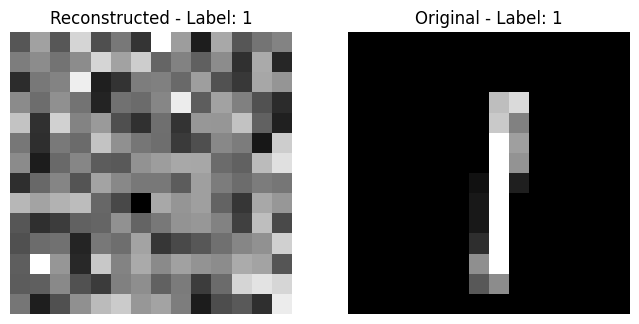

Applying profile...   success
Sweep complete.
mu tensor([[0.0898, 0.5409, 1.3415]], grad_fn=<AddmmBackward0>) and std tensor([[1.1515, 0.5880, 0.7086]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1394203901290894 and KLD 0.1959240734577179 xshape 14


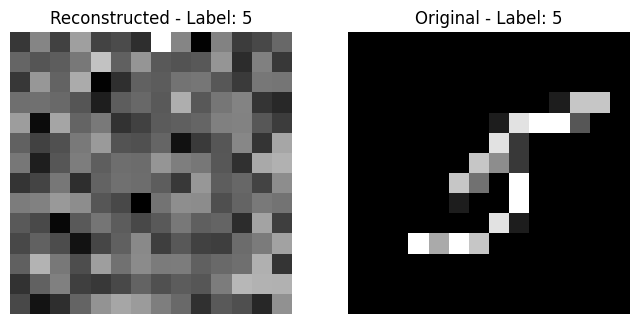

Applying profile...   success
Sweep complete.
mu tensor([[0.2488, 1.4198, 0.4353]], grad_fn=<AddmmBackward0>) and std tensor([[1.1573, 0.8938, 0.8073]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.9570642709732056 and KLD 0.17268922924995422 xshape 14


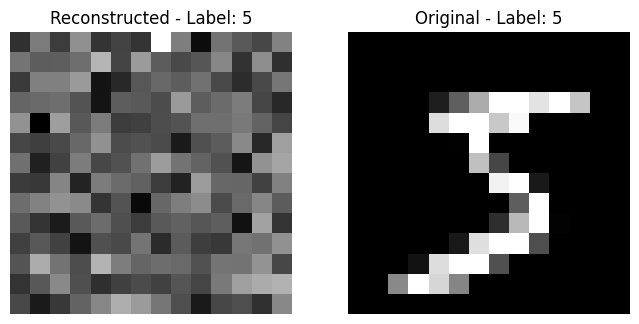

Applying profile...   success
Sweep complete.
mu tensor([[0.5491, 1.3449, 1.0686]], grad_fn=<AddmmBackward0>) and std tensor([[0.7175, 0.8124, 0.8523]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.2272756099700928 and KLD 0.2537462115287781 xshape 14


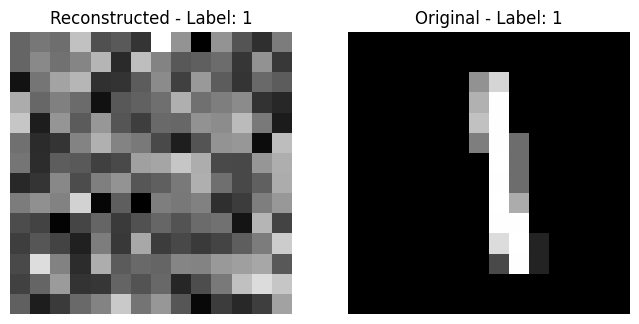

Applying profile...   success
Sweep complete.
mu tensor([[-0.5742, -0.6147, -0.2249]], grad_fn=<AddmmBackward0>) and std tensor([[1.6282, 1.1320, 1.3433]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.6394107341766357 and KLD 0.12013949453830719 xshape 14


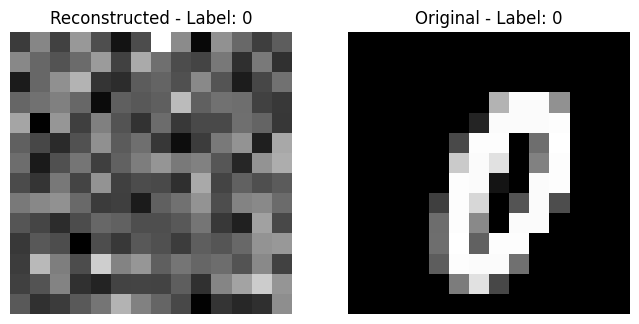

Applying profile...   success
Sweep complete.
mu tensor([[-0.0228,  1.0981,  0.3229]], grad_fn=<AddmmBackward0>) and std tensor([[0.8075, 0.7684, 1.2393]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.195241928100586 and KLD 0.11532251536846161 xshape 14


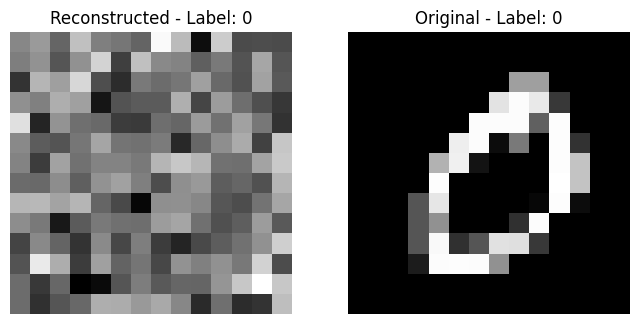

Applying profile...   success
Sweep complete.
mu tensor([[0.5292, 0.8304, 0.1997]], grad_fn=<AddmmBackward0>) and std tensor([[1.0040, 1.0824, 0.9401]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.40867018699646 and KLD 0.07357462495565414 xshape 14


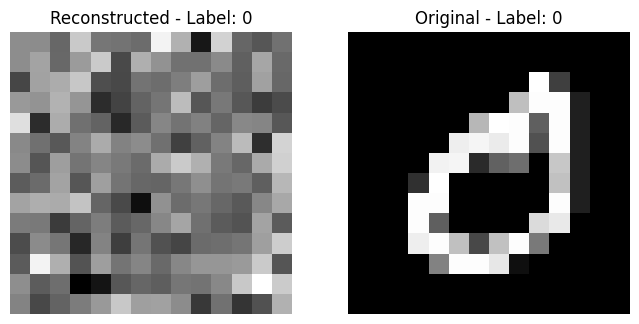

Applying profile...   success
Sweep complete.
mu tensor([[0.0452, 0.6274, 0.4796]], grad_fn=<AddmmBackward0>) and std tensor([[0.9693, 0.8368, 0.7563]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.3162263631820679 and KLD 0.058207686990499496 xshape 14


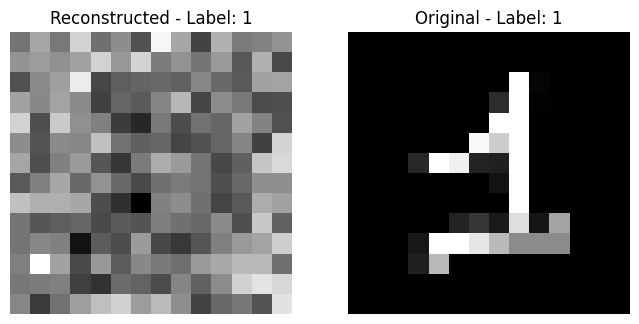

Applying profile...   success
Sweep complete.
mu tensor([[ 0.2485,  0.2536, -0.1052]], grad_fn=<AddmmBackward0>) and std tensor([[1.0551, 0.7791, 1.5930]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1074780225753784 and KLD 0.06111805886030197 xshape 14


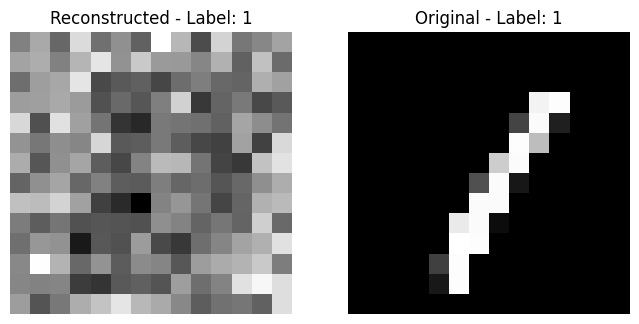

Applying profile...   success
Sweep complete.
mu tensor([[-0.2600,  0.9790,  0.5029]], grad_fn=<AddmmBackward0>) and std tensor([[1.0762, 0.6825, 1.0267]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.0010502338409424 and KLD 0.10867901146411896 xshape 14


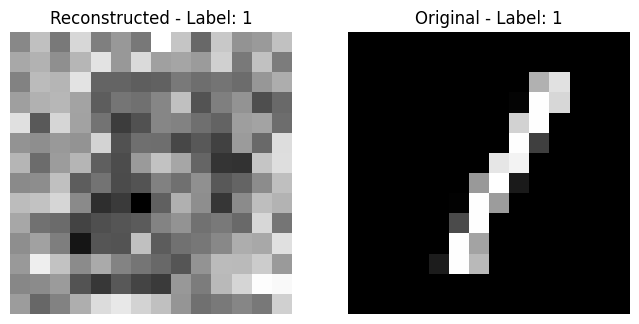

Applying profile...   success
Sweep complete.
mu tensor([[0.3854, 0.8775, 0.9565]], grad_fn=<AddmmBackward0>) and std tensor([[1.4114, 0.4939, 1.4754]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.886979818344116 and KLD 0.2278604805469513 xshape 14


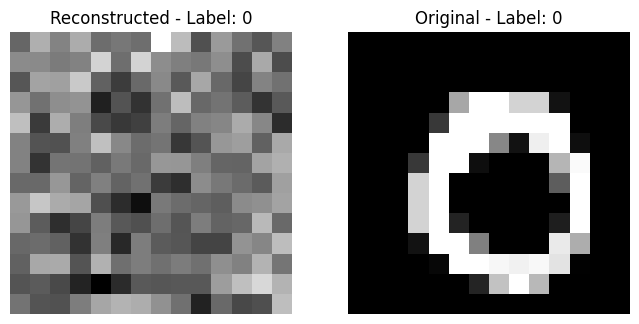

Applying profile...   success
Sweep complete.
mu tensor([[0.2951, 1.1533, 0.5992]], grad_fn=<AddmmBackward0>) and std tensor([[0.8578, 0.5545, 1.1959]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8421030044555664 and KLD 0.16985417902469635 xshape 14


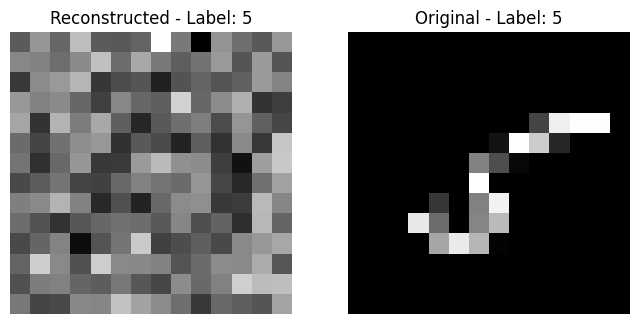

Applying profile...   success
Sweep complete.
mu tensor([[0.1463, 1.6101, 0.6808]], grad_fn=<AddmmBackward0>) and std tensor([[0.6341, 0.5535, 1.1198]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.360166072845459 and KLD 0.27910929918289185 xshape 14


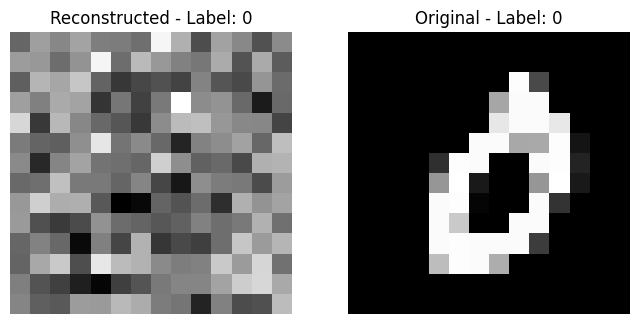

Applying profile...   success
Sweep complete.
mu tensor([[0.1848, 1.1953, 0.9180]], grad_fn=<AddmmBackward0>) and std tensor([[0.9325, 0.6978, 0.9251]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.3730745315551758 and KLD 0.1809261292219162 xshape 14


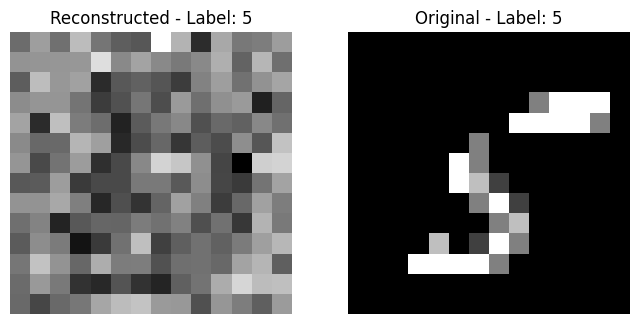

Applying profile...   success
Sweep complete.
mu tensor([[ 0.1898, -0.4215, -0.3937]], grad_fn=<AddmmBackward0>) and std tensor([[1.0951, 0.8453, 1.7330]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1372113227844238 and KLD 0.09575201570987701 xshape 14


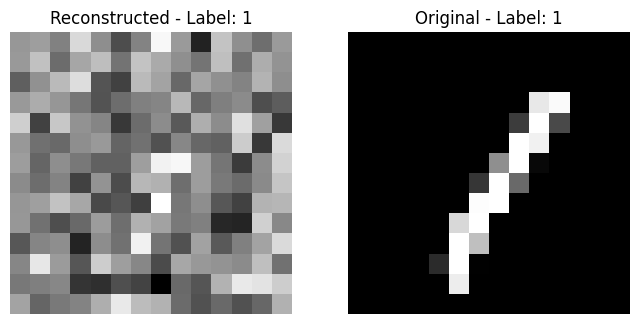

Applying profile...   success
Sweep complete.
mu tensor([[0.7052, 0.8236, 0.4247]], grad_fn=<AddmmBackward0>) and std tensor([[0.9729, 0.7503, 1.3105]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.8523261547088623 and KLD 0.11939691752195358 xshape 14


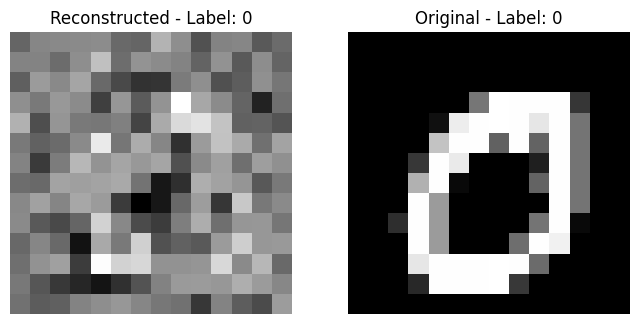

Applying profile...   success
Sweep complete.
mu tensor([[0.8168, 0.9825, 0.5927]], grad_fn=<AddmmBackward0>) and std tensor([[0.8845, 0.6489, 1.5795]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6828430891036987 and KLD 0.20557062327861786 xshape 14


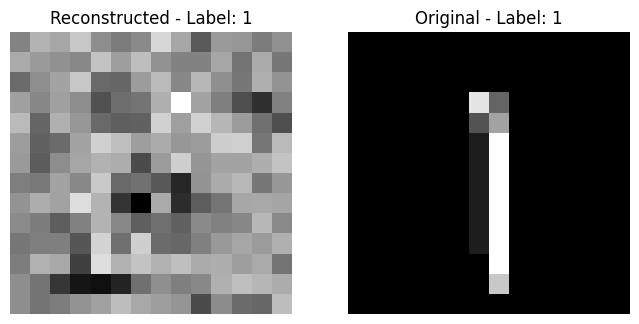

Applying profile...   success
Sweep complete.
mu tensor([[0.6715, 0.9118, 0.4880]], grad_fn=<AddmmBackward0>) and std tensor([[0.6888, 0.6373, 1.6384]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5534347891807556 and KLD 0.19604383409023285 xshape 14


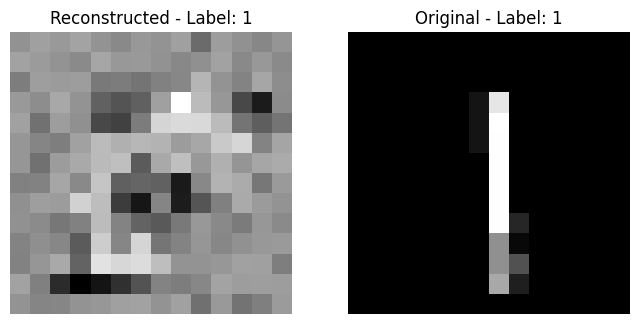

Epoch 1/15, Loss: 1.7760
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[0.6447, 0.9009, 0.4859]], grad_fn=<AddmmBackward0>) and std tensor([[0.6864, 0.6455, 1.6173]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5765596628189087 and KLD 0.18809624016284943 xshape 14


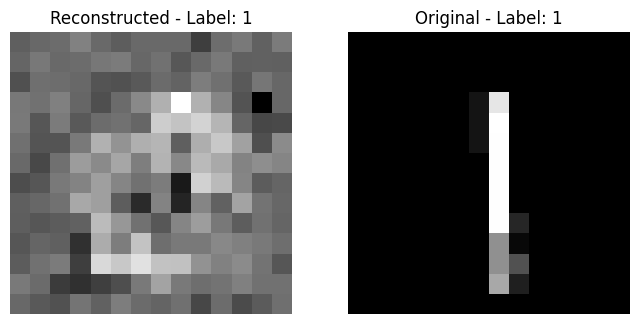

Applying profile...   success
Sweep complete.
mu tensor([[-0.2555,  0.7610,  0.3843]], grad_fn=<AddmmBackward0>) and std tensor([[0.7327, 0.6139, 1.3636]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.7216167449951172 and KLD 0.11018563061952591 xshape 14


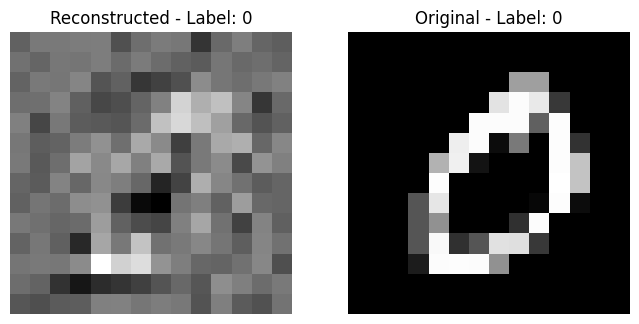

Applying profile...   success
Sweep complete.
mu tensor([[ 0.1321, -0.3794, -0.2471]], grad_fn=<AddmmBackward0>) and std tensor([[1.1142, 0.8348, 1.7377]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9818348288536072 and KLD 0.08714992552995682 xshape 14


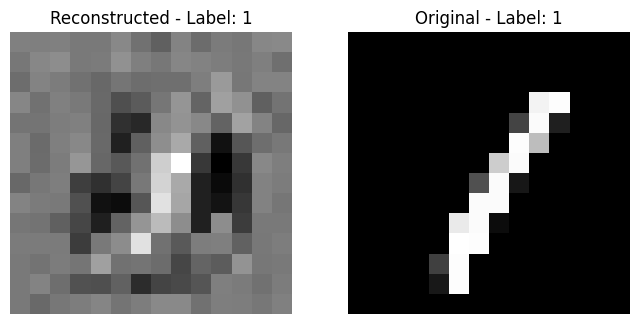

Applying profile...   success
Sweep complete.
mu tensor([[0.2318, 1.5653, 0.6095]], grad_fn=<AddmmBackward0>) and std tensor([[0.7672, 0.5185, 1.2365]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6853785514831543 and KLD 0.2629261612892151 xshape 14


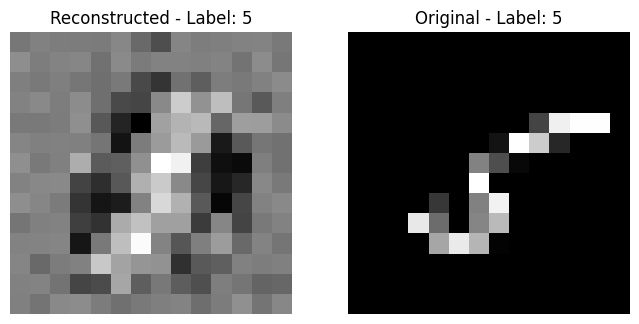

Applying profile...   success
Sweep complete.
mu tensor([[0.7853, 1.0178, 0.5802]], grad_fn=<AddmmBackward0>) and std tensor([[0.8619, 0.6398, 1.6167]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6118521690368652 and KLD 0.21319516003131866 xshape 14


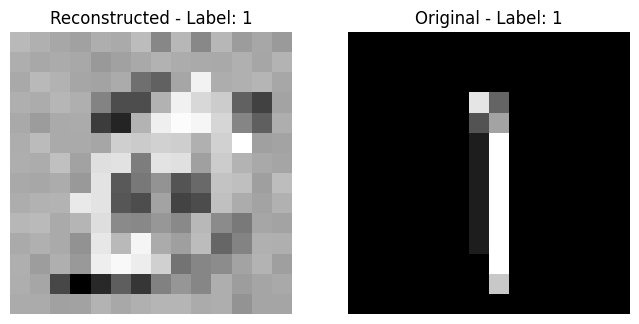

Applying profile...   success
Sweep complete.
mu tensor([[0.5278, 1.3678, 1.2130]], grad_fn=<AddmmBackward0>) and std tensor([[0.7849, 0.8358, 0.8711]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8585523366928101 and KLD 0.27237430214881897 xshape 14


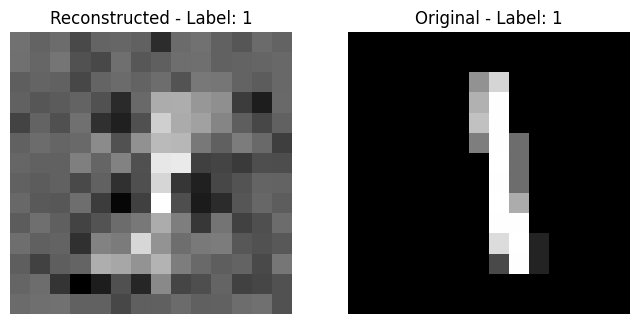

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0884, -0.3414, -0.3847]], grad_fn=<AddmmBackward0>) and std tensor([[1.0766, 0.8463, 1.7732]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8913787007331848 and KLD 0.09518659114837646 xshape 14


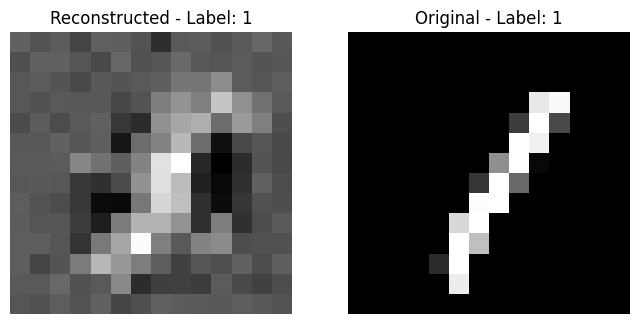

Applying profile...   success
Sweep complete.
mu tensor([[0.5433, 1.2119, 0.4593]], grad_fn=<AddmmBackward0>) and std tensor([[0.8430, 0.8978, 1.0990]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.935831904411316 and KLD 0.1476961076259613 xshape 14


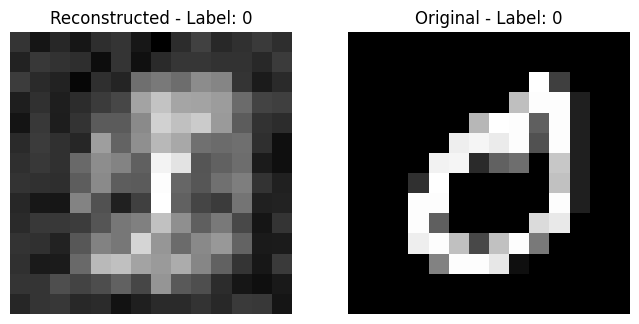

Applying profile...   success
Sweep complete.
mu tensor([[0.1660, 1.4756, 0.0208]], grad_fn=<AddmmBackward0>) and std tensor([[0.9253, 0.5824, 0.8134]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7924275994300842 and KLD 0.19371850788593292 xshape 14


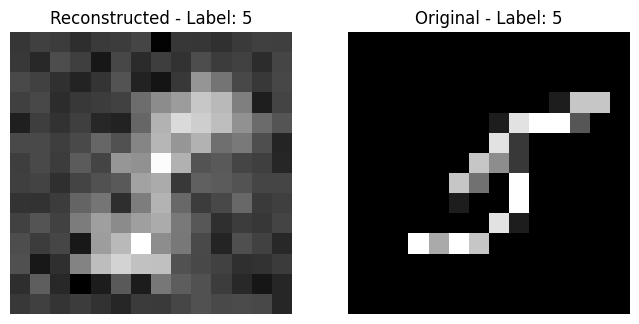

Applying profile...   success
Sweep complete.
mu tensor([[0.2891, 1.0015, 0.9560]], grad_fn=<AddmmBackward0>) and std tensor([[1.2606, 0.4802, 1.4954]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.2853586673736572 and KLD 0.23253671824932098 xshape 14


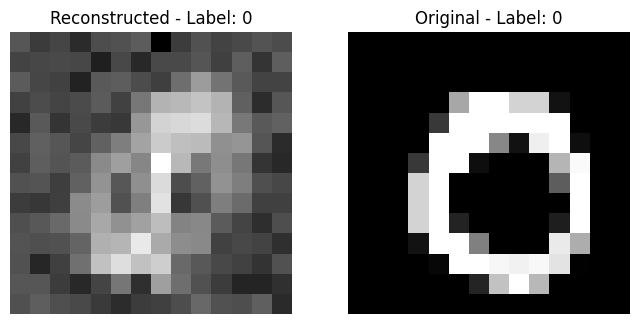

Applying profile...   success
Sweep complete.
mu tensor([[0.4098, 1.2133, 0.9636]], grad_fn=<AddmmBackward0>) and std tensor([[0.9568, 0.7239, 0.8644]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1859086751937866 and KLD 0.19865034520626068 xshape 14


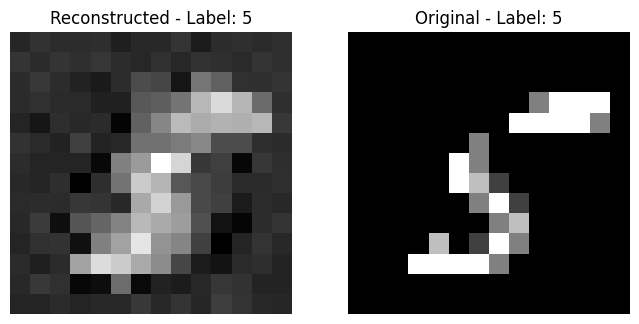

Applying profile...   success
Sweep complete.
mu tensor([[0.1556, 1.6406, 0.7360]], grad_fn=<AddmmBackward0>) and std tensor([[0.6101, 0.5581, 1.2085]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.9672592878341675 and KLD 0.29840177297592163 xshape 14


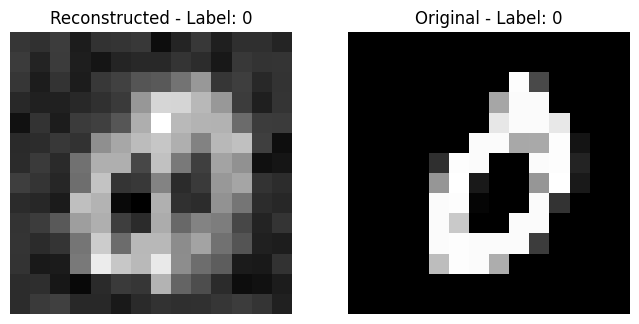

Applying profile...   success
Sweep complete.
mu tensor([[-0.0983,  0.7055, -0.2616]], grad_fn=<AddmmBackward0>) and std tensor([[0.4989, 0.8815, 1.0610]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6216102242469788 and KLD 0.08943609148263931 xshape 14


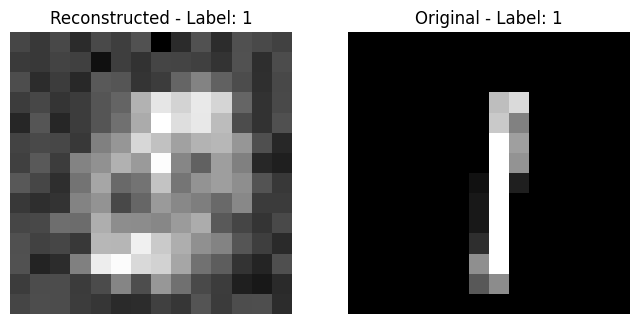

Applying profile...   success
Sweep complete.
mu tensor([[0.6517, 1.2125, 0.4130]], grad_fn=<AddmmBackward0>) and std tensor([[0.8757, 1.0305, 1.0128]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.535232663154602 and KLD 0.1499878466129303 xshape 14


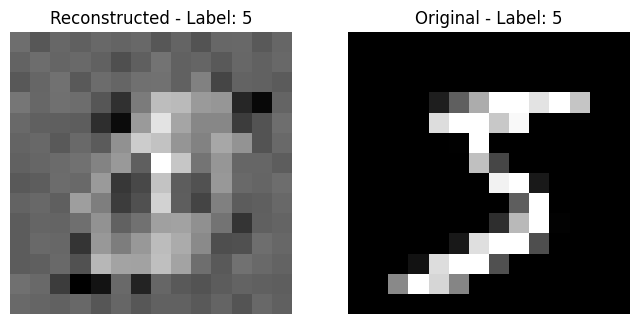

Applying profile...   success
Sweep complete.
mu tensor([[0.5195, 0.9058, 0.4304]], grad_fn=<AddmmBackward0>) and std tensor([[0.8834, 0.5873, 1.3901]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.2700181007385254 and KLD 0.14193172752857208 xshape 14


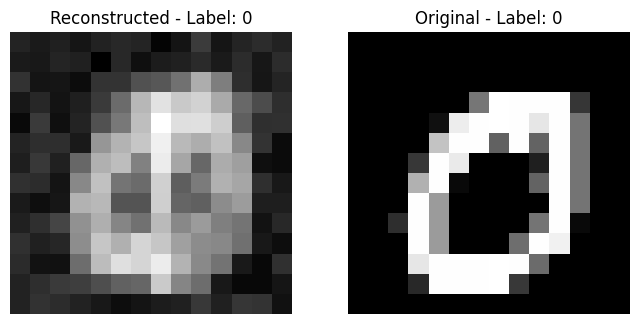

Applying profile...   success
Sweep complete.
mu tensor([[-0.0981,  0.6783,  0.2704]], grad_fn=<AddmmBackward0>) and std tensor([[1.0925, 0.7590, 1.1770]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.759289562702179 and KLD 0.05332440137863159 xshape 14


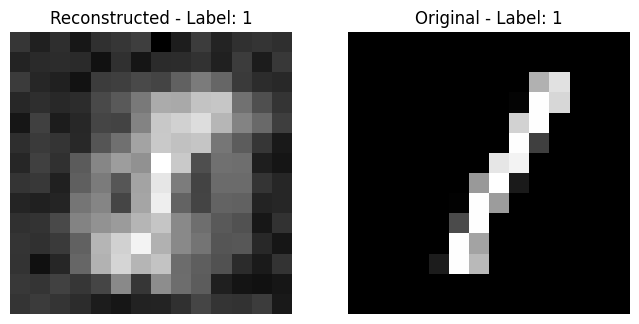

Applying profile...   success
Sweep complete.
mu tensor([[-0.0999,  0.6168,  0.7796]], grad_fn=<AddmmBackward0>) and std tensor([[1.1962, 0.8983, 0.7437]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.0308057069778442 and KLD 0.08839775621891022 xshape 14


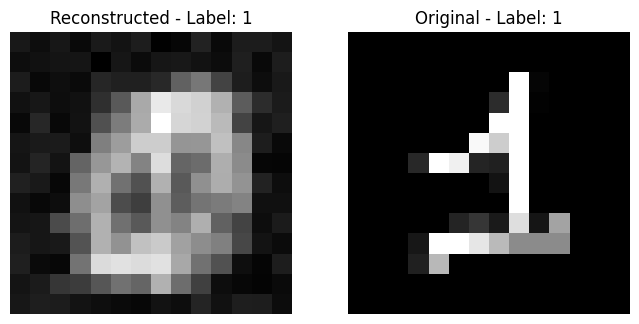

Applying profile...   success
Sweep complete.
mu tensor([[-0.2612, -0.1708, -0.4070]], grad_fn=<AddmmBackward0>) and std tensor([[1.5586, 0.9811, 1.3204]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.1759393215179443 and KLD 0.07092360407114029 xshape 14


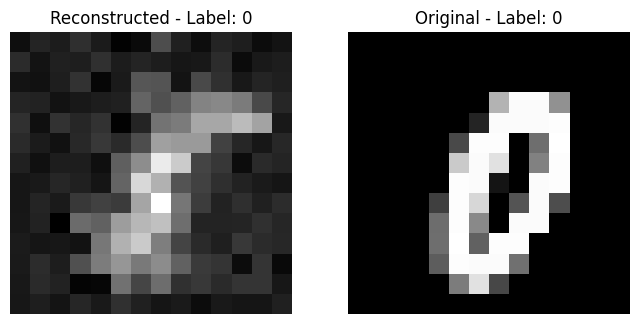

Epoch 2/15, Loss: 1.4644
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[0.5948, 1.0498, 0.4679]], grad_fn=<AddmmBackward0>) and std tensor([[0.8795, 0.5390, 1.3060]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.286738872528076 and KLD 0.1716761738061905 xshape 14


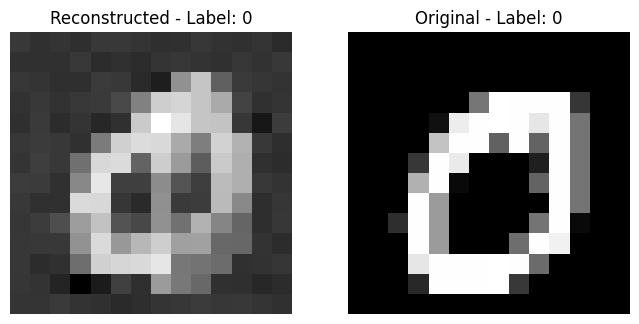

Applying profile...   success
Sweep complete.
mu tensor([[0.2534, 0.6461, 0.8703]], grad_fn=<AddmmBackward0>) and std tensor([[1.0090, 0.9035, 0.9053]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.084038496017456 and KLD 0.09120935946702957 xshape 14


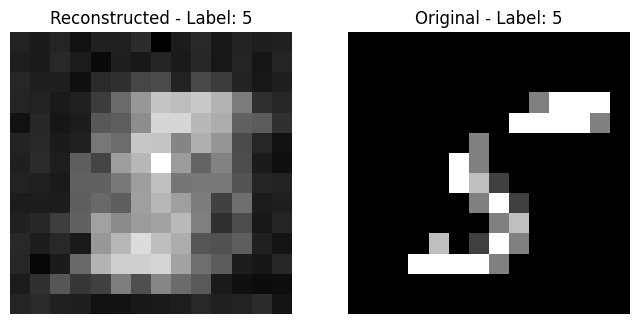

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0849, -0.4858, -0.4820]], grad_fn=<AddmmBackward0>) and std tensor([[1.0898, 0.8787, 1.7791]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7493019104003906 and KLD 0.10963111370801926 xshape 14


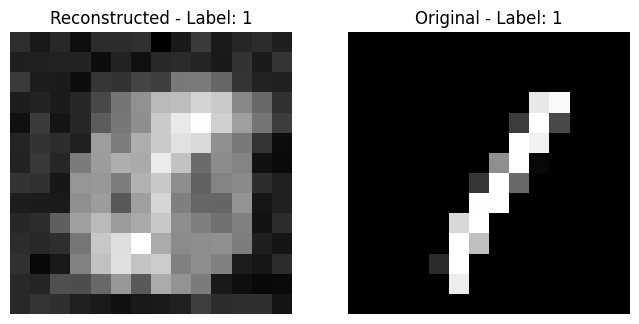

Applying profile...   success
Sweep complete.
mu tensor([[0.6589, 0.7767, 0.6274]], grad_fn=<AddmmBackward0>) and std tensor([[0.8845, 0.6601, 1.5658]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5118192434310913 and KLD 0.16286812722682953 xshape 14


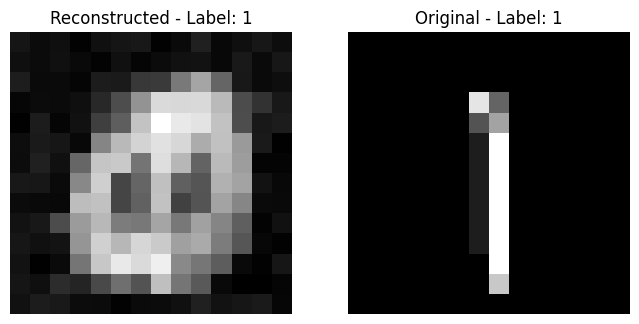

Applying profile...   success
Sweep complete.
mu tensor([[0.0600, 0.9476, 1.1632]], grad_fn=<AddmmBackward0>) and std tensor([[1.5682, 0.5409, 1.2070]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.5111467838287354 and KLD 0.24400798976421356 xshape 14


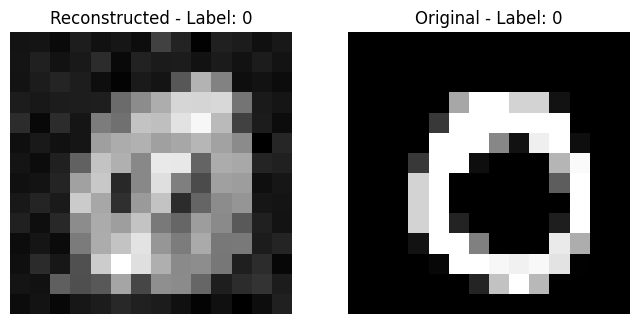

Applying profile...   success
Sweep complete.
mu tensor([[0.0996, 1.5324, 0.1263]], grad_fn=<AddmmBackward0>) and std tensor([[0.8468, 0.6376, 0.9836]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5689497590065002 and KLD 0.1950618177652359 xshape 14


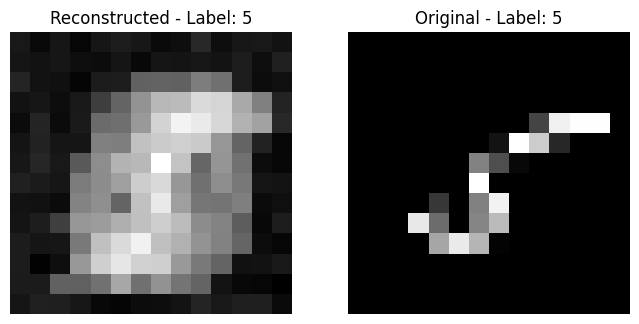

Applying profile...   success
Sweep complete.
mu tensor([[0.2811, 1.3327, 1.1705]], grad_fn=<AddmmBackward0>) and std tensor([[0.6806, 0.7069, 1.1837]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.7253954410552979 and KLD 0.2653934359550476 xshape 14


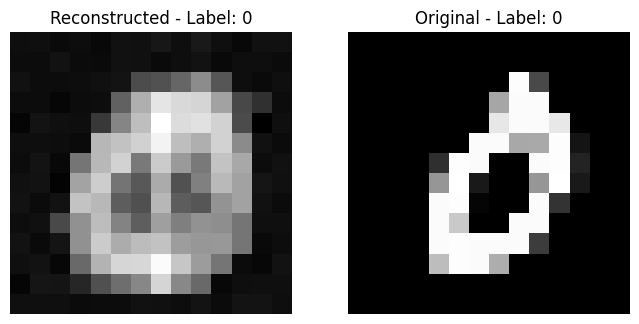

Applying profile...   success
Sweep complete.
mu tensor([[-0.4043, -0.3383, -0.2766]], grad_fn=<AddmmBackward0>) and std tensor([[1.6500, 1.0316, 1.3008]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 2.1492457389831543 and KLD 0.08880949020385742 xshape 14


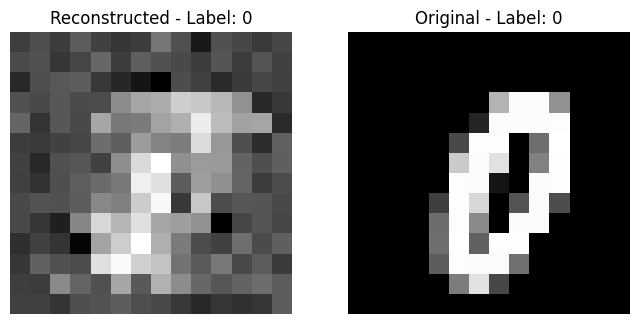

Applying profile...   success
Sweep complete.
mu tensor([[-0.0708,  0.5282,  0.5924]], grad_fn=<AddmmBackward0>) and std tensor([[1.1900, 0.9061, 0.7708]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.998058021068573 and KLD 0.059728387743234634 xshape 14


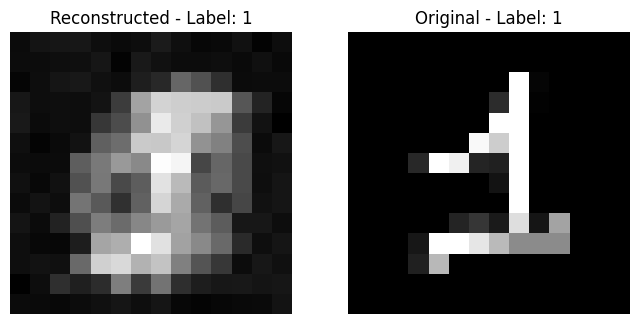

Applying profile...   success
Sweep complete.
mu tensor([[0.5127, 1.1470, 1.2914]], grad_fn=<AddmmBackward0>) and std tensor([[0.9384, 0.9153, 0.8689]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7593158483505249 and KLD 0.2360645979642868 xshape 14


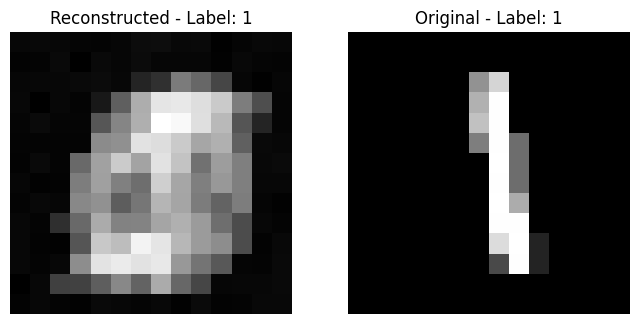

Applying profile...   success
Sweep complete.
mu tensor([[-0.7920, -0.1137, -0.6908]], grad_fn=<AddmmBackward0>) and std tensor([[1.1450, 1.0428, 1.1039]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6525530219078064 and KLD 0.08443045616149902 xshape 14


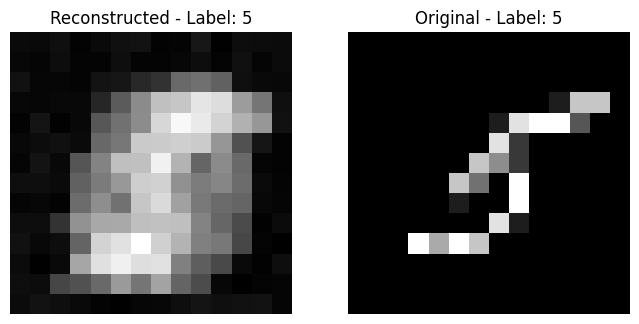

Applying profile...   success
Sweep complete.
mu tensor([[ 0.1862,  0.4629, -0.0535]], grad_fn=<AddmmBackward0>) and std tensor([[0.4647, 0.8694, 1.1303]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5057807564735413 and KLD 0.076347216963768 xshape 14


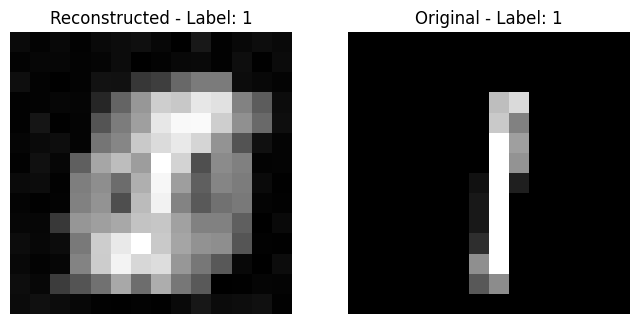

Applying profile...   success
Sweep complete.
mu tensor([[0.3173, 0.9016, 0.7430]], grad_fn=<AddmmBackward0>) and std tensor([[1.1555, 0.7192, 0.8683]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.3564014434814453 and KLD 0.1231849193572998 xshape 14


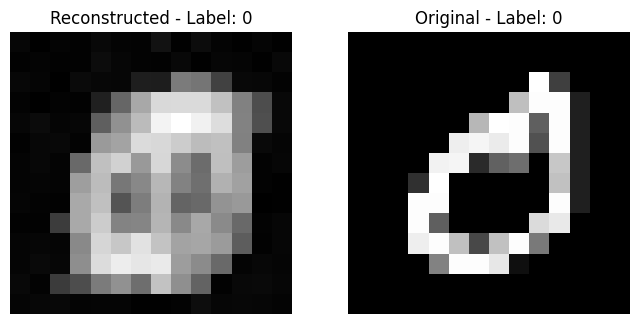

Applying profile...   success
Sweep complete.
mu tensor([[-0.6185,  0.3831,  0.1720]], grad_fn=<AddmmBackward0>) and std tensor([[0.7586, 0.5939, 1.1939]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.2608193159103394 and KLD 0.08233696222305298 xshape 14


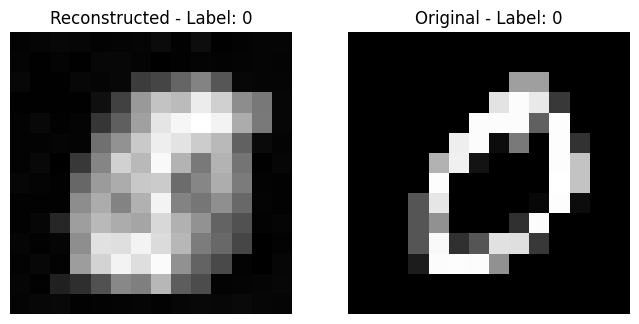

Applying profile...   success
Sweep complete.
mu tensor([[-0.5776, -0.0954,  1.2469]], grad_fn=<AddmmBackward0>) and std tensor([[1.3870, 0.9878, 0.8251]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.2560685873031616 and KLD 0.15947416424751282 xshape 14


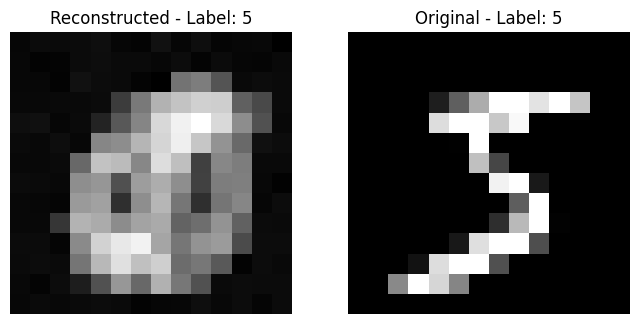

Applying profile...   success
Sweep complete.
mu tensor([[-0.0713,  0.4698,  0.2018]], grad_fn=<AddmmBackward0>) and std tensor([[1.2157, 0.7950, 1.1393]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6746491193771362 and KLD 0.03441863879561424 xshape 14


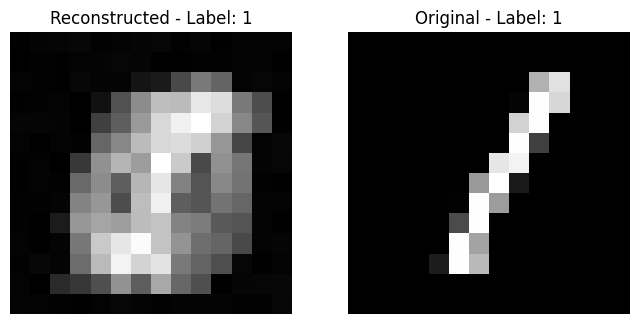

Applying profile...   success
Sweep complete.
mu tensor([[0.5468, 0.8984, 0.5624]], grad_fn=<AddmmBackward0>) and std tensor([[0.7743, 0.6578, 1.2653]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4324600100517273 and KLD 0.13816270232200623 xshape 14


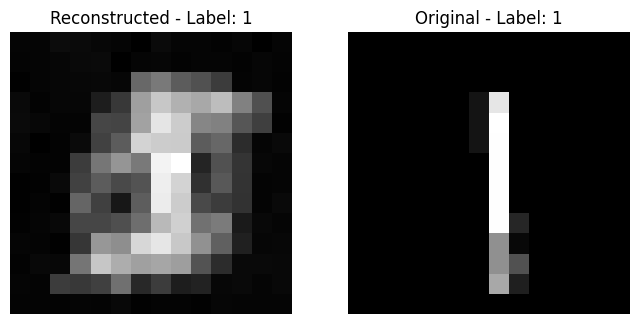

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0734, -0.6039, -0.3297]], grad_fn=<AddmmBackward0>) and std tensor([[1.1349, 0.8746, 1.6890]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6595740914344788 and KLD 0.09649991244077682 xshape 14


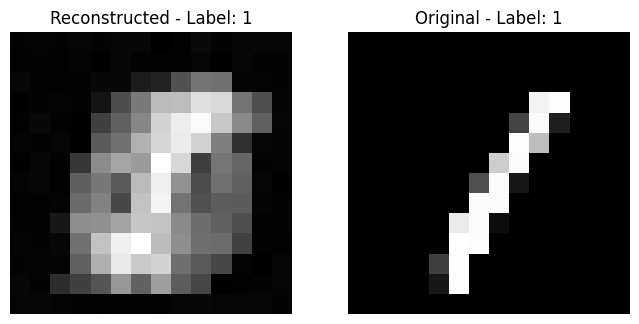

Epoch 3/15, Loss: 1.2803
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[-0.0842,  0.4451,  0.2028]], grad_fn=<AddmmBackward0>) and std tensor([[1.2362, 0.7894, 1.1466]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6331652402877808 and KLD 0.03483036160469055 xshape 14


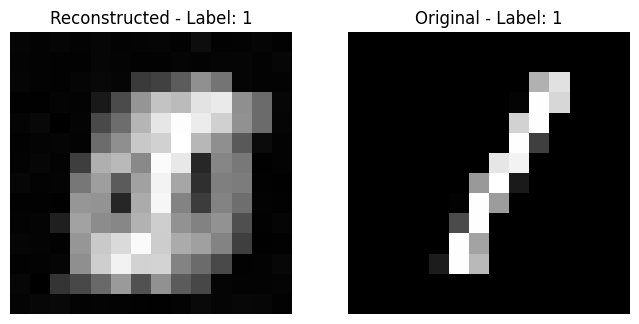

Applying profile...   success
Sweep complete.
mu tensor([[0.0925, 0.5778, 1.1555]], grad_fn=<AddmmBackward0>) and std tensor([[1.6193, 0.5785, 1.1009]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.8464995622634888 and KLD 0.19891545176506042 xshape 14


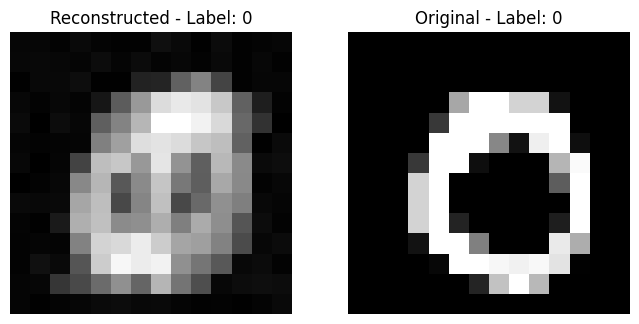

Applying profile...   success
Sweep complete.
mu tensor([[-0.6401, -0.2225,  1.3199]], grad_fn=<AddmmBackward0>) and std tensor([[1.4414, 1.0062, 0.8310]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.2305446863174438 and KLD 0.18632827699184418 xshape 14


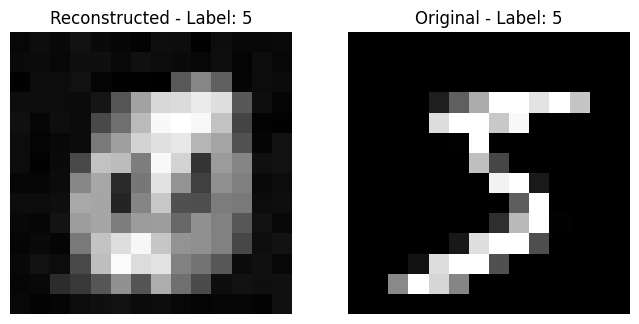

Applying profile...   success
Sweep complete.
mu tensor([[0.2790, 0.7107, 1.0048]], grad_fn=<AddmmBackward0>) and std tensor([[1.1279, 0.6899, 0.8197]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.286009430885315 and KLD 0.13657037913799286 xshape 14


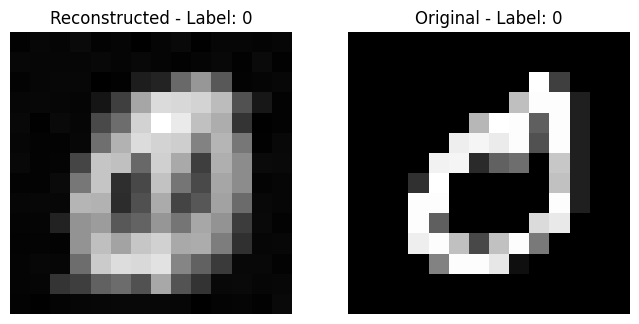

Applying profile...   success
Sweep complete.
mu tensor([[0.5938, 0.9159, 0.5886]], grad_fn=<AddmmBackward0>) and std tensor([[0.8012, 0.6652, 1.2077]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4350869953632355 and KLD 0.1401464194059372 xshape 14


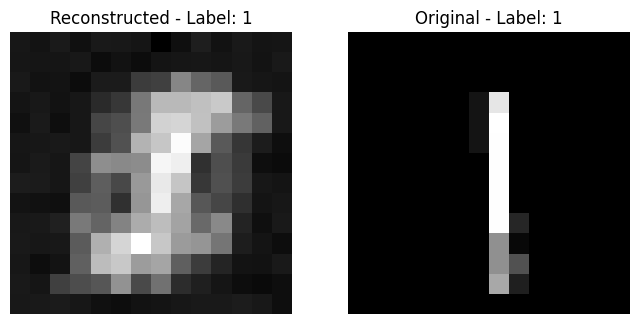

Applying profile...   success
Sweep complete.
mu tensor([[0.5439, 0.6205, 0.4700]], grad_fn=<AddmmBackward0>) and std tensor([[1.4615, 1.0881, 0.9437]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8417350053787231 and KLD 0.09287406504154205 xshape 14


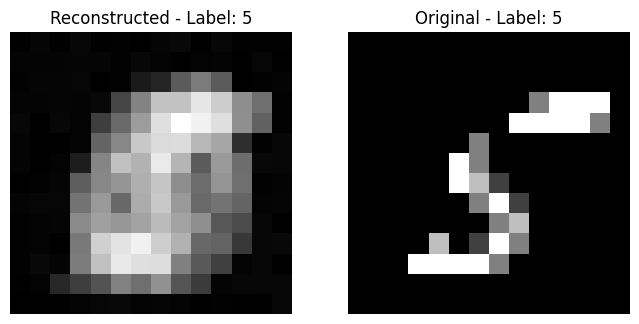

Applying profile...   success
Sweep complete.
mu tensor([[-0.1682, -0.4872,  1.5653]], grad_fn=<AddmmBackward0>) and std tensor([[1.1106, 1.1582, 1.0906]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.5081948041915894 and KLD 0.20022368431091309 xshape 14


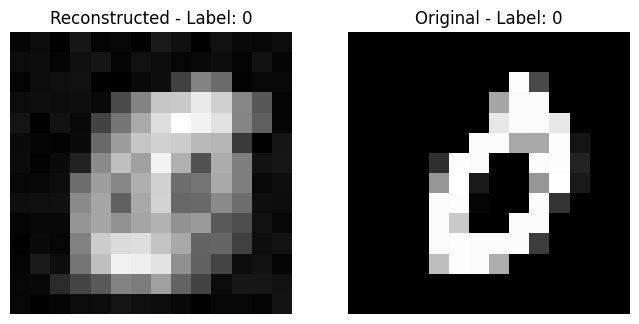

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0491,  1.2756, -0.4524]], grad_fn=<AddmmBackward0>) and std tensor([[0.8432, 0.7493, 0.7927]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5615741610527039 and KLD 0.15129181742668152 xshape 14


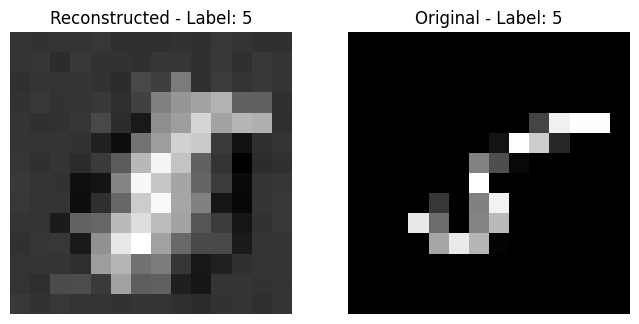

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0726, -0.6244, -0.2508]], grad_fn=<AddmmBackward0>) and std tensor([[1.0949, 0.8556, 1.6565]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6362498998641968 and KLD 0.08957474678754807 xshape 14


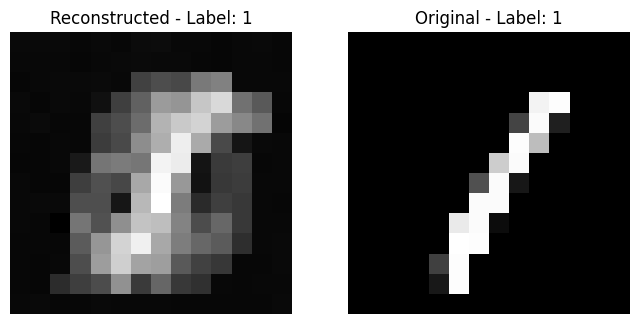

Applying profile...   success
Sweep complete.
mu tensor([[0.3296, 1.1174, 0.2139]], grad_fn=<AddmmBackward0>) and std tensor([[1.2817, 0.7870, 0.9482]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.7377007007598877 and KLD 0.11808557063341141 xshape 14


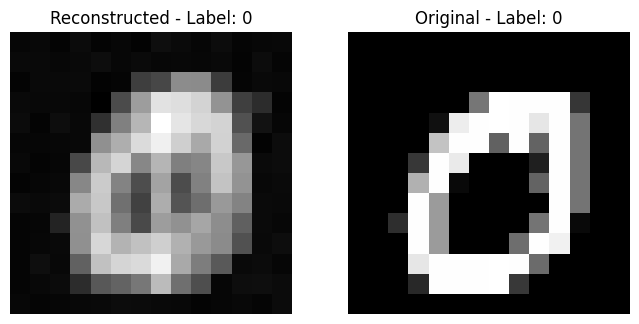

Applying profile...   success
Sweep complete.
mu tensor([[0.1067, 0.3424, 0.5147]], grad_fn=<AddmmBackward0>) and std tensor([[0.9073, 0.9537, 0.7370]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8596047163009644 and KLD 0.040656693279743195 xshape 14


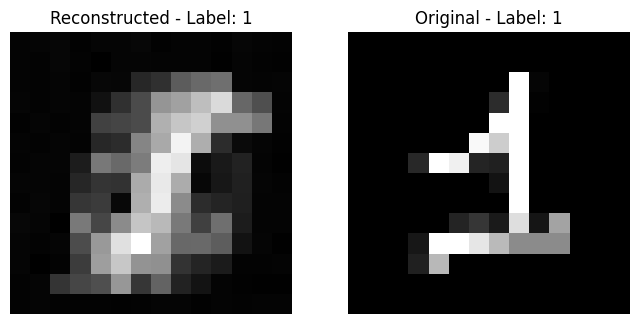

Applying profile...   success
Sweep complete.
mu tensor([[0.5166, 1.0992, 1.3633]], grad_fn=<AddmmBackward0>) and std tensor([[1.0059, 0.9086, 0.8228]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6670078635215759 and KLD 0.24415223300457 xshape 14


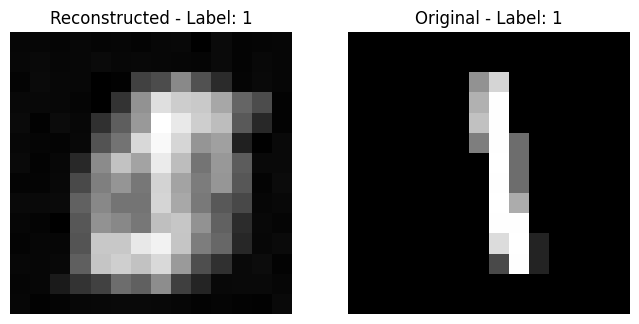

Applying profile...   success
Sweep complete.
mu tensor([[-0.0656, -0.2677,  0.9282]], grad_fn=<AddmmBackward0>) and std tensor([[1.2330, 1.3956, 1.0478]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.4387876987457275 and KLD 0.09460241347551346 xshape 14


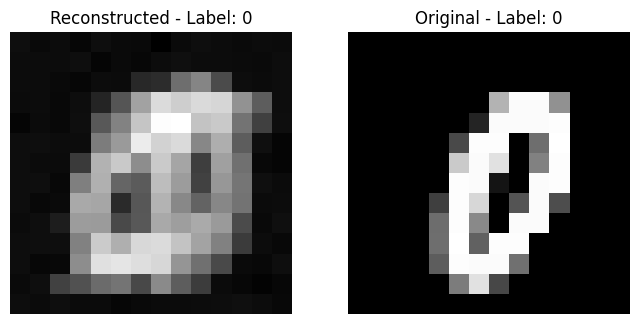

Applying profile...   success
Sweep complete.
mu tensor([[0.7041, 1.1778, 0.1688]], grad_fn=<AddmmBackward0>) and std tensor([[0.5752, 0.8681, 1.0097]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5084958672523499 and KLD 0.1703742891550064 xshape 14


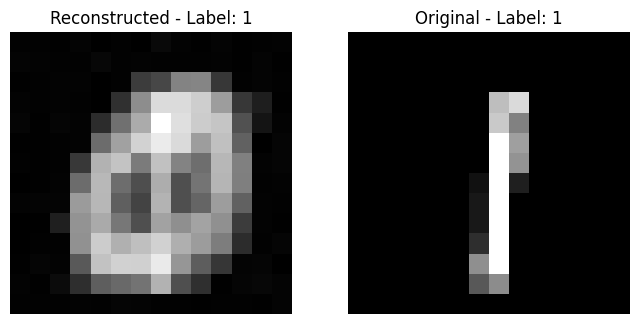

Applying profile...   success
Sweep complete.
mu tensor([[0.8850, 1.1692, 0.7422]], grad_fn=<AddmmBackward0>) and std tensor([[0.9050, 0.6128, 1.1613]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.48605966567993164 and KLD 0.22315724194049835 xshape 14


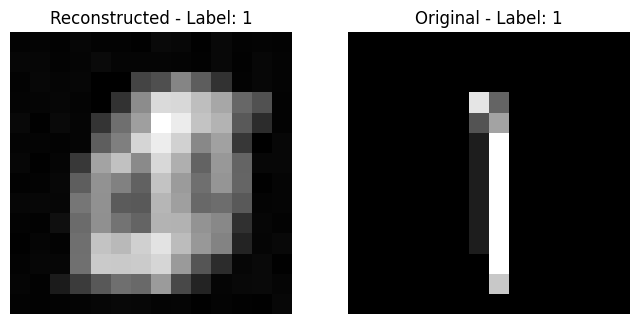

Applying profile...   success
Sweep complete.
mu tensor([[ 0.1718, -0.4288,  0.0404]], grad_fn=<AddmmBackward0>) and std tensor([[1.0416, 0.8082, 1.6006]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.775734007358551 and KLD 0.06561821699142456 xshape 14


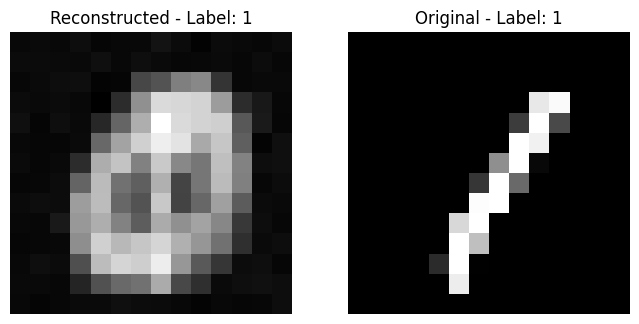

Applying profile...   success
Sweep complete.
mu tensor([[-0.4231,  0.4325,  1.1402]], grad_fn=<AddmmBackward0>) and std tensor([[1.4346, 0.5366, 1.2512]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.0136206150054932 and KLD 0.18947894871234894 xshape 14


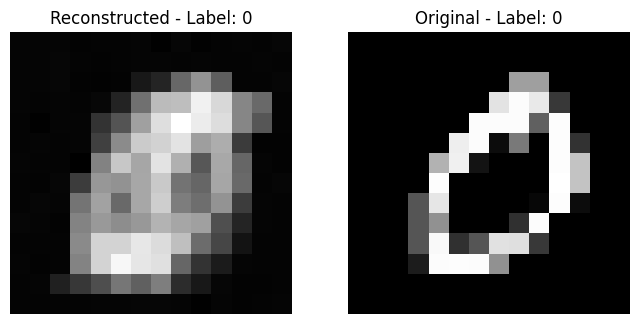

Applying profile...   success
Sweep complete.
mu tensor([[ 0.2535, -0.5436, -0.2375]], grad_fn=<AddmmBackward0>) and std tensor([[0.8065, 0.8297, 1.4865]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.697905421257019 and KLD 0.06966279447078705 xshape 14


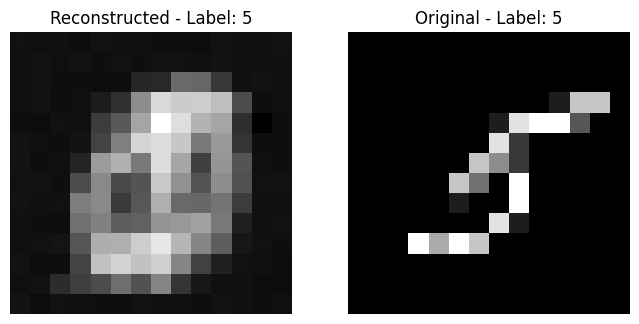

Epoch 4/15, Loss: 1.1167
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[0.8103, 1.1256, 0.7605]], grad_fn=<AddmmBackward0>) and std tensor([[0.8439, 0.6046, 1.1656]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4520576298236847 and KLD 0.21268044412136078 xshape 14


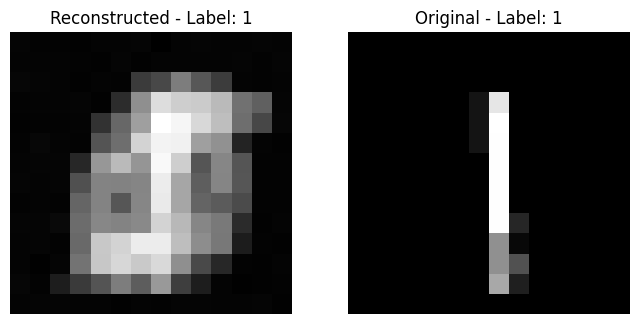

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0763, -0.0628,  0.9613]], grad_fn=<AddmmBackward0>) and std tensor([[1.4415, 0.6402, 1.0607]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.6655158996582031 and KLD 0.11353163421154022 xshape 14


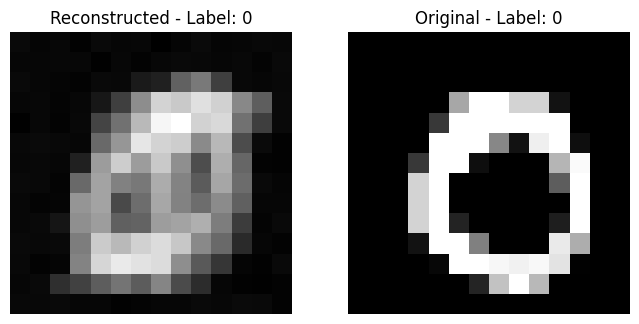

Applying profile...   success
Sweep complete.
mu tensor([[0.4568, 1.1222, 1.0842]], grad_fn=<AddmmBackward0>) and std tensor([[1.1934, 0.7606, 0.7150]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.5779672861099243 and KLD 0.21584448218345642 xshape 14


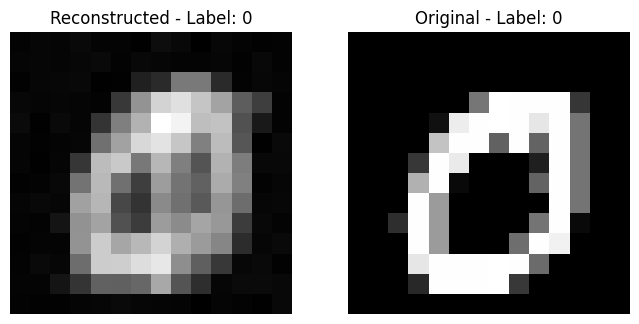

Applying profile...   success
Sweep complete.
mu tensor([[-0.1238, -0.2067,  0.8145]], grad_fn=<AddmmBackward0>) and std tensor([[1.3572, 1.2481, 1.0951]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.2853535413742065 and KLD 0.07747726887464523 xshape 14


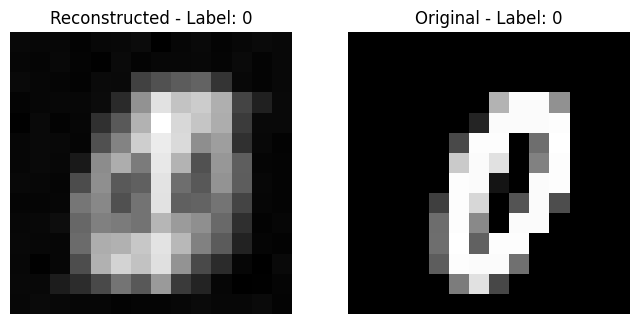

Applying profile...   success
Sweep complete.
mu tensor([[1.0817, 1.5581, 0.8443]], grad_fn=<AddmmBackward0>) and std tensor([[0.8496, 0.7685, 0.9541]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4750630557537079 and KLD 0.3199734687805176 xshape 14


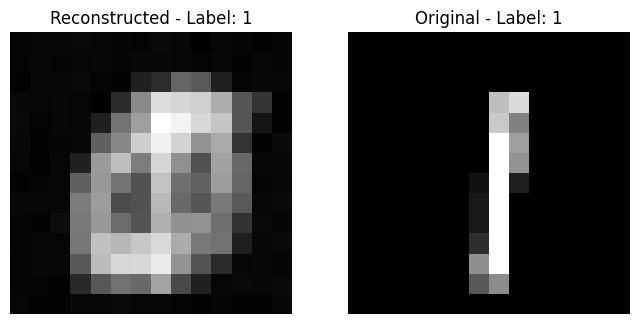

Applying profile...   success
Sweep complete.
mu tensor([[ 0.4884,  0.1597, -0.0968]], grad_fn=<AddmmBackward0>) and std tensor([[0.6761, 0.7121, 1.4408]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6446887254714966 and KLD 0.0746370330452919 xshape 14


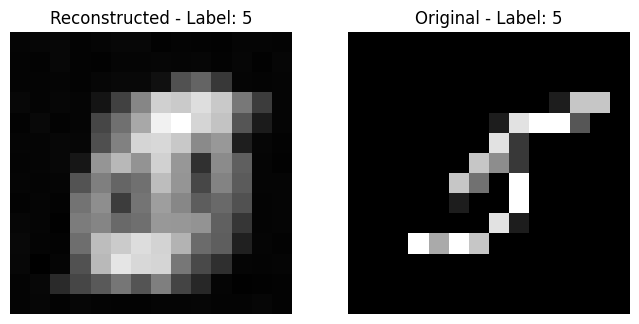

Applying profile...   success
Sweep complete.
mu tensor([[-0.6516,  0.1245,  0.0544]], grad_fn=<AddmmBackward0>) and std tensor([[0.7677, 0.5881, 1.1005]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9898990988731384 and KLD 0.0705951377749443 xshape 14


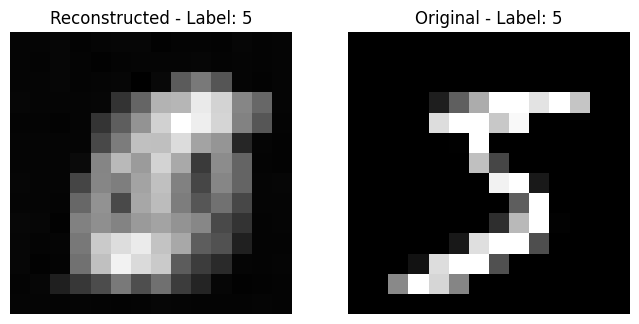

Applying profile...   success
Sweep complete.
mu tensor([[ 0.1563,  0.8129, -0.1120]], grad_fn=<AddmmBackward0>) and std tensor([[0.7535, 0.7058, 0.7852]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4568939208984375 and KLD 0.08049547672271729 xshape 14


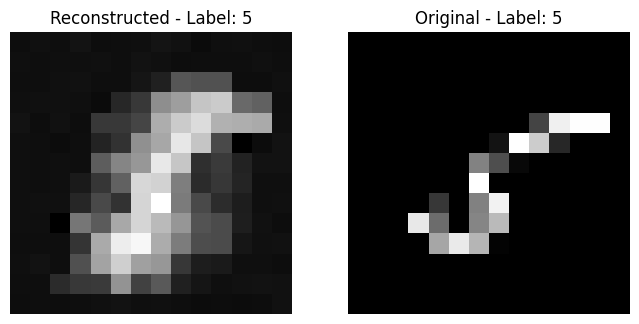

Applying profile...   success
Sweep complete.
mu tensor([[0.3640, 1.0263, 0.8922]], grad_fn=<AddmmBackward0>) and std tensor([[0.8389, 0.7720, 0.6735]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8665235638618469 and KLD 0.17104026675224304 xshape 14


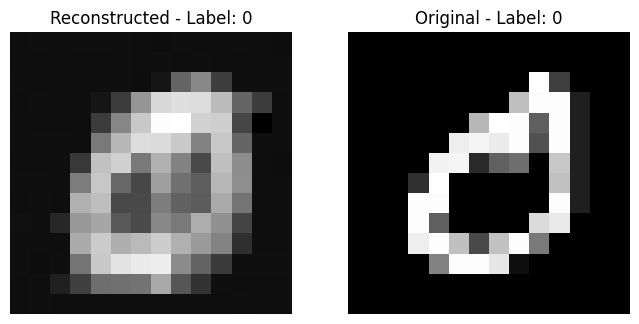

Applying profile...   success
Sweep complete.
mu tensor([[0.9859, 1.4654, 0.8909]], grad_fn=<AddmmBackward0>) and std tensor([[0.9155, 0.6163, 0.9345]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4829671084880829 and KLD 0.30603593587875366 xshape 14


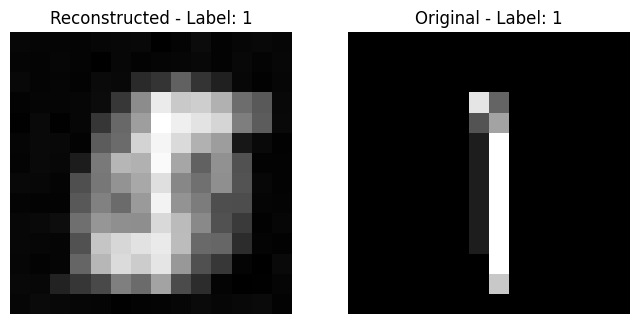

Applying profile...   success
Sweep complete.
mu tensor([[0.5538, 1.0320, 1.4092]], grad_fn=<AddmmBackward0>) and std tensor([[0.9830, 0.8936, 0.7754]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6854143738746643 and KLD 0.24940991401672363 xshape 14


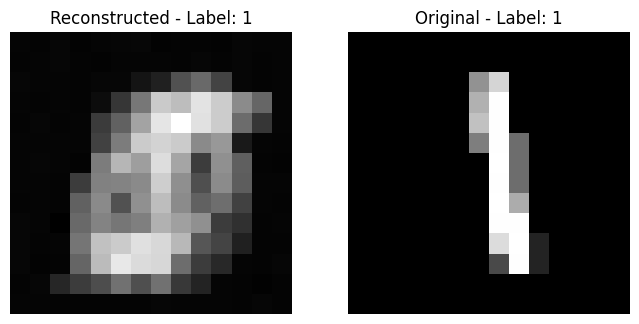

Applying profile...   success
Sweep complete.
mu tensor([[0.6479, 0.4642, 1.1838]], grad_fn=<AddmmBackward0>) and std tensor([[0.9155, 1.0178, 0.8700]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.268061637878418 and KLD 0.14910034835338593 xshape 14


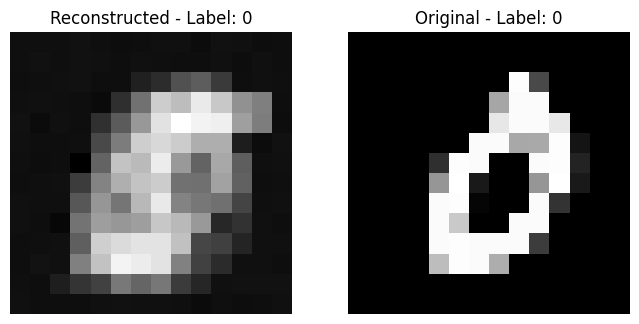

Applying profile...   success
Sweep complete.
mu tensor([[-0.2113,  0.0985,  0.5861]], grad_fn=<AddmmBackward0>) and std tensor([[1.3902, 0.5371, 1.2229]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9467377066612244 and KLD 0.0925920158624649 xshape 14


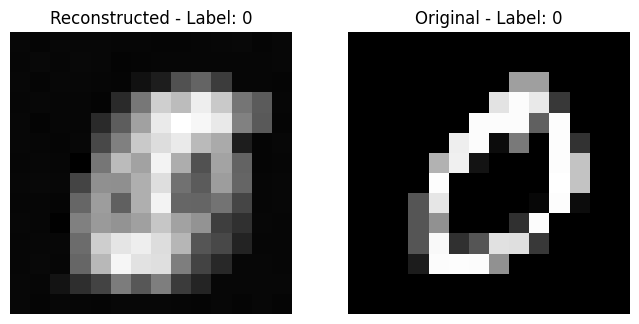

Applying profile...   success
Sweep complete.
mu tensor([[-0.0081,  0.4073,  0.6973]], grad_fn=<AddmmBackward0>) and std tensor([[1.5995, 0.7819, 0.8991]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6778038144111633 and KLD 0.09969252347946167 xshape 14


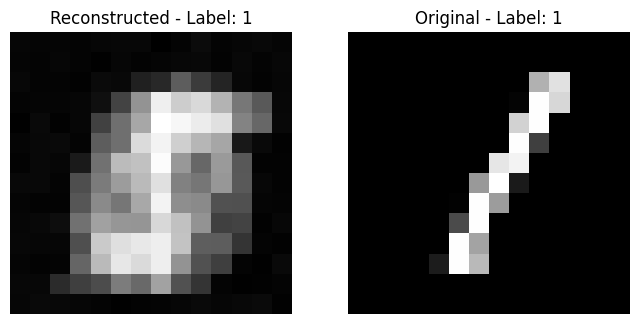

Applying profile...   success
Sweep complete.
mu tensor([[0.3767, 0.1533, 0.9343]], grad_fn=<AddmmBackward0>) and std tensor([[1.3444, 0.6976, 0.9928]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6592573523521423 and KLD 0.10434126853942871 xshape 14


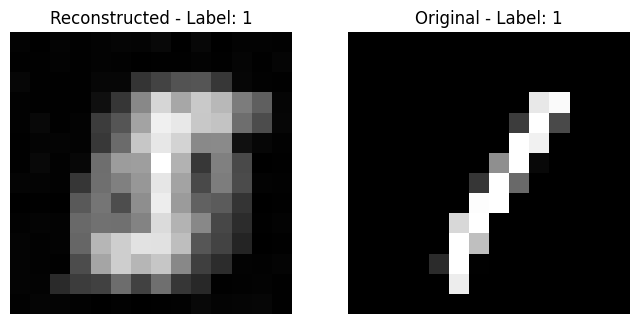

Applying profile...   success
Sweep complete.
mu tensor([[-0.0738,  0.3289,  1.0033]], grad_fn=<AddmmBackward0>) and std tensor([[1.3760, 0.8502, 0.8433]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7523470520973206 and KLD 0.10534369945526123 xshape 14


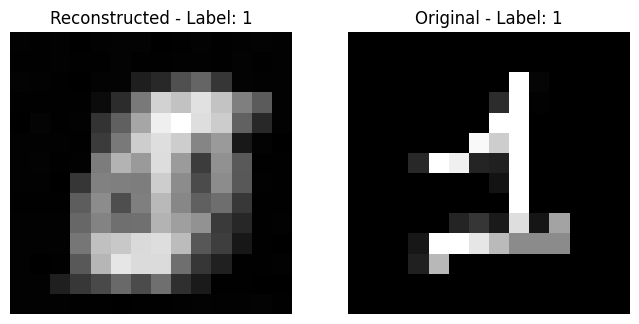

Applying profile...   success
Sweep complete.
mu tensor([[0.1686, 0.3208, 0.8190]], grad_fn=<AddmmBackward0>) and std tensor([[1.4806, 0.8117, 0.9038]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7413949966430664 and KLD 0.09318729490041733 xshape 14


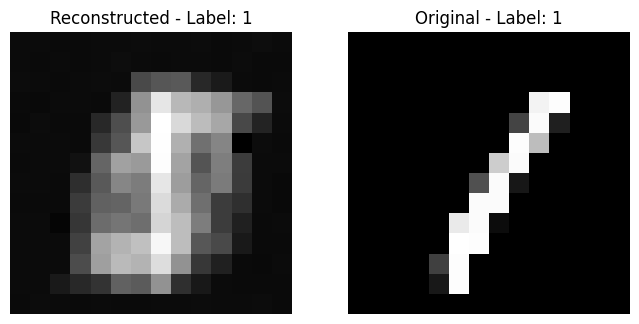

Applying profile...   success
Sweep complete.
mu tensor([[-0.0144,  0.9882, -0.2074]], grad_fn=<AddmmBackward0>) and std tensor([[1.1127, 0.8174, 1.0732]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9140768647193909 and KLD 0.08044151216745377 xshape 14


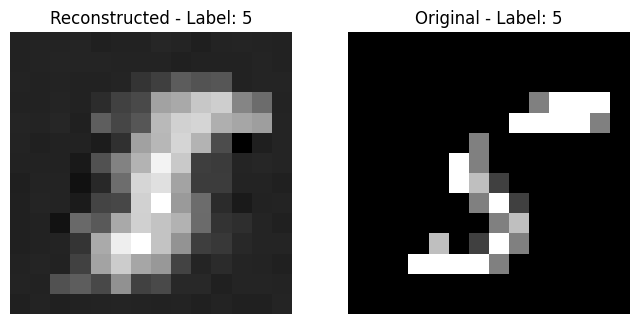

Epoch 5/15, Loss: 1.0379
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[0.7068, 0.7145, 0.9581]], grad_fn=<AddmmBackward0>) and std tensor([[0.9337, 0.9616, 0.9427]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1998203992843628 and KLD 0.13904911279678345 xshape 14


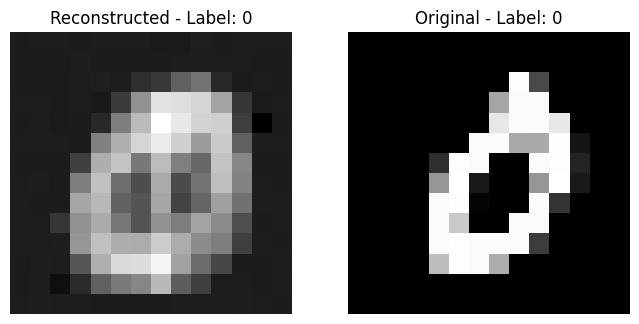

Applying profile...   success
Sweep complete.
mu tensor([[-0.0819,  0.3354,  1.0286]], grad_fn=<AddmmBackward0>) and std tensor([[1.3964, 0.8521, 0.8502]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7392100095748901 and KLD 0.11091684550046921 xshape 14


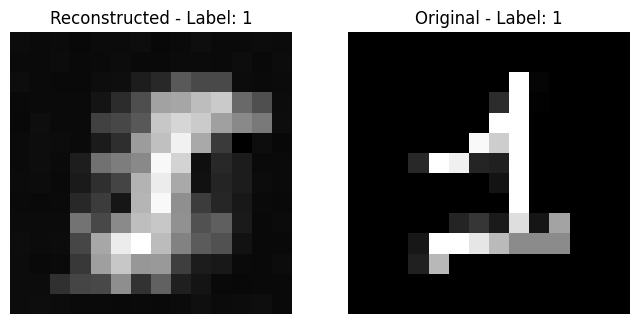

Applying profile...   success
Sweep complete.
mu tensor([[-0.2416,  0.1141,  0.5747]], grad_fn=<AddmmBackward0>) and std tensor([[1.4556, 0.5094, 1.2830]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8262022733688354 and KLD 0.1089930534362793 xshape 14


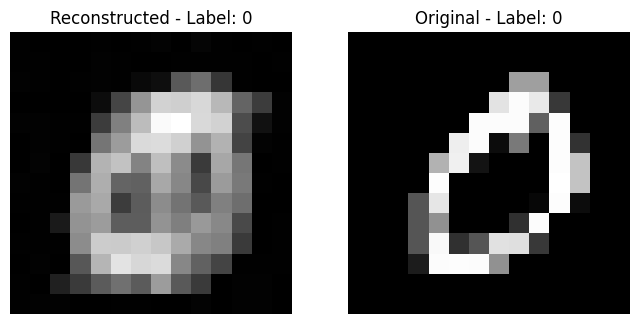

Applying profile...   success
Sweep complete.
mu tensor([[0.8658, 1.3302, 0.9483]], grad_fn=<AddmmBackward0>) and std tensor([[1.4239, 0.6623, 0.8163]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.4942139387130737 and KLD 0.2910034954547882 xshape 14


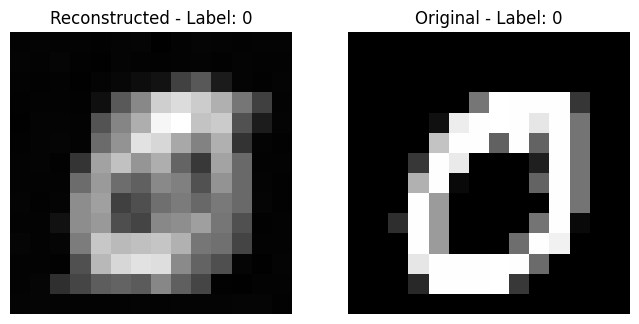

Applying profile...   success
Sweep complete.
mu tensor([[0.5094, 0.9993, 1.3769]], grad_fn=<AddmmBackward0>) and std tensor([[1.0225, 0.8643, 0.7762]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6919168829917908 and KLD 0.23590731620788574 xshape 14


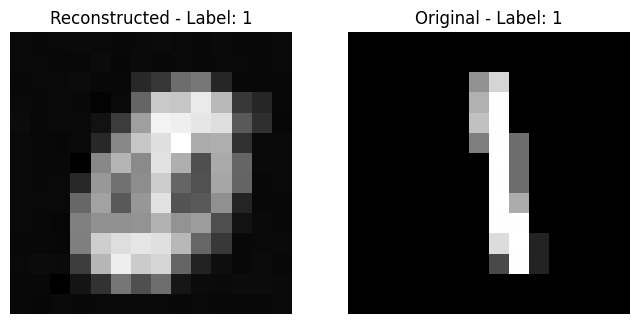

Applying profile...   success
Sweep complete.
mu tensor([[0.0804, 0.4973, 0.5047]], grad_fn=<AddmmBackward0>) and std tensor([[1.6190, 0.8690, 0.8920]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6252401471138 and KLD 0.0875973328948021 xshape 14


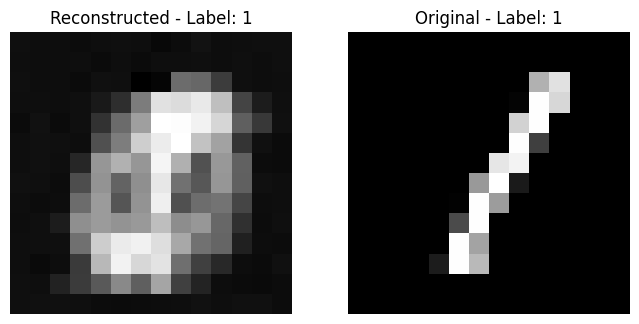

Applying profile...   success
Sweep complete.
mu tensor([[ 0.1530, -0.6089,  0.5825]], grad_fn=<AddmmBackward0>) and std tensor([[1.0433, 0.9124, 1.1597]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5893679857254028 and KLD 0.05725375935435295 xshape 14


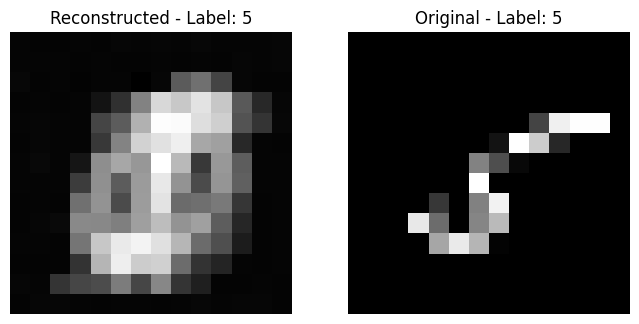

Applying profile...   success
Sweep complete.
mu tensor([[0.4408, 0.1339, 0.9527]], grad_fn=<AddmmBackward0>) and std tensor([[1.4193, 0.7924, 1.0358]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5429635643959045 and KLD 0.10927830636501312 xshape 14


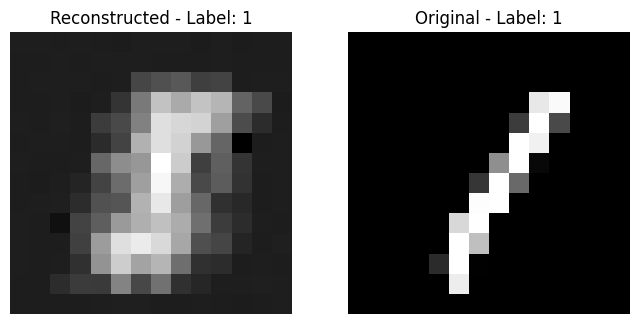

Applying profile...   success
Sweep complete.
mu tensor([[-1.0451,  0.5353,  0.5730]], grad_fn=<AddmmBackward0>) and std tensor([[1.8064, 0.9521, 1.0838]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7304700016975403 and KLD 0.20040856301784515 xshape 14


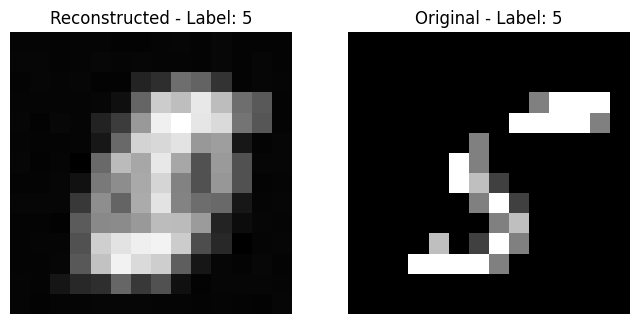

Applying profile...   success
Sweep complete.
mu tensor([[0.9797, 1.3631, 1.0469]], grad_fn=<AddmmBackward0>) and std tensor([[1.0412, 0.5437, 1.0826]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5167251825332642 and KLD 0.31750088930130005 xshape 14


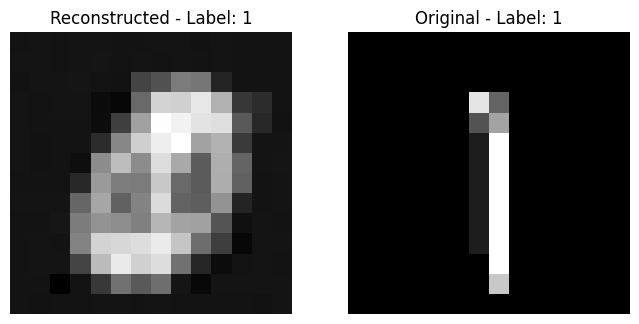

Applying profile...   success
Sweep complete.
mu tensor([[ 0.1372,  0.4559, -0.0991]], grad_fn=<AddmmBackward0>) and std tensor([[0.7251, 0.5569, 1.1414]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6393213868141174 and KLD 0.06601967662572861 xshape 14


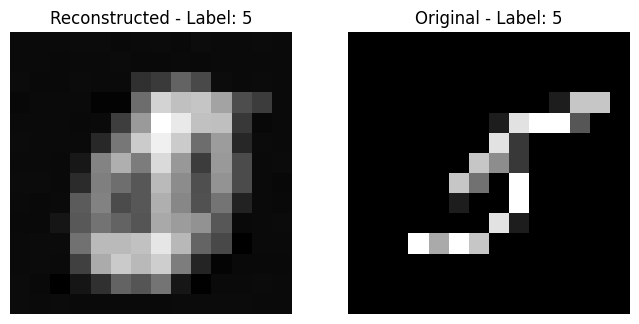

Applying profile...   success
Sweep complete.
mu tensor([[0.2765, 0.2194, 0.8440]], grad_fn=<AddmmBackward0>) and std tensor([[1.5158, 0.8512, 0.9616]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6135428547859192 and KLD 0.09660010039806366 xshape 14


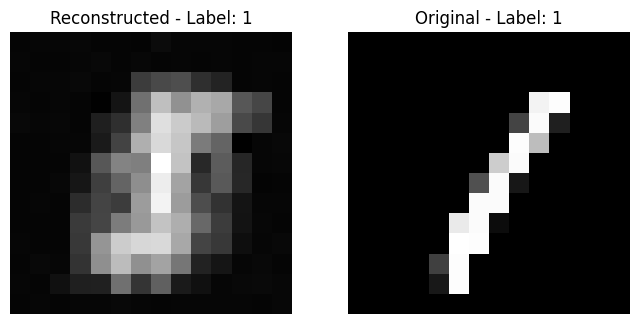

Applying profile...   success
Sweep complete.
mu tensor([[0.2627, 0.2553, 1.1452]], grad_fn=<AddmmBackward0>) and std tensor([[1.2239, 0.5307, 0.8792]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9863497614860535 and KLD 0.15133993327617645 xshape 14


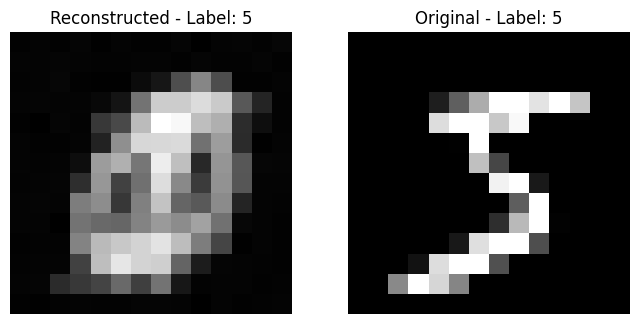

Applying profile...   success
Sweep complete.
mu tensor([[0.9681, 1.3813, 0.9525]], grad_fn=<AddmmBackward0>) and std tensor([[0.9779, 0.5293, 1.1578]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.47722679376602173 and KLD 0.31097570061683655 xshape 14


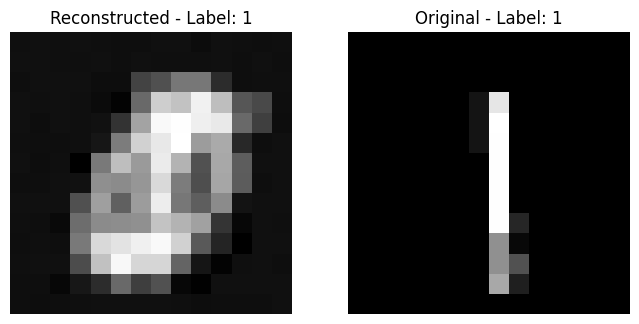

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0857, -0.1776,  0.9804]], grad_fn=<AddmmBackward0>) and std tensor([[1.5359, 0.6465, 1.0814]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.4378825426101685 and KLD 0.1288565844297409 xshape 14


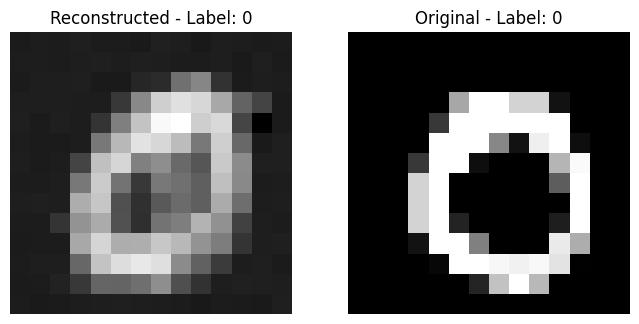

Applying profile...   success
Sweep complete.
mu tensor([[-0.1870,  0.1007,  0.7086]], grad_fn=<AddmmBackward0>) and std tensor([[1.0541, 0.9343, 0.6364]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8246949911117554 and KLD 0.062189556658267975 xshape 14


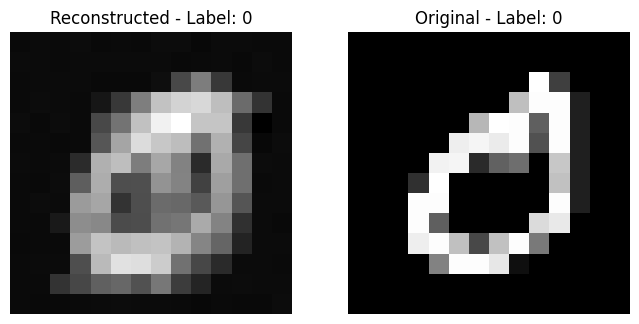

Applying profile...   success
Sweep complete.
mu tensor([[0.4495, 0.9090, 0.5523]], grad_fn=<AddmmBackward0>) and std tensor([[0.9737, 0.7423, 0.9716]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4703524708747864 and KLD 0.10595234483480453 xshape 14


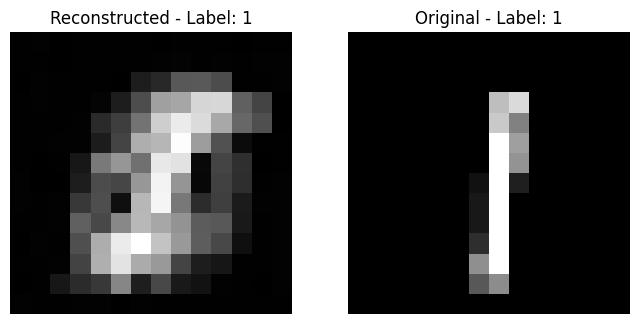

Applying profile...   success
Sweep complete.
mu tensor([[-0.4741, -0.5443,  0.2928]], grad_fn=<AddmmBackward0>) and std tensor([[1.9735, 1.0984, 1.2028]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.152649998664856 and KLD 0.15985199809074402 xshape 14


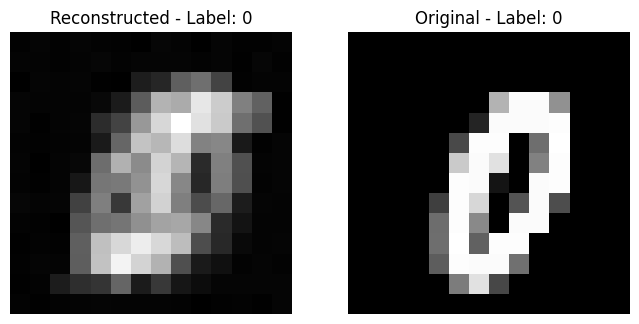

Epoch 6/15, Loss: 0.9914
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[0.4151, 1.0580, 0.3861]], grad_fn=<AddmmBackward0>) and std tensor([[1.0017, 0.7395, 0.9805]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.43391862511634827 and KLD 0.11371343582868576 xshape 14


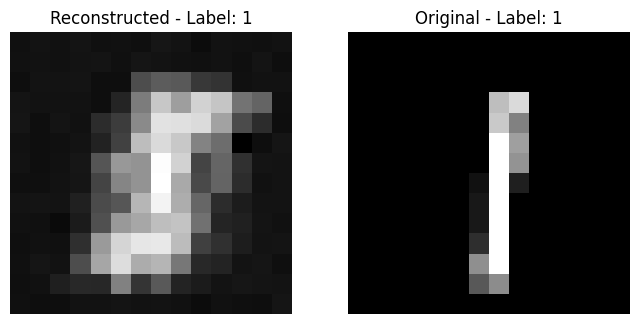

Applying profile...   success
Sweep complete.
mu tensor([[0.4385, 0.7030, 1.3438]], grad_fn=<AddmmBackward0>) and std tensor([[1.2515, 0.7556, 0.7609]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1489506959915161 and KLD 0.20476634800434113 xshape 14


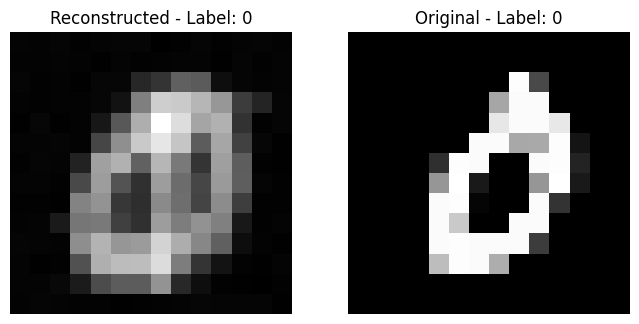

Applying profile...   success
Sweep complete.
mu tensor([[ 0.1226,  0.4215, -0.0330]], grad_fn=<AddmmBackward0>) and std tensor([[0.7592, 0.5552, 1.1360]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5731690526008606 and KLD 0.06012300029397011 xshape 14


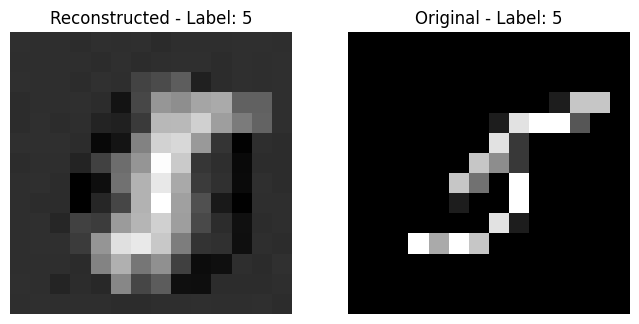

Applying profile...   success
Sweep complete.
mu tensor([[0.1920, 0.1884, 1.0400]], grad_fn=<AddmmBackward0>) and std tensor([[1.3022, 0.5186, 0.8841]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9436973333358765 and KLD 0.137981578707695 xshape 14


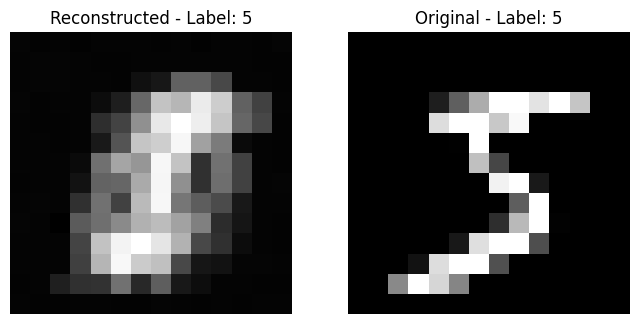

Applying profile...   success
Sweep complete.
mu tensor([[0.9316, 1.3266, 0.9730]], grad_fn=<AddmmBackward0>) and std tensor([[1.0908, 0.5559, 1.1781]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4615032374858856 and KLD 0.29529809951782227 xshape 14


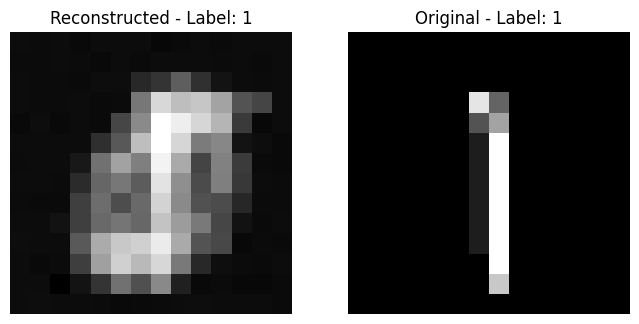

Applying profile...   success
Sweep complete.
mu tensor([[-0.3373,  0.3960,  0.8092]], grad_fn=<AddmmBackward0>) and std tensor([[1.5897, 0.8033, 0.8826]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6730744242668152 and KLD 0.11696100234985352 xshape 14


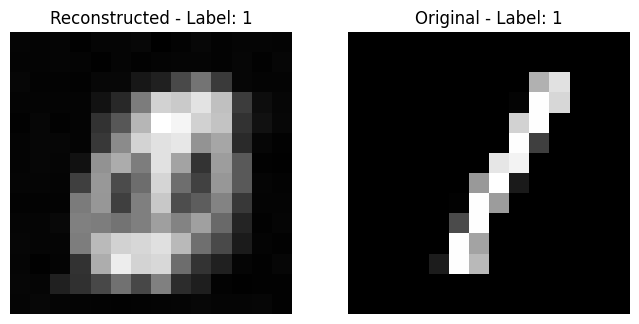

Applying profile...   success
Sweep complete.
mu tensor([[-0.8655,  0.7170,  1.0732]], grad_fn=<AddmmBackward0>) and std tensor([[1.6232, 0.8272, 1.1010]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8036494851112366 and KLD 0.22602586448192596 xshape 14


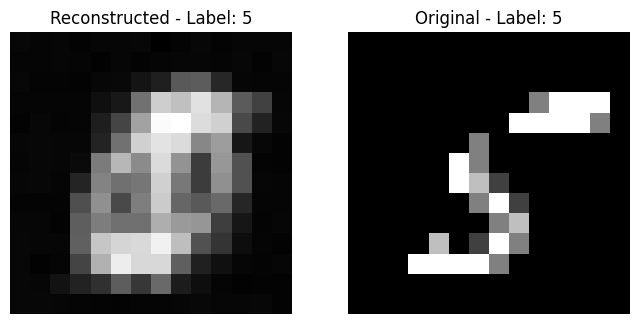

Applying profile...   success
Sweep complete.
mu tensor([[0.0112, 0.1322, 0.8785]], grad_fn=<AddmmBackward0>) and std tensor([[1.5980, 0.8270, 0.9083]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6915290951728821 and KLD 0.10619668662548065 xshape 14


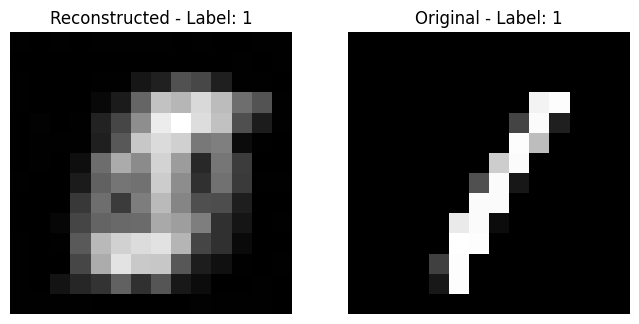

Applying profile...   success
Sweep complete.
mu tensor([[-1.3306,  0.5581,  0.0407]], grad_fn=<AddmmBackward0>) and std tensor([[1.4889, 0.7023, 0.8603]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.275795340538025 and KLD 0.19610463082790375 xshape 14


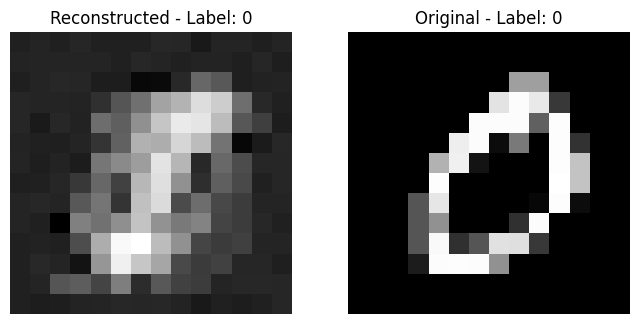

Applying profile...   success
Sweep complete.
mu tensor([[0.9673, 1.0937, 1.4429]], grad_fn=<AddmmBackward0>) and std tensor([[1.9373, 0.4789, 1.2408]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.7568453550338745 and KLD 0.4610114097595215 xshape 14


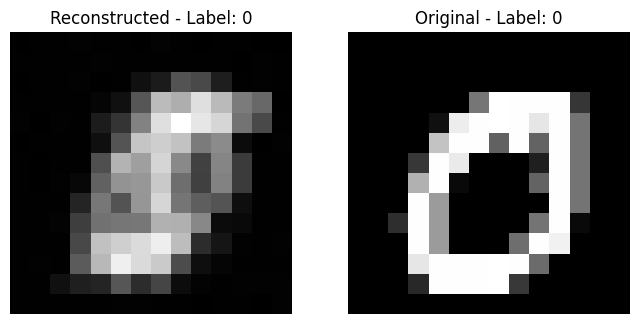

Applying profile...   success
Sweep complete.
mu tensor([[ 0.4645, -0.0886,  0.8133]], grad_fn=<AddmmBackward0>) and std tensor([[1.0643, 0.6936, 1.1915]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6846140623092651 and KLD 0.08394050598144531 xshape 14


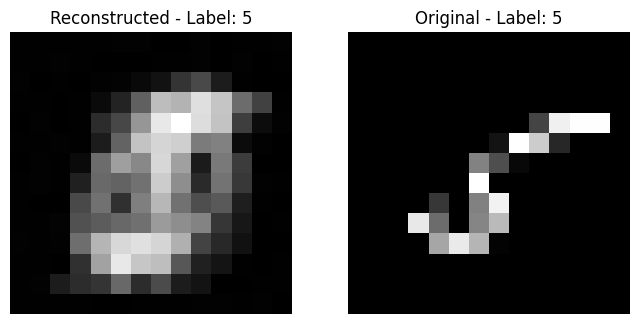

Applying profile...   success
Sweep complete.
mu tensor([[0.3138, 0.9740, 1.2195]], grad_fn=<AddmmBackward0>) and std tensor([[1.1963, 0.7699, 0.8415]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5725151300430298 and KLD 0.1982811540365219 xshape 14


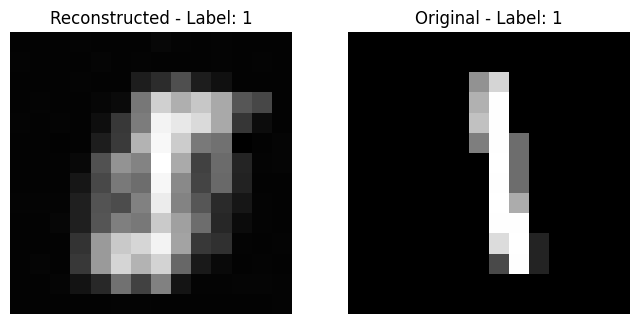

Applying profile...   success
Sweep complete.
mu tensor([[0.4020, 1.1352, 0.5923]], grad_fn=<AddmmBackward0>) and std tensor([[1.1843, 0.4569, 1.6895]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4388771653175354 and KLD 0.24616792798042297 xshape 14


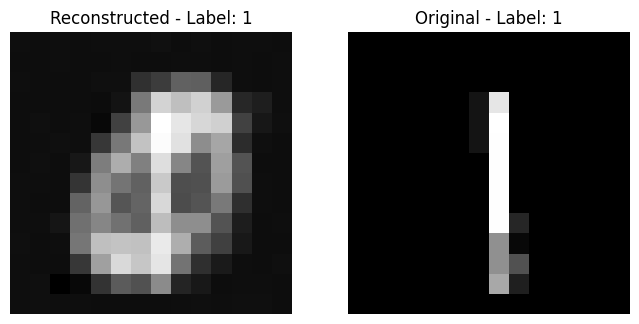

Applying profile...   success
Sweep complete.
mu tensor([[-0.2087, -0.0152,  1.0860]], grad_fn=<AddmmBackward0>) and std tensor([[1.8721, 0.6573, 1.0058]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.3344557285308838 and KLD 0.196069598197937 xshape 14


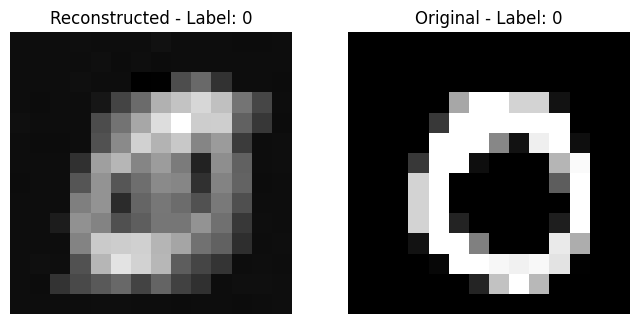

Applying profile...   success
Sweep complete.
mu tensor([[0.3664, 1.3188, 0.7668]], grad_fn=<AddmmBackward0>) and std tensor([[0.6899, 0.6532, 0.8276]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7162457704544067 and KLD 0.2158360779285431 xshape 14


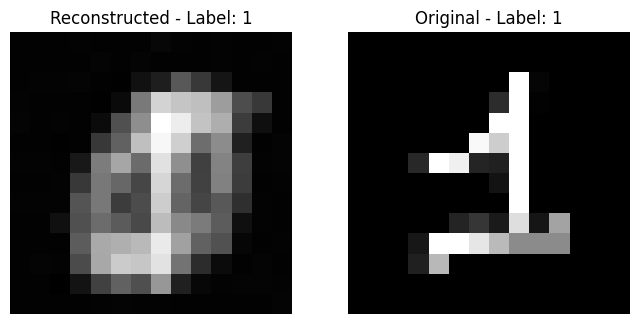

Applying profile...   success
Sweep complete.
mu tensor([[-0.5940,  1.0868,  0.4013]], grad_fn=<AddmmBackward0>) and std tensor([[0.9162, 0.5023, 0.9066]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7826112508773804 and KLD 0.16834528744220734 xshape 14


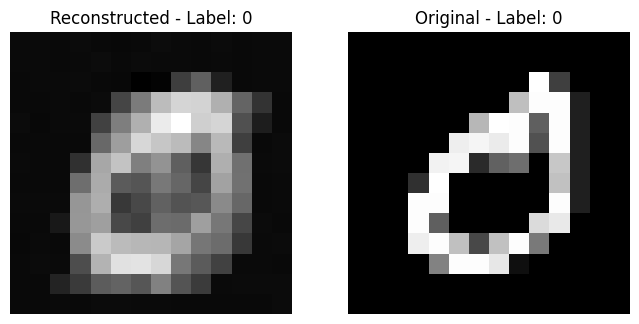

Applying profile...   success
Sweep complete.
mu tensor([[-0.2864,  0.6591,  0.8617]], grad_fn=<AddmmBackward0>) and std tensor([[1.4188, 0.6417, 0.9447]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7175222039222717 and KLD 0.1341187059879303 xshape 14


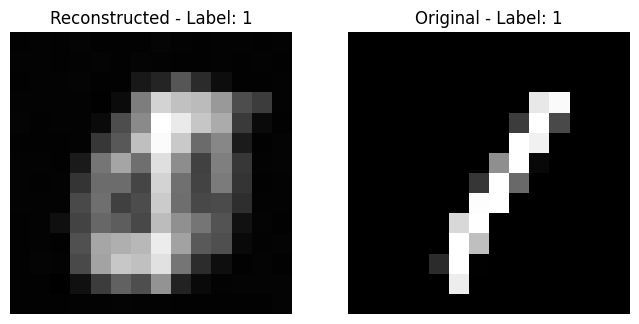

Applying profile...   success
Sweep complete.
mu tensor([[-0.5171, -0.1876, -0.2344]], grad_fn=<AddmmBackward0>) and std tensor([[2.3347, 0.7663, 1.2361]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.7020236253738403 and KLD 0.2382855862379074 xshape 14


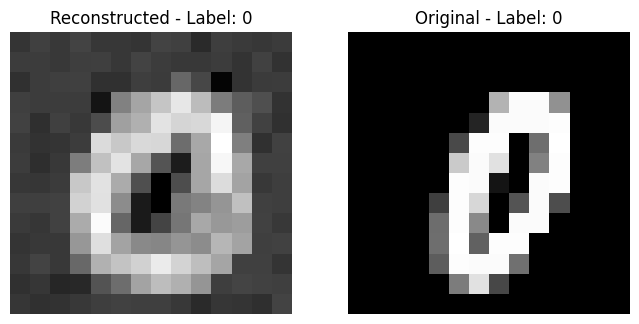

Epoch 7/15, Loss: 1.0994
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[-0.1510,  0.7076,  0.3177]], grad_fn=<AddmmBackward0>) and std tensor([[1.3164, 0.6252, 0.9295]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5821462869644165 and KLD 0.08200236409902573 xshape 14


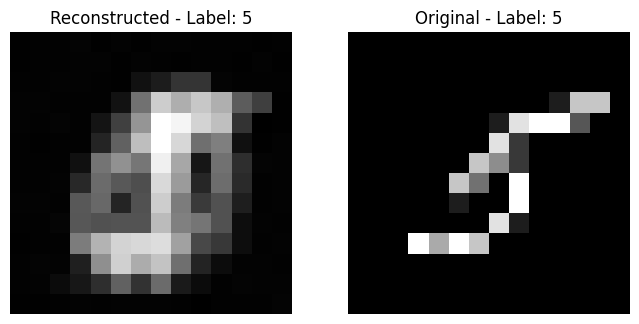

Applying profile...   success
Sweep complete.
mu tensor([[ 0.1375,  0.9884, -0.2379]], grad_fn=<AddmmBackward0>) and std tensor([[0.5655, 0.6653, 1.4076]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5463780760765076 and KLD 0.147690087556839 xshape 14


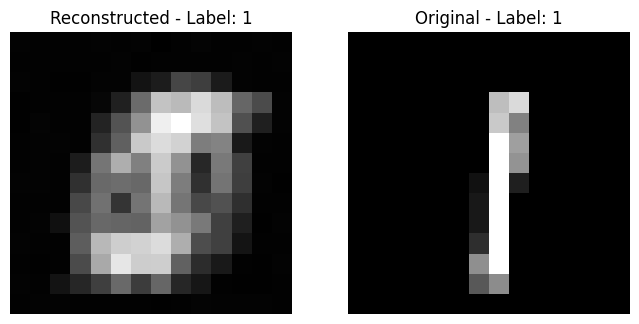

Applying profile...   success
Sweep complete.
mu tensor([[-0.7517,  1.0633,  0.1829]], grad_fn=<AddmmBackward0>) and std tensor([[0.9750, 0.5420, 0.8992]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.760292649269104 and KLD 0.1621456891298294 xshape 14


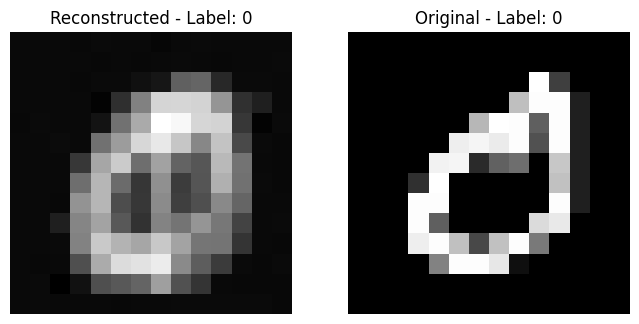

Applying profile...   success
Sweep complete.
mu tensor([[-0.7760,  0.4900,  0.4512]], grad_fn=<AddmmBackward0>) and std tensor([[1.6945, 0.9409, 0.8191]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5272027254104614 and KLD 0.13852883875370026 xshape 14


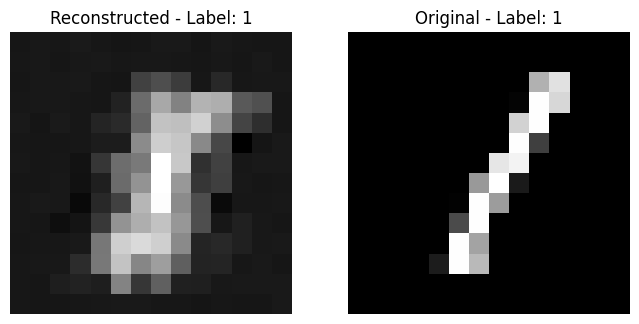

Applying profile...   success
Sweep complete.
mu tensor([[0.2998, 0.1580, 0.7548]], grad_fn=<AddmmBackward0>) and std tensor([[1.0359, 0.5657, 1.2328]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7294008135795593 and KLD 0.08912951499223709 xshape 14


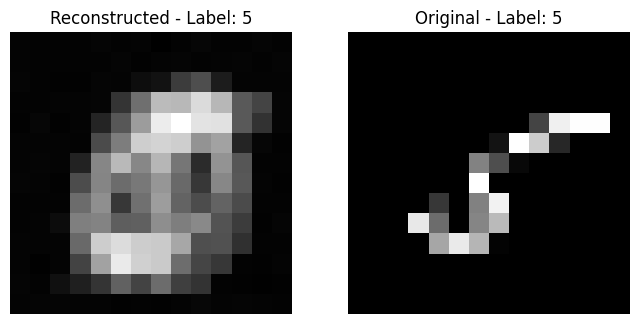

Applying profile...   success
Sweep complete.
mu tensor([[-0.0310,  1.3178,  0.8649]], grad_fn=<AddmmBackward0>) and std tensor([[0.9352, 0.4141, 1.3304]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6901785731315613 and KLD 0.25912991166114807 xshape 14


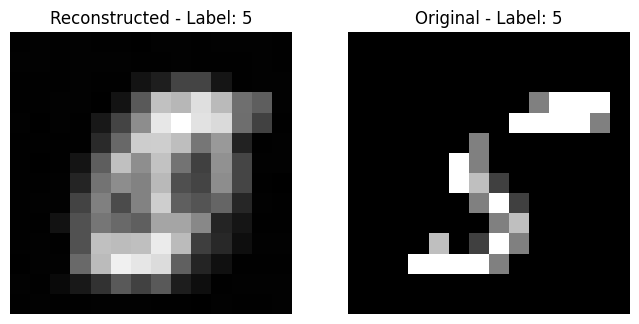

Applying profile...   success
Sweep complete.
mu tensor([[0.2197, 1.4380, 0.7360]], grad_fn=<AddmmBackward0>) and std tensor([[0.7463, 0.6378, 0.7575]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7158518433570862 and KLD 0.23112379014492035 xshape 14


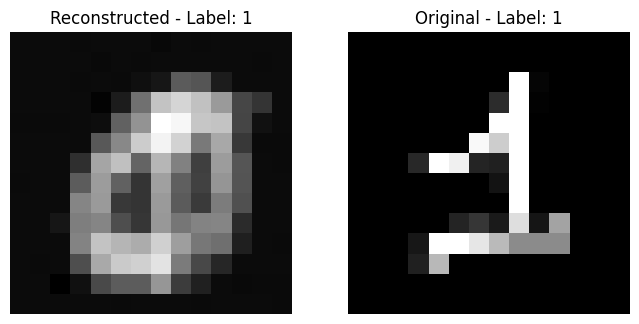

Applying profile...   success
Sweep complete.
mu tensor([[-0.4067,  0.3220,  0.6509]], grad_fn=<AddmmBackward0>) and std tensor([[1.6245, 0.8673, 0.7752]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5351666808128357 and KLD 0.10775315761566162 xshape 14


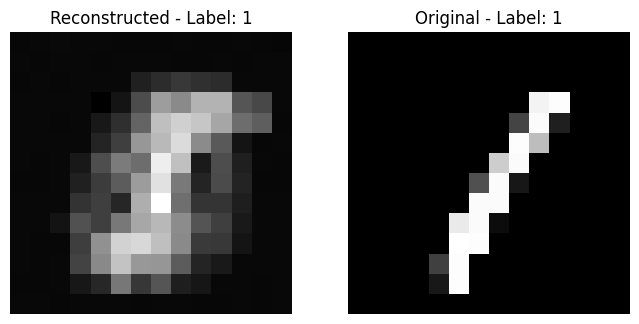

Applying profile...   success
Sweep complete.
mu tensor([[-0.1704,  0.0418,  1.1556]], grad_fn=<AddmmBackward0>) and std tensor([[1.3845, 0.9014, 0.8142]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1155153512954712 and KLD 0.12331584841012955 xshape 14


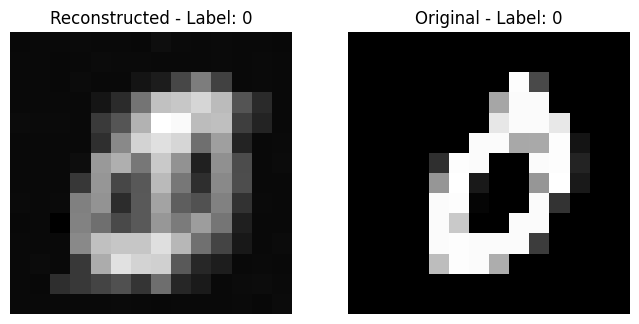

Applying profile...   success
Sweep complete.
mu tensor([[0.1623, 1.1215, 0.3716]], grad_fn=<AddmmBackward0>) and std tensor([[1.5948, 0.4374, 1.7198]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4459240138530731 and KLD 0.2678929269313812 xshape 14


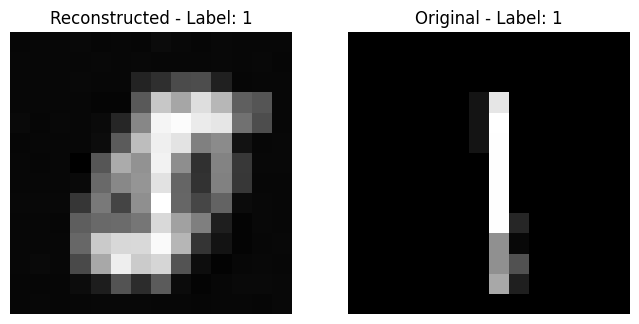

Applying profile...   success
Sweep complete.
mu tensor([[-0.9592,  0.8480, -0.3101]], grad_fn=<AddmmBackward0>) and std tensor([[1.4918, 0.8069, 0.7379]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6512222290039062 and KLD 0.17096421122550964 xshape 14


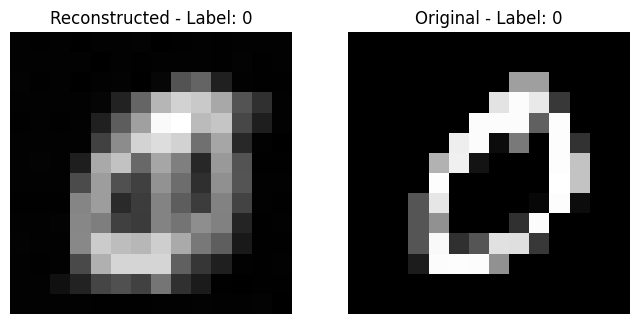

Applying profile...   success
Sweep complete.
mu tensor([[-0.5064, -0.0435, -0.1139]], grad_fn=<AddmmBackward0>) and std tensor([[2.0605, 0.7582, 1.1018]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.4650919437408447 and KLD 0.15855315327644348 xshape 14


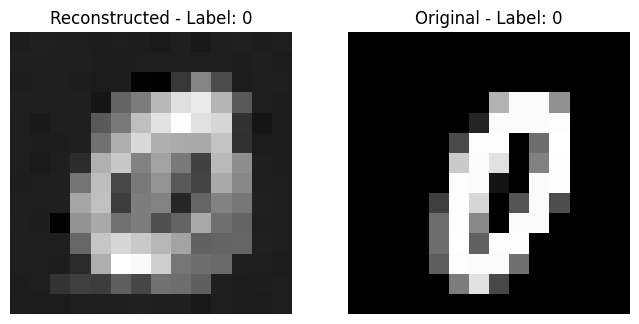

Applying profile...   success
Sweep complete.
mu tensor([[-0.2099,  0.8405,  1.0263]], grad_fn=<AddmmBackward0>) and std tensor([[1.6181, 0.7065, 0.9015]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8125929236412048 and KLD 0.19098062813282013 xshape 14


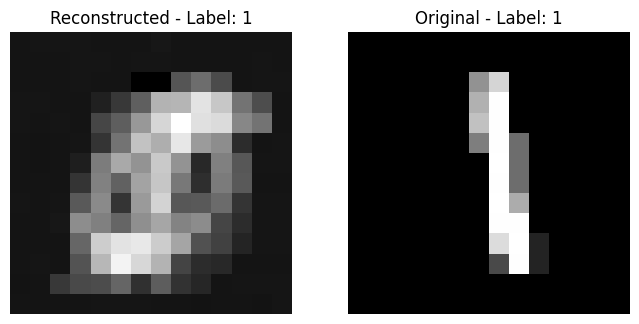

Applying profile...   success
Sweep complete.
mu tensor([[-0.0553,  0.4661,  0.8299]], grad_fn=<AddmmBackward0>) and std tensor([[1.4570, 0.7739, 0.7656]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6524252891540527 and KLD 0.10792861878871918 xshape 14


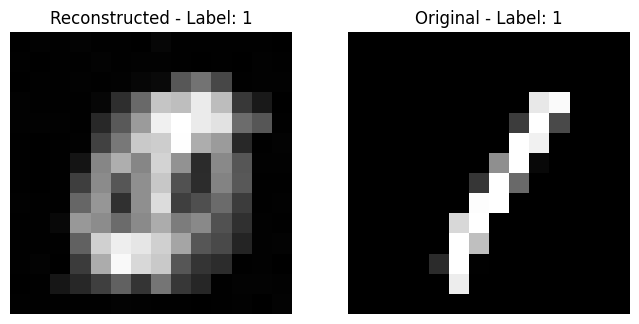

Applying profile...   success
Sweep complete.
mu tensor([[0.2551, 0.2873, 1.0422]], grad_fn=<AddmmBackward0>) and std tensor([[1.7050, 0.6568, 0.9010]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.7531321048736572 and KLD 0.16901938617229462 xshape 14


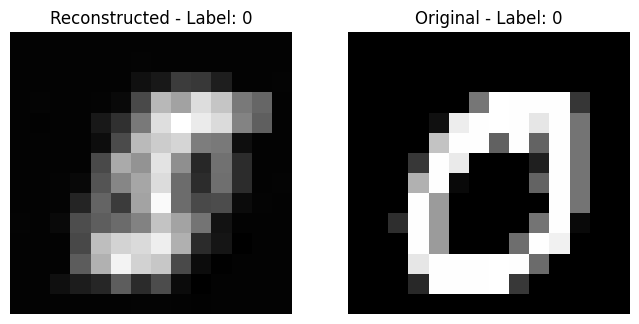

Applying profile...   success
Sweep complete.
mu tensor([[0.4124, 0.7695, 0.6335]], grad_fn=<AddmmBackward0>) and std tensor([[1.3195, 0.5304, 1.7281]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.49605458974838257 and KLD 0.1994379311800003 xshape 14


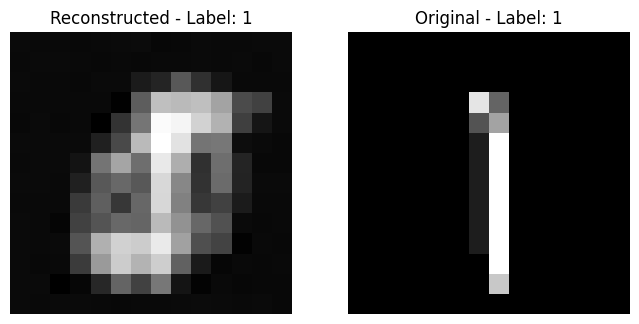

Applying profile...   success
Sweep complete.
mu tensor([[-0.3444, -0.0260,  0.9819]], grad_fn=<AddmmBackward0>) and std tensor([[1.9648, 0.6697, 1.0052]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.8991769552230835 and KLD 0.2031116485595703 xshape 14


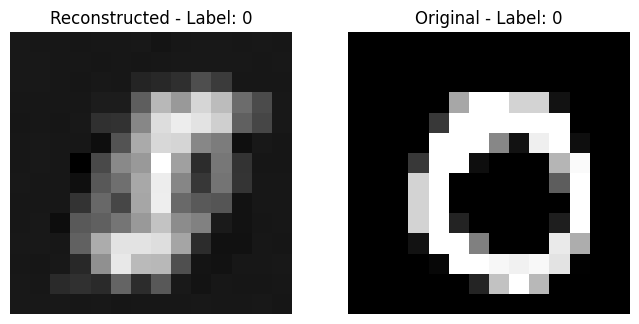

Applying profile...   success
Sweep complete.
mu tensor([[0.0498, 0.6602, 1.1823]], grad_fn=<AddmmBackward0>) and std tensor([[1.1495, 0.4633, 1.3993]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.154085397720337 and KLD 0.2084532529115677 xshape 14


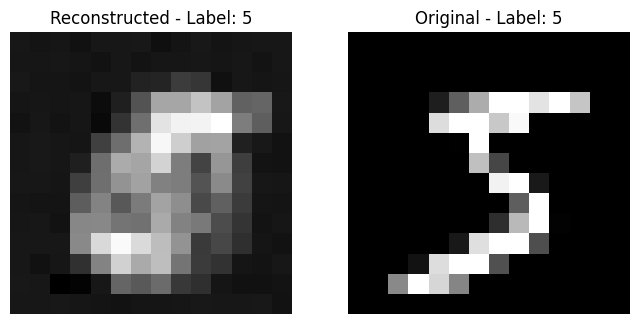

Epoch 8/15, Loss: 1.0640
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[0.0398, 0.6381, 1.1539]], grad_fn=<AddmmBackward0>) and std tensor([[1.1267, 0.4567, 1.3883]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1819008588790894 and KLD 0.2013096660375595 xshape 14


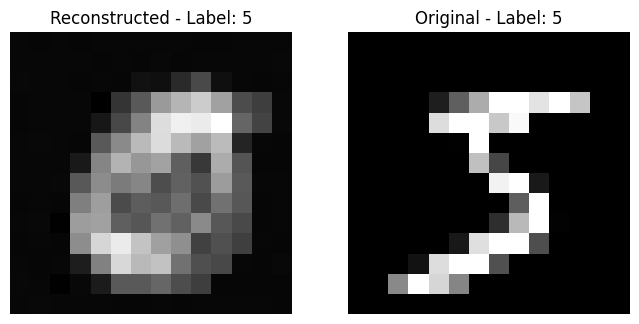

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0091, -0.4697,  0.2002]], grad_fn=<AddmmBackward0>) and std tensor([[1.0863, 0.9469, 1.1813]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6440569162368774 and KLD 0.024514155462384224 xshape 14


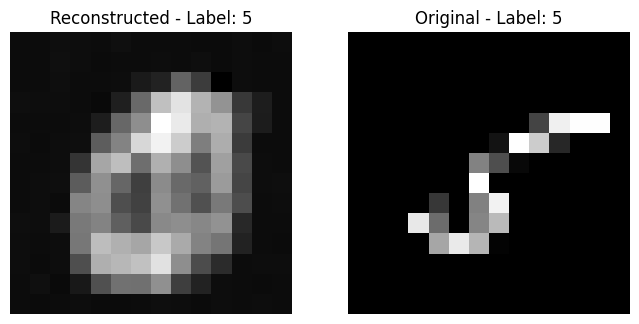

Applying profile...   success
Sweep complete.
mu tensor([[0.0936, 0.6384, 0.7742]], grad_fn=<AddmmBackward0>) and std tensor([[0.7476, 0.7484, 0.8831]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5612817406654358 and KLD 0.09461919963359833 xshape 14


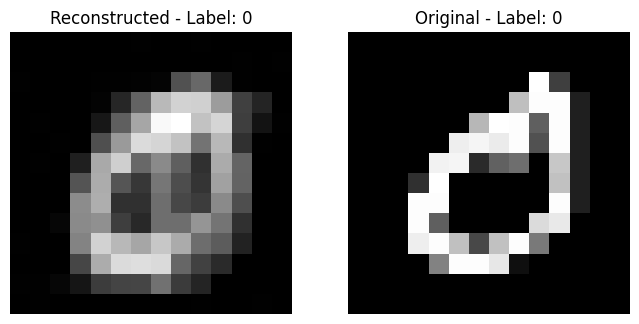

Applying profile...   success
Sweep complete.
mu tensor([[0.4577, 0.8552, 0.4025]], grad_fn=<AddmmBackward0>) and std tensor([[1.1467, 0.5486, 1.7453]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.588433563709259 and KLD 0.184149831533432 xshape 14


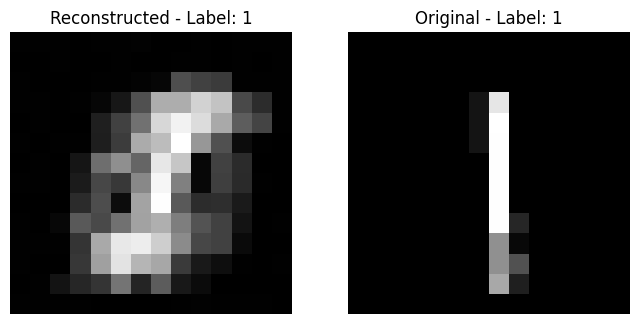

Applying profile...   success
Sweep complete.
mu tensor([[-0.8147,  0.8643, -0.2661]], grad_fn=<AddmmBackward0>) and std tensor([[1.4986, 0.8079, 0.7393]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6047693490982056 and KLD 0.1534455567598343 xshape 14


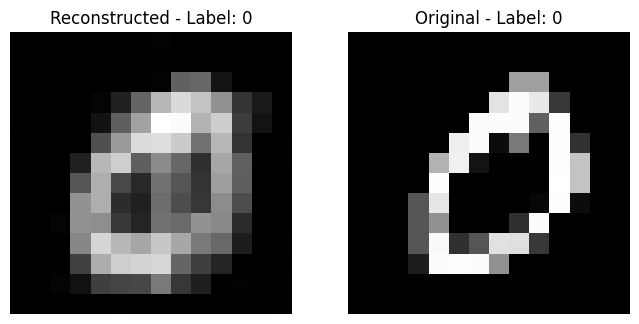

Applying profile...   success
Sweep complete.
mu tensor([[0.5693, 0.5725, 1.2930]], grad_fn=<AddmmBackward0>) and std tensor([[1.2250, 0.6497, 0.7876]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5316584706306458 and KLD 0.20006830990314484 xshape 14


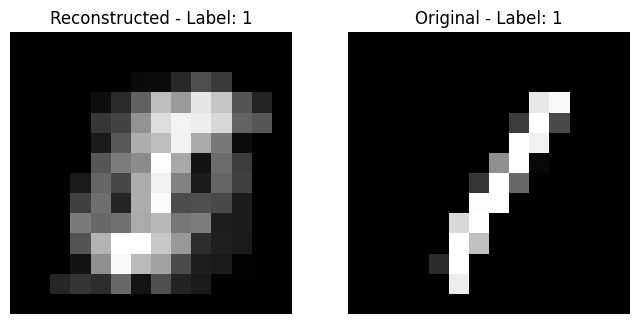

Applying profile...   success
Sweep complete.
mu tensor([[-0.0333,  0.3249,  0.8773]], grad_fn=<AddmmBackward0>) and std tensor([[1.4188, 0.8306, 0.7390]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5164420008659363 and KLD 0.10013458877801895 xshape 14


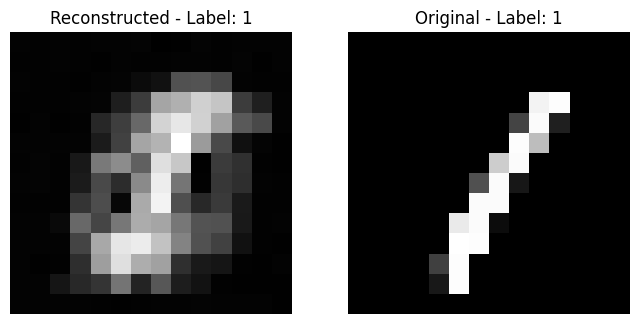

Applying profile...   success
Sweep complete.
mu tensor([[ 0.4558,  0.6067, -0.3001]], grad_fn=<AddmmBackward0>) and std tensor([[0.5975, 0.9100, 1.3032]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4169319272041321 and KLD 0.08844644576311111 xshape 14


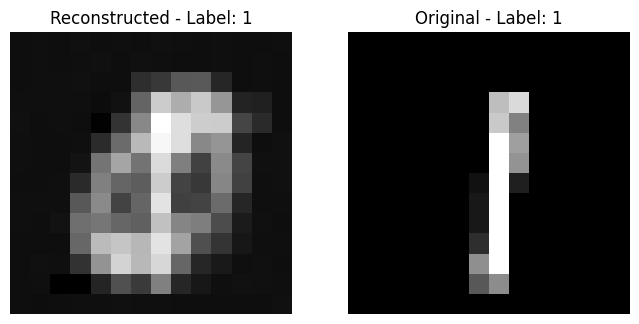

Applying profile...   success
Sweep complete.
mu tensor([[-0.4570, -0.0553,  0.2219]], grad_fn=<AddmmBackward0>) and std tensor([[1.9115, 0.7600, 0.9863]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.0440740585327148 and KLD 0.12471873313188553 xshape 14


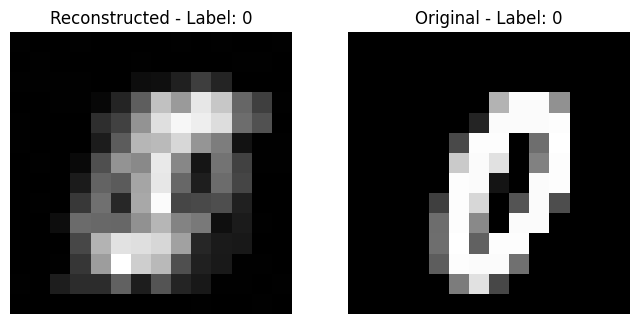

Applying profile...   success
Sweep complete.
mu tensor([[-1.3459, -0.0348, -0.3831]], grad_fn=<AddmmBackward0>) and std tensor([[2.0570, 1.0462, 1.0124]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5524846911430359 and KLD 0.2680520713329315 xshape 14


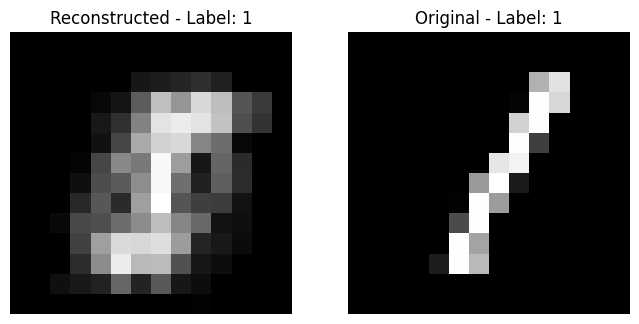

Applying profile...   success
Sweep complete.
mu tensor([[0.5952, 1.1048, 1.1698]], grad_fn=<AddmmBackward0>) and std tensor([[1.6284, 0.5627, 1.1248]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.91688472032547 and KLD 0.294039249420166 xshape 14


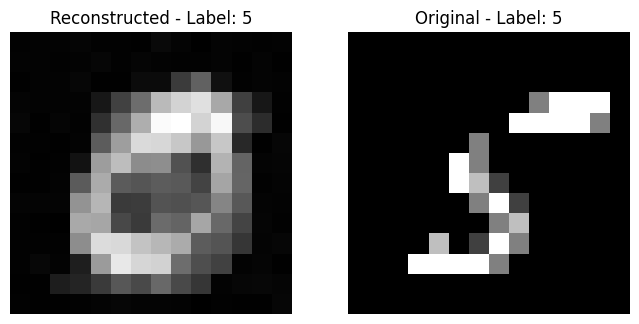

Applying profile...   success
Sweep complete.
mu tensor([[ 0.2173, -0.1642,  0.9944]], grad_fn=<AddmmBackward0>) and std tensor([[1.1496, 1.0572, 0.7789]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.141330599784851 and KLD 0.08704112470149994 xshape 14


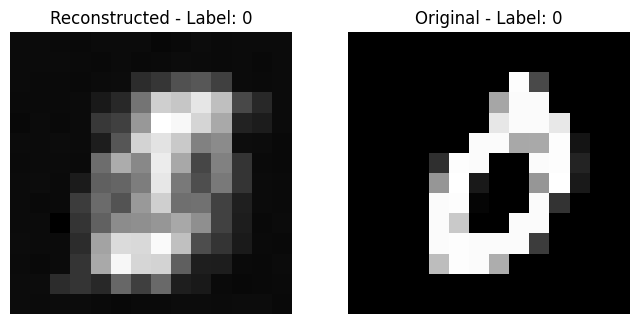

Applying profile...   success
Sweep complete.
mu tensor([[0.1577, 0.3323, 1.1181]], grad_fn=<AddmmBackward0>) and std tensor([[1.6447, 0.6498, 0.8561]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.3744009733200073 and KLD 0.17309096455574036 xshape 14


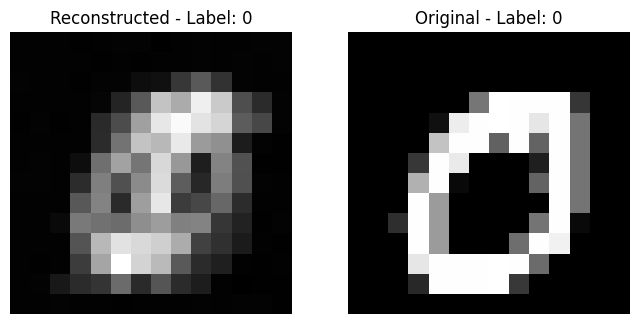

Applying profile...   success
Sweep complete.
mu tensor([[0.3837, 0.8430, 0.5597]], grad_fn=<AddmmBackward0>) and std tensor([[1.3852, 0.5591, 1.7782]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7022509574890137 and KLD 0.20889008045196533 xshape 14


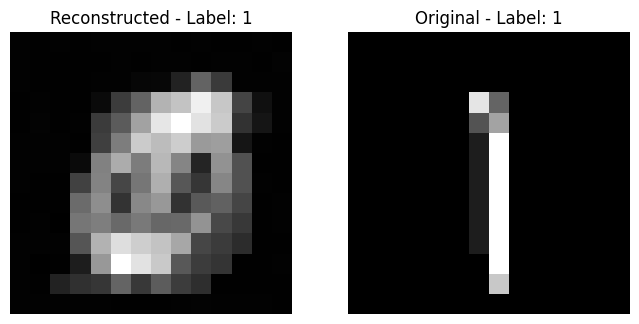

Applying profile...   success
Sweep complete.
mu tensor([[-0.4185,  0.0181,  0.9079]], grad_fn=<AddmmBackward0>) and std tensor([[1.9819, 0.6778, 0.9953]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.3995941877365112 and KLD 0.19977353513240814 xshape 14


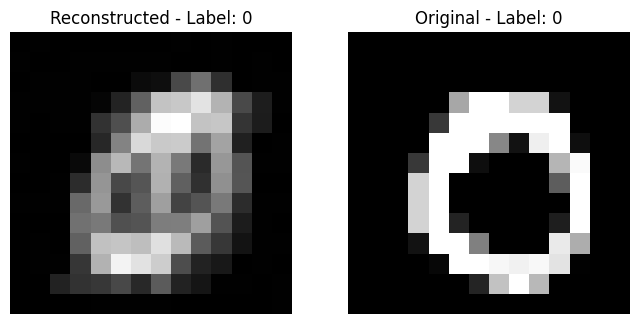

Applying profile...   success
Sweep complete.
mu tensor([[-0.1094,  0.8161,  0.2008]], grad_fn=<AddmmBackward0>) and std tensor([[0.9556, 0.5623, 0.9274]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5716387033462524 and KLD 0.08576703816652298 xshape 14


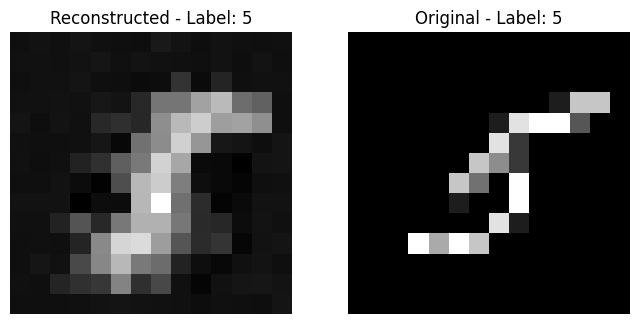

Applying profile...   success
Sweep complete.
mu tensor([[-0.2464,  0.9457,  0.9427]], grad_fn=<AddmmBackward0>) and std tensor([[1.7240, 0.6956, 0.9329]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7346529364585876 and KLD 0.2104063332080841 xshape 14


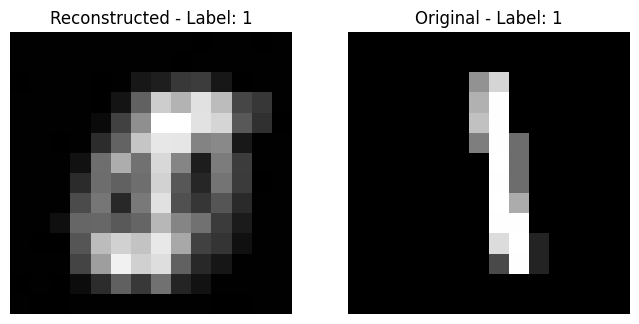

Applying profile...   success
Sweep complete.
mu tensor([[0.3719, 1.3704, 0.9418]], grad_fn=<AddmmBackward0>) and std tensor([[0.6617, 0.6412, 0.7493]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.688064694404602 and KLD 0.25756362080574036 xshape 14


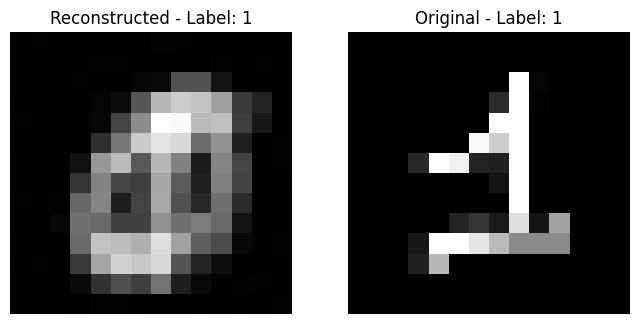

Epoch 9/15, Loss: 0.9843
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[-0.7466, -0.4695, -0.1107]], grad_fn=<AddmmBackward0>) and std tensor([[1.5510, 1.0853, 1.0505]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8233304619789124 and KLD 0.0955081507563591 xshape 14


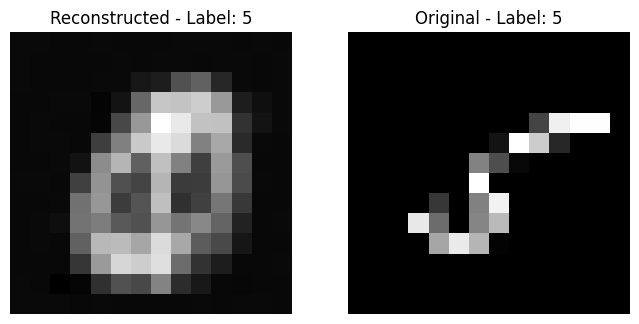

Applying profile...   success
Sweep complete.
mu tensor([[-1.2077, -0.0488, -0.4095]], grad_fn=<AddmmBackward0>) and std tensor([[2.1384, 0.9877, 1.0693]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5063248872756958 and KLD 0.263645738363266 xshape 14


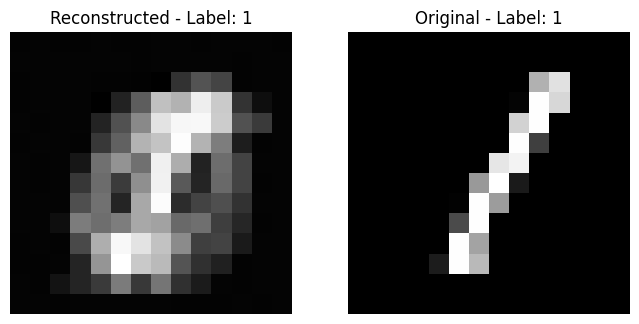

Applying profile...   success
Sweep complete.
mu tensor([[-0.4075,  0.0542,  0.9399]], grad_fn=<AddmmBackward0>) and std tensor([[1.9871, 0.6679, 0.9899]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.7785230875015259 and KLD 0.20578423142433167 xshape 14


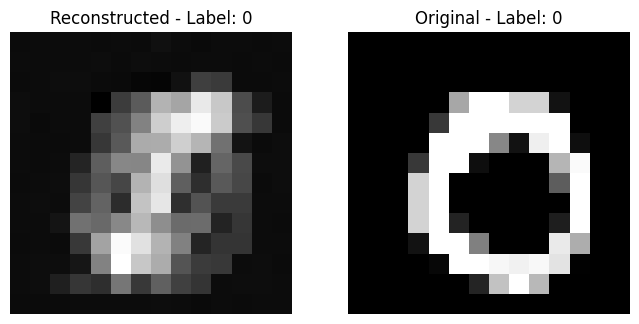

Applying profile...   success
Sweep complete.
mu tensor([[-1.1227, -0.0286, -0.0063]], grad_fn=<AddmmBackward0>) and std tensor([[2.2508, 0.9334, 0.9134]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5621042847633362 and KLD 0.2663825452327728 xshape 14


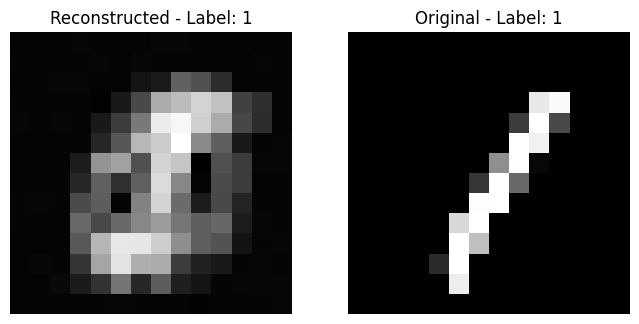

Applying profile...   success
Sweep complete.
mu tensor([[ 0.2285, -0.1257,  0.9470]], grad_fn=<AddmmBackward0>) and std tensor([[1.1124, 1.0645, 0.7612]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.0940144062042236 and KLD 0.08018479496240616 xshape 14


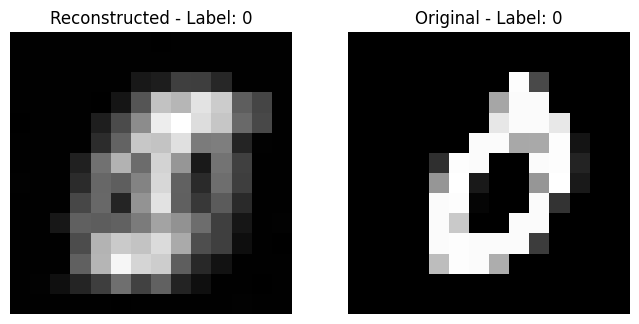

Applying profile...   success
Sweep complete.
mu tensor([[0.3400, 1.3615, 0.9144]], grad_fn=<AddmmBackward0>) and std tensor([[0.6533, 0.6441, 0.7398]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7671418190002441 and KLD 0.25202542543411255 xshape 14


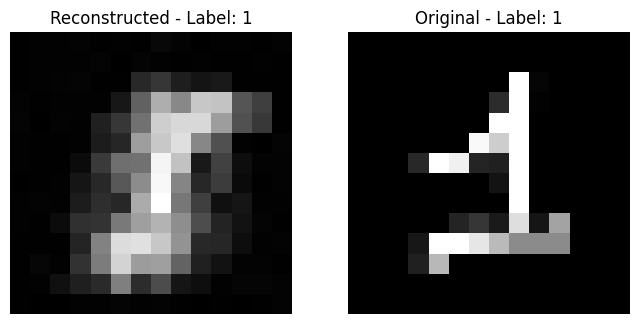

Applying profile...   success
Sweep complete.
mu tensor([[ 0.2924,  0.6840, -0.3308]], grad_fn=<AddmmBackward0>) and std tensor([[0.8364, 0.7498, 1.6032]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6060067415237427 and KLD 0.10600949078798294 xshape 14


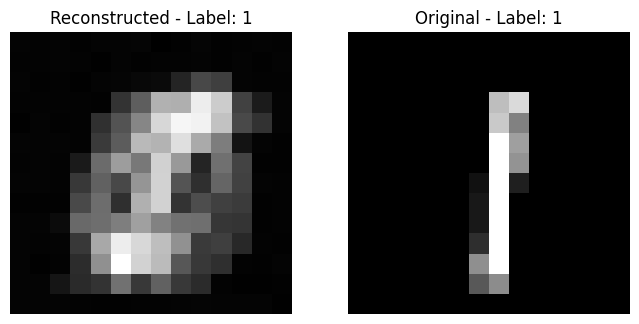

Applying profile...   success
Sweep complete.
mu tensor([[0.0872, 0.4783, 1.0540]], grad_fn=<AddmmBackward0>) and std tensor([[1.0732, 0.4856, 1.1993]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9934881329536438 and KLD 0.15093663334846497 xshape 14


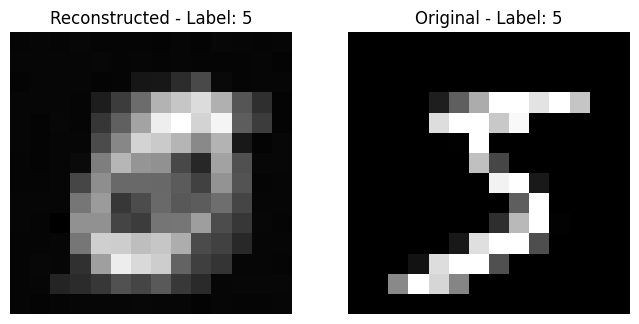

Applying profile...   success
Sweep complete.
mu tensor([[0.3160, 0.4640, 0.8442]], grad_fn=<AddmmBackward0>) and std tensor([[0.7033, 0.7803, 0.9466]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.0552695989608765 and KLD 0.09551382064819336 xshape 14


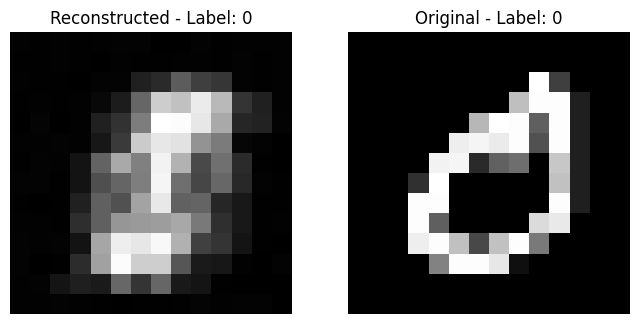

Applying profile...   success
Sweep complete.
mu tensor([[-0.4199,  0.0097, -0.0173]], grad_fn=<AddmmBackward0>) and std tensor([[1.8788, 0.7917, 1.0329]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.085917592048645 and KLD 0.11009221524000168 xshape 14


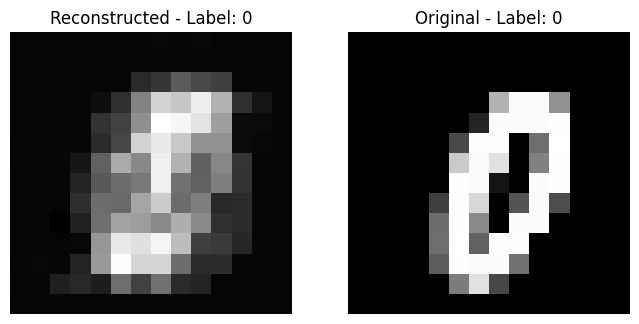

Applying profile...   success
Sweep complete.
mu tensor([[0.4581, 0.8716, 0.6420]], grad_fn=<AddmmBackward0>) and std tensor([[1.4690, 0.5584, 1.7220]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5906174778938293 and KLD 0.22327502071857452 xshape 14


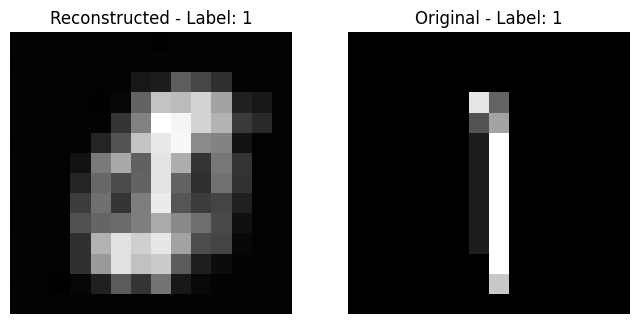

Applying profile...   success
Sweep complete.
mu tensor([[-0.3587,  0.8343,  0.9147]], grad_fn=<AddmmBackward0>) and std tensor([[1.8896, 0.7204, 0.9531]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7549533247947693 and KLD 0.22418956458568573 xshape 14


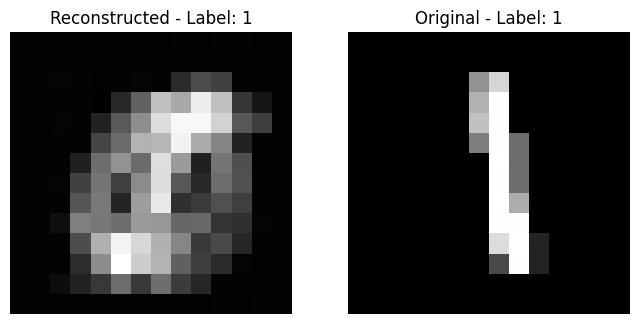

Applying profile...   success
Sweep complete.
mu tensor([[-0.0851,  0.7472,  0.1088]], grad_fn=<AddmmBackward0>) and std tensor([[0.7846, 0.5752, 0.9805]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6519284844398499 and KLD 0.07969079911708832 xshape 14


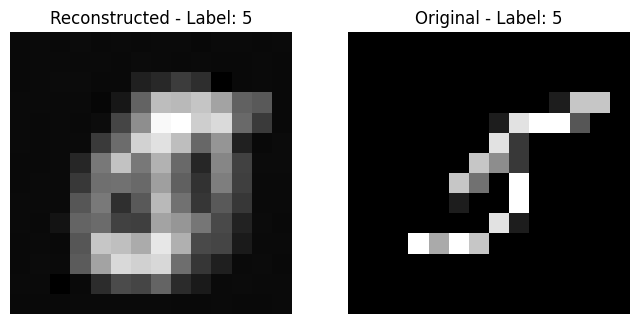

Applying profile...   success
Sweep complete.
mu tensor([[-0.5510,  0.9025,  0.2250]], grad_fn=<AddmmBackward0>) and std tensor([[1.3493, 0.7659, 0.7751]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8083206415176392 and KLD 0.11574502289295197 xshape 14


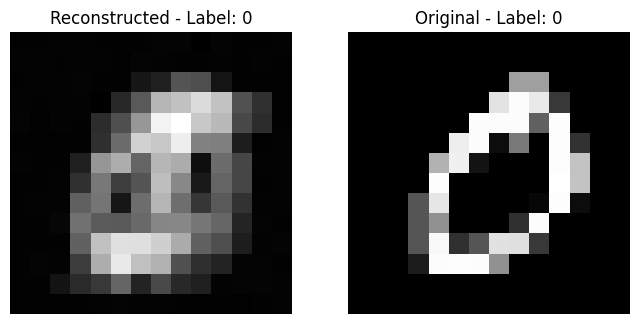

Applying profile...   success
Sweep complete.
mu tensor([[0.5492, 0.6656, 1.6311]], grad_fn=<AddmmBackward0>) and std tensor([[1.6996, 0.5905, 0.8647]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.4687319993972778 and KLD 0.33384138345718384 xshape 14


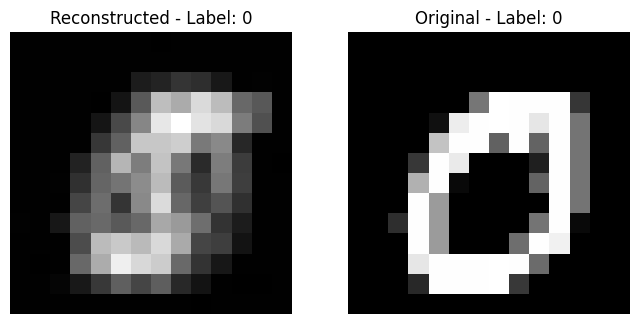

Applying profile...   success
Sweep complete.
mu tensor([[-0.9425, -0.2122,  0.0829]], grad_fn=<AddmmBackward0>) and std tensor([[2.1907, 1.0200, 0.9219]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6825350522994995 and KLD 0.22744536399841309 xshape 14


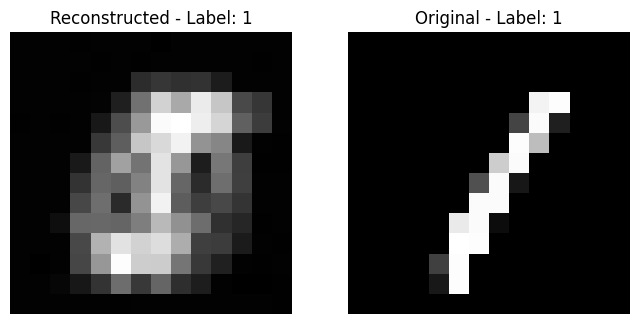

Applying profile...   success
Sweep complete.
mu tensor([[-0.4062,  0.7672,  1.3791]], grad_fn=<AddmmBackward0>) and std tensor([[1.2075, 0.6942, 0.8693]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8506201505661011 and KLD 0.21314497292041779 xshape 14


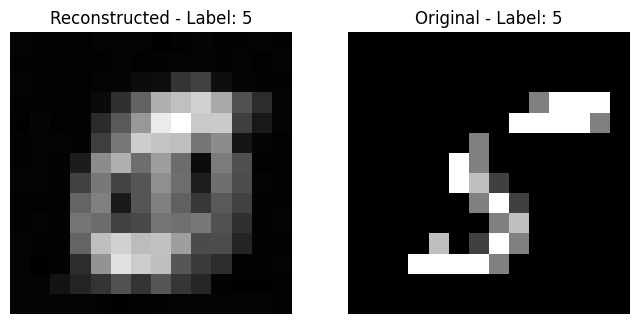

Applying profile...   success
Sweep complete.
mu tensor([[0.2444, 1.0335, 0.3275]], grad_fn=<AddmmBackward0>) and std tensor([[1.6692, 0.5048, 1.7560]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.561620831489563 and KLD 0.2554394602775574 xshape 14


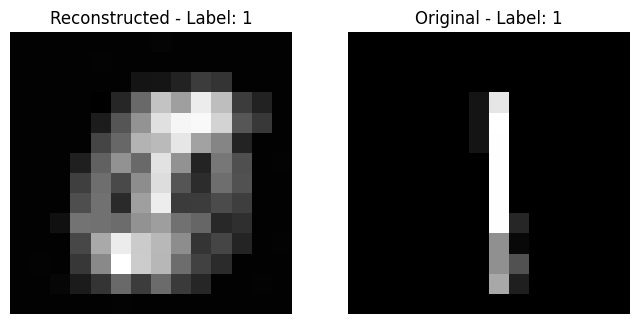

Epoch 10/15, Loss: 1.0889
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[-0.0469, -0.4292, -0.3293]], grad_fn=<AddmmBackward0>) and std tensor([[1.3826, 0.8522, 1.2445]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5328657031059265 and KLD 0.05113878473639488 xshape 14


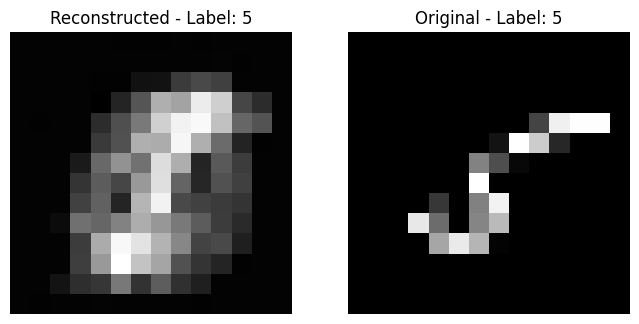

Applying profile...   success
Sweep complete.
mu tensor([[0.3860, 1.4132, 1.1267]], grad_fn=<AddmmBackward0>) and std tensor([[0.6278, 0.6215, 0.8576]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6360405683517456 and KLD 0.2943839132785797 xshape 14


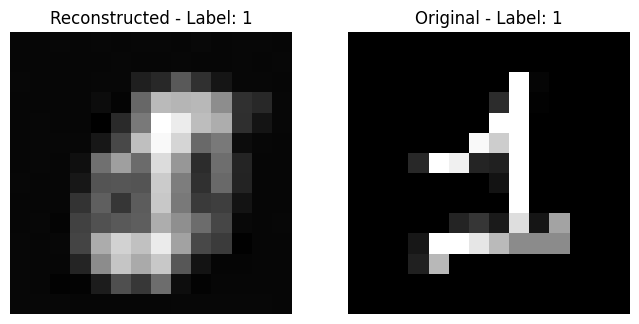

Applying profile...   success
Sweep complete.
mu tensor([[0.2120, 0.3816, 0.8394]], grad_fn=<AddmmBackward0>) and std tensor([[1.1283, 0.5726, 1.0430]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.2311780452728271 and KLD 0.09810720384120941 xshape 14


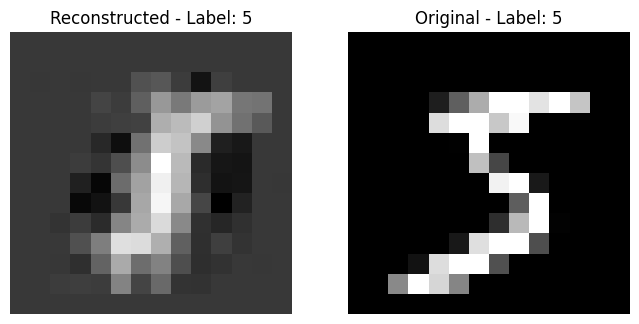

Applying profile...   success
Sweep complete.
mu tensor([[1.1258, 0.8975, 1.7373]], grad_fn=<AddmmBackward0>) and std tensor([[1.7043, 0.6827, 0.7901]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.333001732826233 and KLD 0.446758896112442 xshape 14


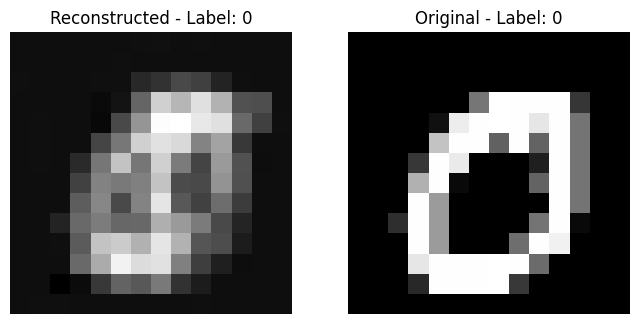

Applying profile...   success
Sweep complete.
mu tensor([[0.3134, 0.6982, 0.5141]], grad_fn=<AddmmBackward0>) and std tensor([[1.6099, 0.5918, 1.7563]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6576802134513855 and KLD 0.20335105061531067 xshape 14


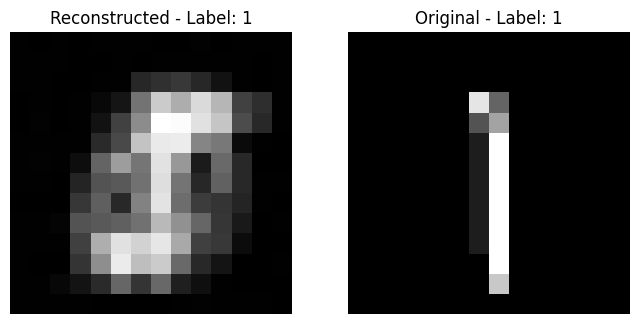

Applying profile...   success
Sweep complete.
mu tensor([[-0.3961,  0.7278,  1.2099]], grad_fn=<AddmmBackward0>) and std tensor([[1.0448, 0.7586, 0.7561]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7715662121772766 and KLD 0.1723753660917282 xshape 14


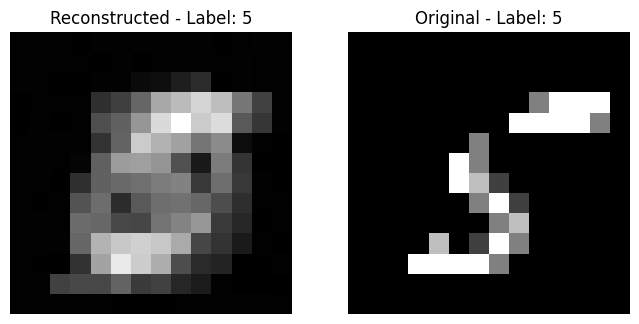

Applying profile...   success
Sweep complete.
mu tensor([[-1.0401, -0.2528, -0.3053]], grad_fn=<AddmmBackward0>) and std tensor([[2.2913, 1.0601, 1.0085]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6493093371391296 and KLD 0.27414360642433167 xshape 14


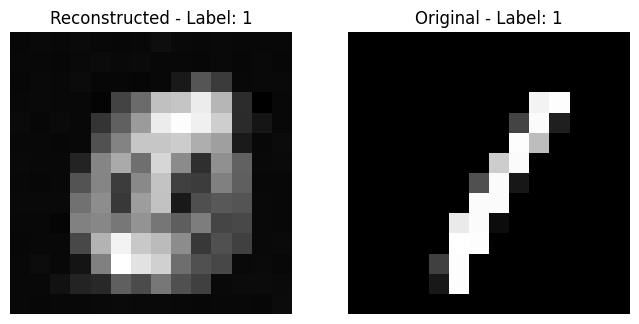

Applying profile...   success
Sweep complete.
mu tensor([[ 0.2080,  0.4103, -0.1699]], grad_fn=<AddmmBackward0>) and std tensor([[1.0030, 0.7106, 1.6813]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5235500931739807 and KLD 0.08688292652368546 xshape 14


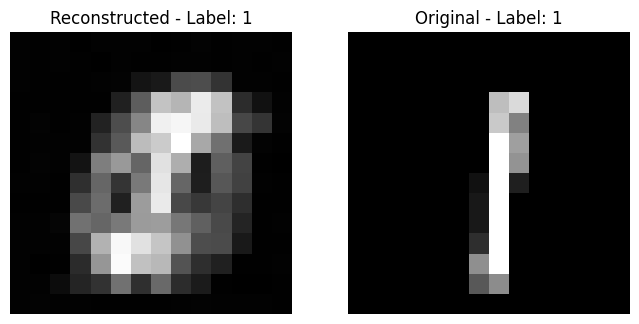

Applying profile...   success
Sweep complete.
mu tensor([[-0.4099,  0.0869, -0.1885]], grad_fn=<AddmmBackward0>) and std tensor([[2.0667, 0.7933, 1.1340]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.0121012926101685 and KLD 0.15409670770168304 xshape 14


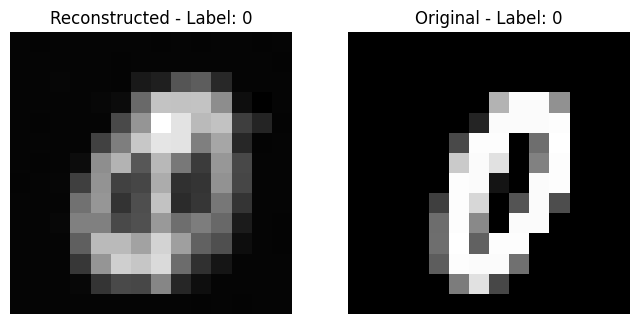

Applying profile...   success
Sweep complete.
mu tensor([[-0.3599,  0.7694, -0.0184]], grad_fn=<AddmmBackward0>) and std tensor([[0.8746, 0.5957, 1.0039]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6363515257835388 and KLD 0.08184397965669632 xshape 14


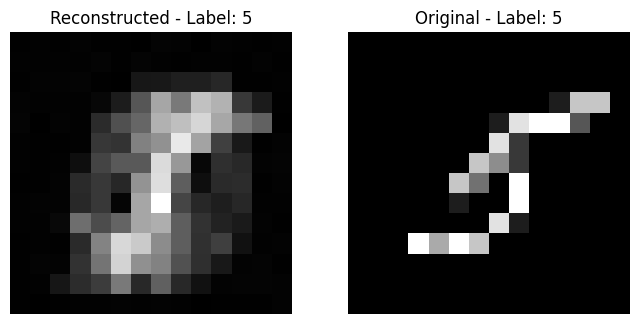

Applying profile...   success
Sweep complete.
mu tensor([[-0.3790, -0.0500, -0.0183]], grad_fn=<AddmmBackward0>) and std tensor([[1.8113, 1.1087, 0.8774]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6188893914222717 and KLD 0.0923796072602272 xshape 14


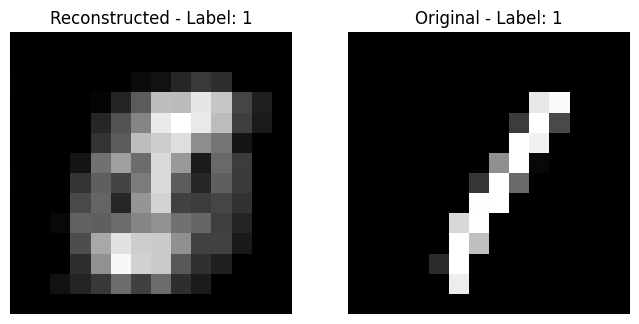

Applying profile...   success
Sweep complete.
mu tensor([[0.2492, 1.1724, 0.2502]], grad_fn=<AddmmBackward0>) and std tensor([[1.8913, 0.5051, 1.6167]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.564726710319519 and KLD 0.29114317893981934 xshape 14


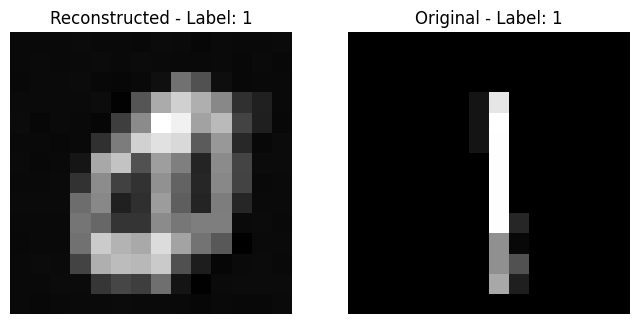

Applying profile...   success
Sweep complete.
mu tensor([[0.8408, 0.4817, 1.1901]], grad_fn=<AddmmBackward0>) and std tensor([[1.1003, 0.9447, 0.9737]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6410103440284729 and KLD 0.17016899585723877 xshape 14


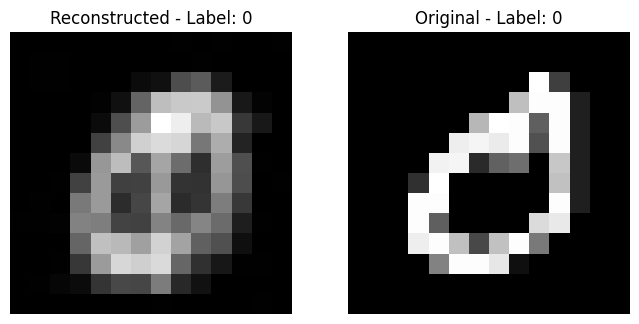

Applying profile...   success
Sweep complete.
mu tensor([[-0.5852,  0.7539,  0.2228]], grad_fn=<AddmmBackward0>) and std tensor([[1.5487, 0.8319, 0.7456]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5549899935722351 and KLD 0.12052084505558014 xshape 14


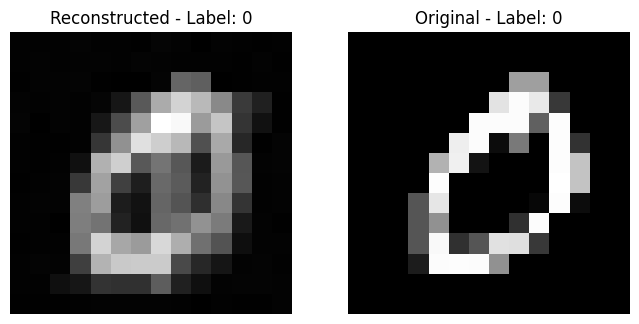

Applying profile...   success
Sweep complete.
mu tensor([[-0.9778, -0.2219, -0.6182]], grad_fn=<AddmmBackward0>) and std tensor([[2.3063, 0.9466, 1.2005]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5972113013267517 and KLD 0.29406723380088806 xshape 14


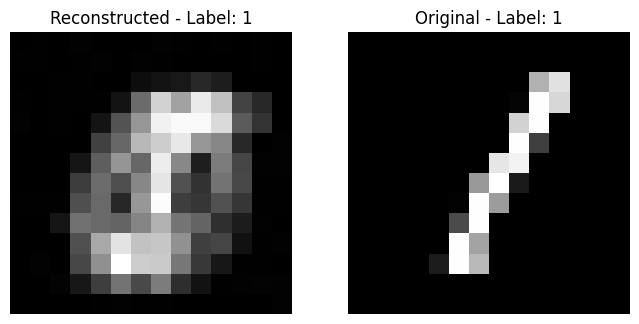

Applying profile...   success
Sweep complete.
mu tensor([[-0.3466,  0.1074,  0.8643]], grad_fn=<AddmmBackward0>) and std tensor([[2.0057, 0.7103, 1.0019]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1972721815109253 and KLD 0.1927228420972824 xshape 14


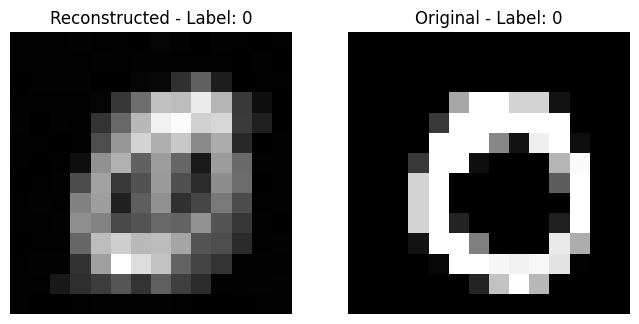

Applying profile...   success
Sweep complete.
mu tensor([[0.3929, 0.2709, 1.1957]], grad_fn=<AddmmBackward0>) and std tensor([[1.0176, 1.0102, 0.7310]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9215549230575562 and KLD 0.12995776534080505 xshape 14


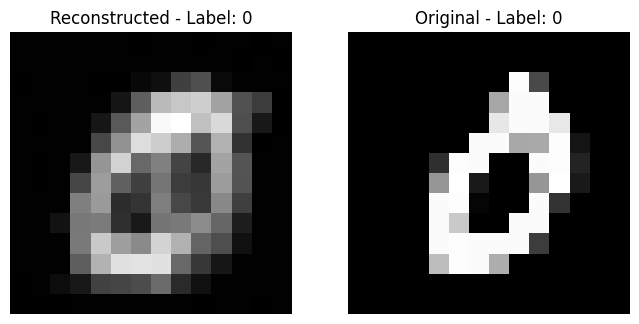

Applying profile...   success
Sweep complete.
mu tensor([[-0.4062,  0.8212,  0.8333]], grad_fn=<AddmmBackward0>) and std tensor([[2.1282, 0.6950, 0.9851]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6590599417686462 and KLD 0.26883652806282043 xshape 14


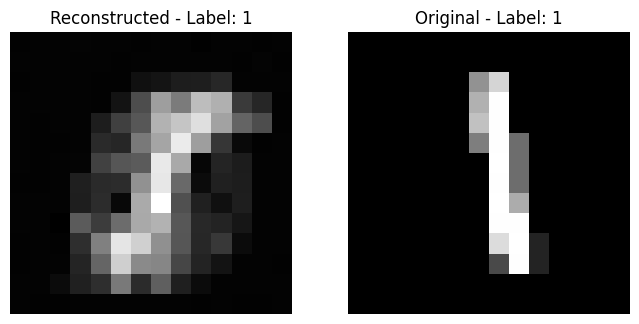

Epoch 11/15, Loss: 0.9914
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[-0.3447,  0.1010,  0.8597]], grad_fn=<AddmmBackward0>) and std tensor([[2.0195, 0.7219, 0.9980]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1223771572113037 and KLD 0.19382977485656738 xshape 14


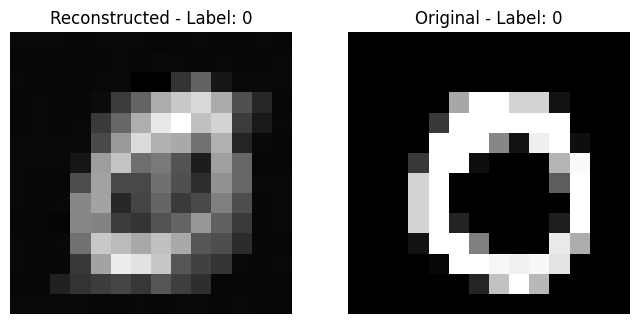

Applying profile...   success
Sweep complete.
mu tensor([[-0.2618,  0.9253,  1.0287]], grad_fn=<AddmmBackward0>) and std tensor([[0.9535, 0.7474, 0.7358]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6929229497909546 and KLD 0.16309581696987152 xshape 14


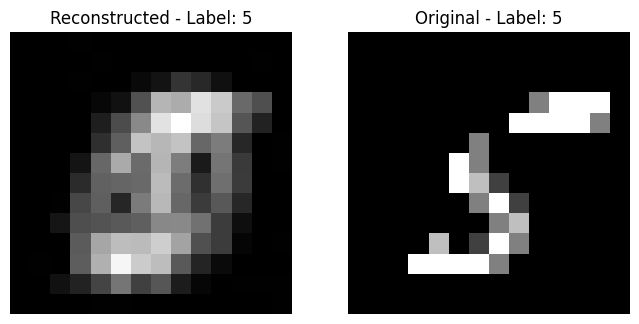

Applying profile...   success
Sweep complete.
mu tensor([[-0.4495,  0.1298, -0.2116]], grad_fn=<AddmmBackward0>) and std tensor([[2.1919, 0.7823, 1.1325]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8653227686882019 and KLD 0.1882331371307373 xshape 14


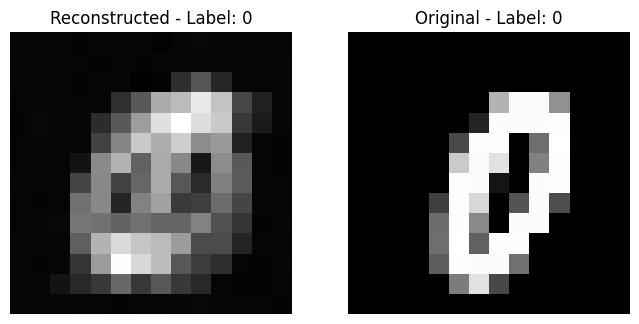

Applying profile...   success
Sweep complete.
mu tensor([[0.8046, 0.4906, 1.1308]], grad_fn=<AddmmBackward0>) and std tensor([[1.1736, 0.9294, 1.0073]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8474154472351074 and KLD 0.15959179401397705 xshape 14


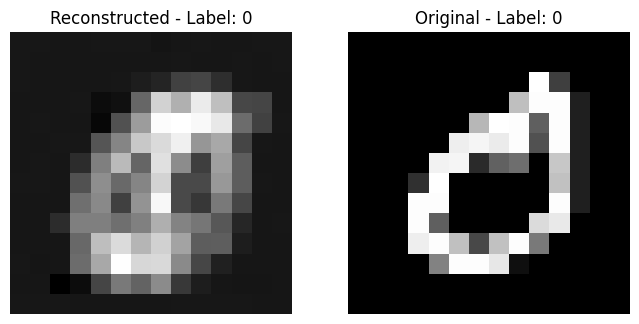

Applying profile...   success
Sweep complete.
mu tensor([[-0.0931,  0.0580, -0.0412]], grad_fn=<AddmmBackward0>) and std tensor([[1.6221, 1.1411, 0.8815]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5450437664985657 and KLD 0.05320034176111221 xshape 14


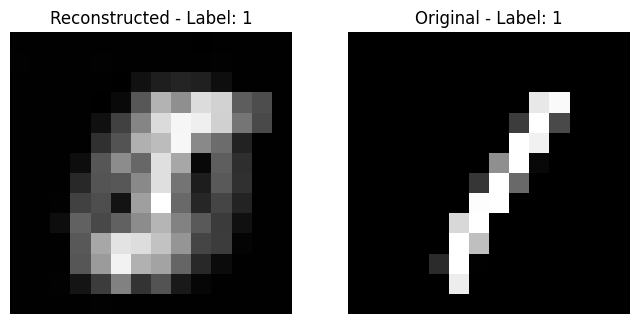

Applying profile...   success
Sweep complete.
mu tensor([[-0.9308, -0.1908, -0.6422]], grad_fn=<AddmmBackward0>) and std tensor([[2.2378, 0.9886, 1.1376]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5190019011497498 and KLD 0.26775285601615906 xshape 14


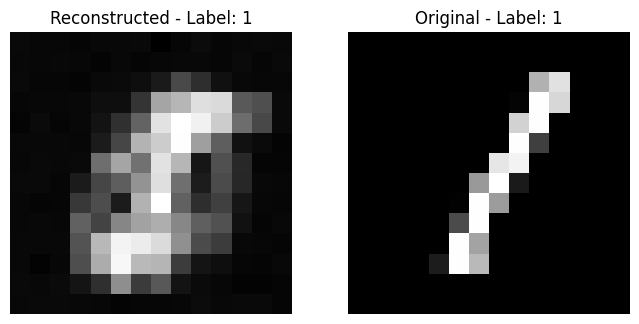

Applying profile...   success
Sweep complete.
mu tensor([[0.4490, 1.3456, 1.1382]], grad_fn=<AddmmBackward0>) and std tensor([[1.4357, 0.5457, 1.1084]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8982534408569336 and KLD 0.2983963191509247 xshape 14


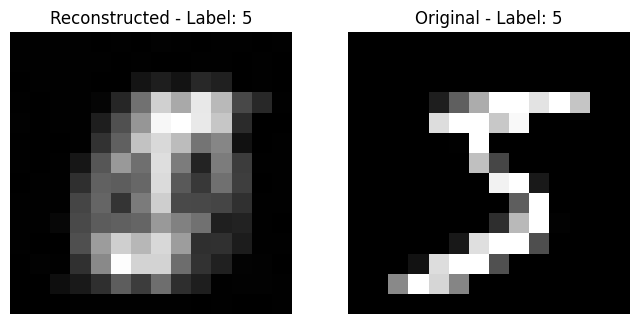

Applying profile...   success
Sweep complete.
mu tensor([[0.3577, 1.2688, 0.5520]], grad_fn=<AddmmBackward0>) and std tensor([[2.0639, 0.5435, 1.4490]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8758468627929688 and KLD 0.3375548720359802 xshape 14


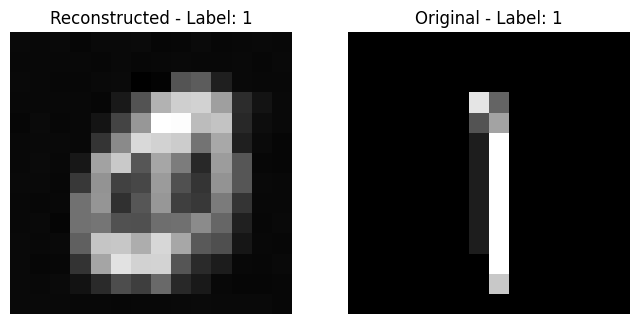

Applying profile...   success
Sweep complete.
mu tensor([[0.5506, 0.2514, 1.2656]], grad_fn=<AddmmBackward0>) and std tensor([[0.9641, 1.0714, 0.7290]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1808651685714722 and KLD 0.1531742513179779 xshape 14


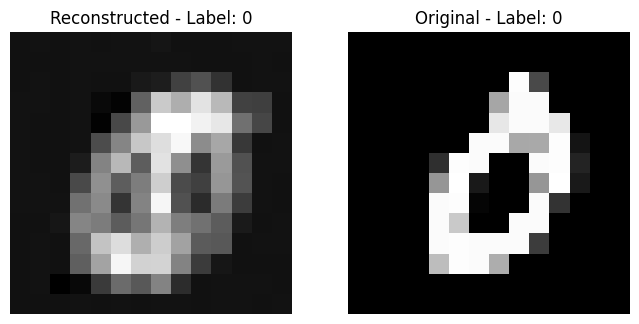

Applying profile...   success
Sweep complete.
mu tensor([[1.0215, 1.1323, 0.9039]], grad_fn=<AddmmBackward0>) and std tensor([[1.5798, 0.8767, 0.8462]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1548497676849365 and KLD 0.27181902527809143 xshape 14


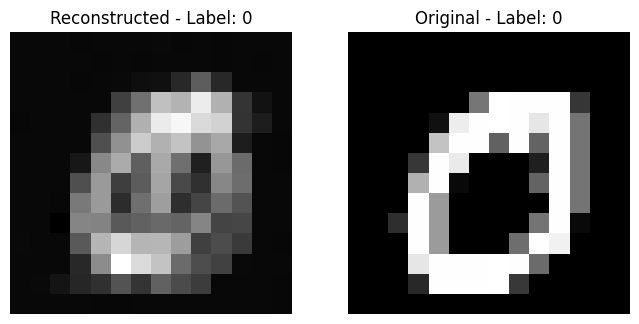

Applying profile...   success
Sweep complete.
mu tensor([[0.4406, 1.2593, 0.4588]], grad_fn=<AddmmBackward0>) and std tensor([[2.0125, 0.5259, 1.4523]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4608522057533264 and KLD 0.32619354128837585 xshape 14


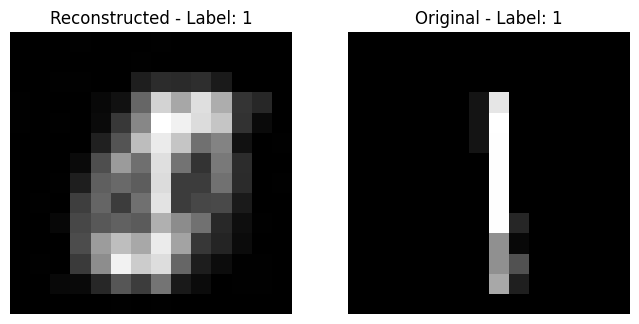

Applying profile...   success
Sweep complete.
mu tensor([[-0.3532,  0.7077,  0.9297]], grad_fn=<AddmmBackward0>) and std tensor([[2.1730, 0.7134, 0.9686]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6495459675788879 and KLD 0.27471694350242615 xshape 14


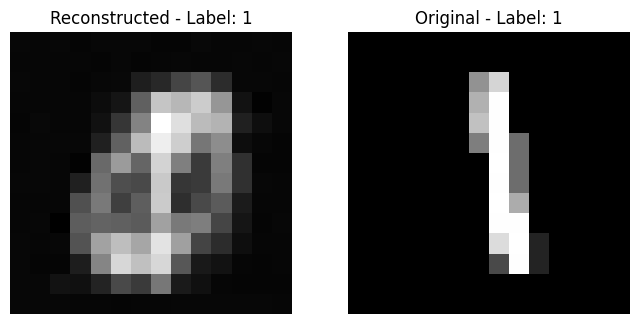

Applying profile...   success
Sweep complete.
mu tensor([[0.3474, 1.5358, 1.1409]], grad_fn=<AddmmBackward0>) and std tensor([[0.6801, 0.6214, 0.7604]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.687791645526886 and KLD 0.31987693905830383 xshape 14


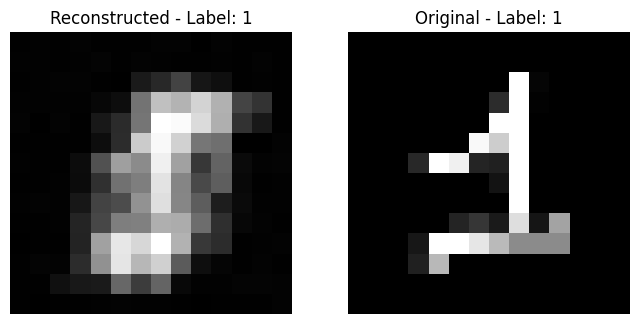

Applying profile...   success
Sweep complete.
mu tensor([[-0.2233, -0.0469, -0.2129]], grad_fn=<AddmmBackward0>) and std tensor([[1.7680, 1.2095, 0.8878]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5050598382949829 and KLD 0.08515352755784988 xshape 14


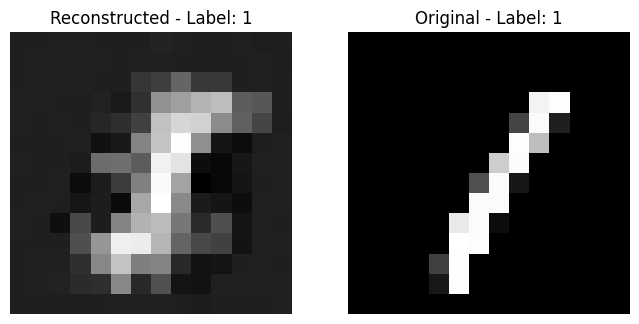

Applying profile...   success
Sweep complete.
mu tensor([[ 0.2087,  0.6384, -0.2419]], grad_fn=<AddmmBackward0>) and std tensor([[1.4271, 0.6716, 1.4690]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.40923282504081726 and KLD 0.10507368296384811 xshape 14


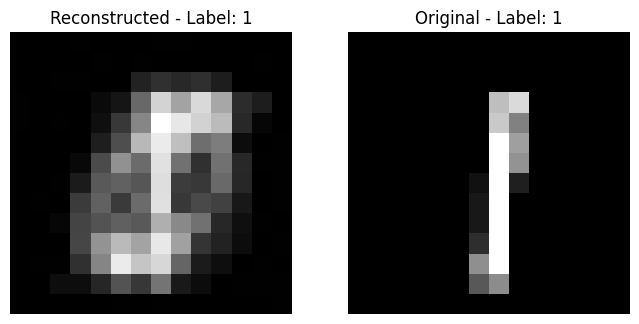

Applying profile...   success
Sweep complete.
mu tensor([[-0.4493,  1.0021, -0.2965]], grad_fn=<AddmmBackward0>) and std tensor([[1.2142, 0.9456, 0.8483]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.694850504398346 and KLD 0.10248260945081711 xshape 14


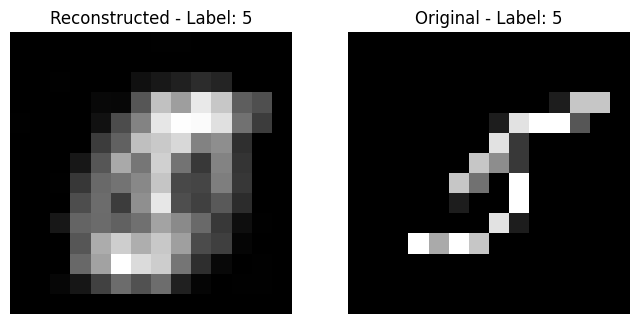

Applying profile...   success
Sweep complete.
mu tensor([[0.3679, 0.8125, 1.3100]], grad_fn=<AddmmBackward0>) and std tensor([[1.1655, 0.5870, 0.8435]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8646122813224792 and KLD 0.21611319482326508 xshape 14


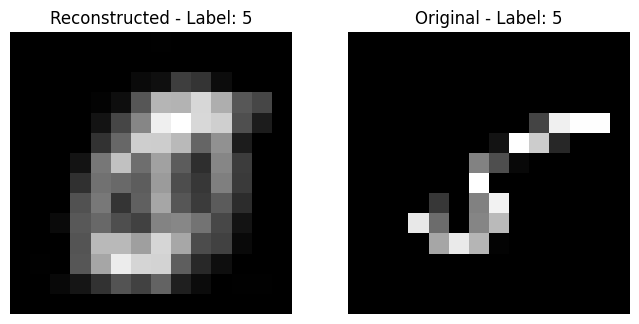

Applying profile...   success
Sweep complete.
mu tensor([[0.7394, 0.1936, 1.8454]], grad_fn=<AddmmBackward0>) and std tensor([[1.6201, 0.7520, 0.9890]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6914685964584351 and KLD 0.34179916977882385 xshape 14


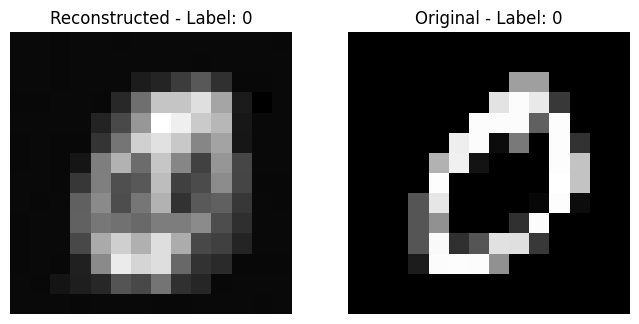

Epoch 12/15, Loss: 1.0164
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[-0.2945,  0.2028,  0.0116]], grad_fn=<AddmmBackward0>) and std tensor([[2.2431, 0.7837, 1.0889]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9437986612319946 and KLD 0.19007083773612976 xshape 14


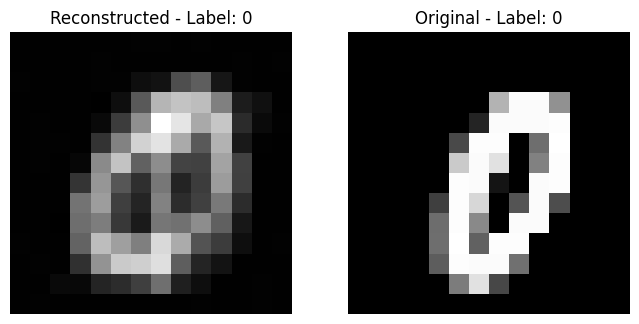

Applying profile...   success
Sweep complete.
mu tensor([[-0.0676,  0.0350, -0.2453]], grad_fn=<AddmmBackward0>) and std tensor([[1.7361, 1.1944, 0.8916]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6029982566833496 and KLD 0.07660181075334549 xshape 14


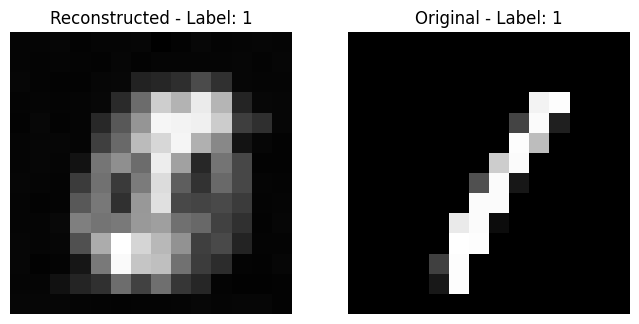

Applying profile...   success
Sweep complete.
mu tensor([[0.3847, 1.1262, 0.5709]], grad_fn=<AddmmBackward0>) and std tensor([[2.1090, 0.5761, 1.4584]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5340405106544495 and KLD 0.32178452610969543 xshape 14


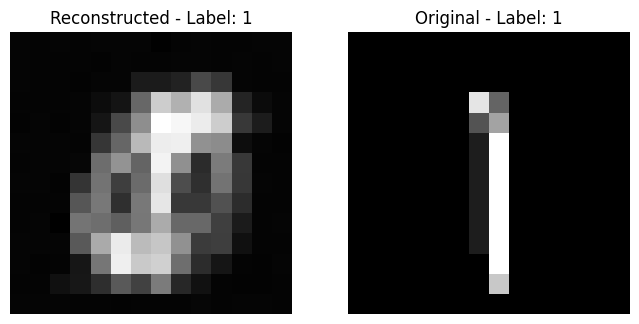

Applying profile...   success
Sweep complete.
mu tensor([[1.0184e+00, 6.1786e-04, 2.0064e+00]], grad_fn=<AddmmBackward0>) and std tensor([[1.2163, 0.8111, 1.1625]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7974417805671692 and KLD 0.3769746720790863 xshape 14


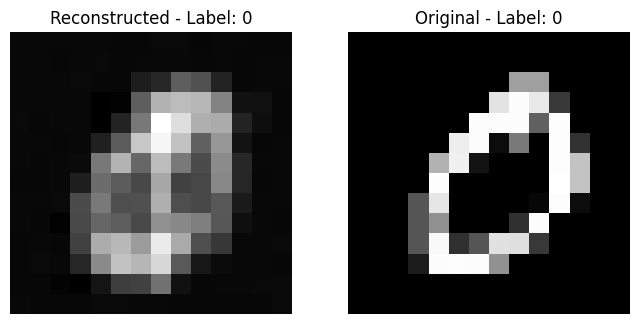

Applying profile...   success
Sweep complete.
mu tensor([[0.3912, 0.9203, 1.3194]], grad_fn=<AddmmBackward0>) and std tensor([[1.1640, 0.5872, 0.8277]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5982267260551453 and KLD 0.23319850862026215 xshape 14


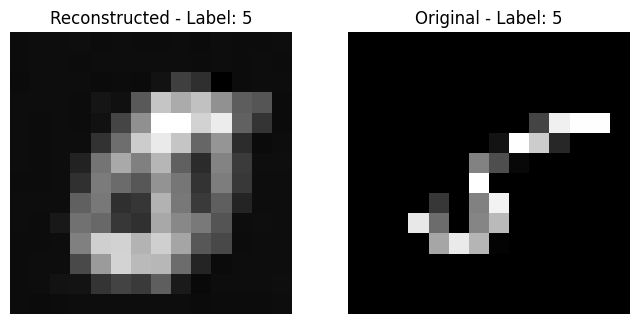

Applying profile...   success
Sweep complete.
mu tensor([[-0.2624,  0.6570,  1.0152]], grad_fn=<AddmmBackward0>) and std tensor([[2.1972, 0.7263, 0.9436]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5638216137886047 and KLD 0.2827127277851105 xshape 14


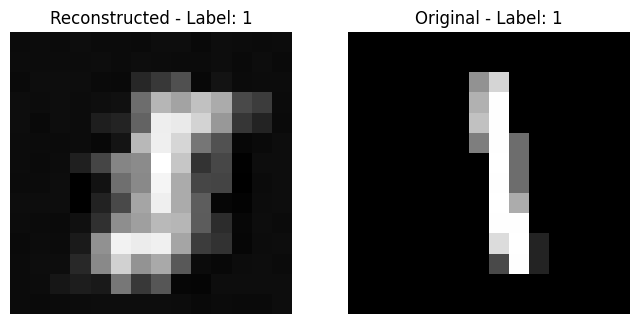

Applying profile...   success
Sweep complete.
mu tensor([[-0.3581,  0.7329,  1.1230]], grad_fn=<AddmmBackward0>) and std tensor([[1.0530, 0.8201, 0.6912]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.712889552116394 and KLD 0.15840685367584229 xshape 14


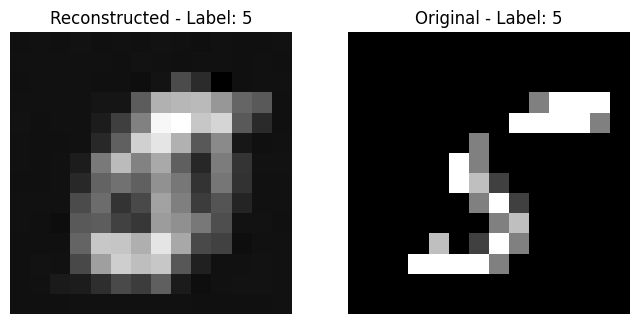

Applying profile...   success
Sweep complete.
mu tensor([[0.3752, 0.5517, 0.1655]], grad_fn=<AddmmBackward0>) and std tensor([[1.5676, 1.0007, 0.8363]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5467121005058289 and KLD 0.07769930362701416 xshape 14


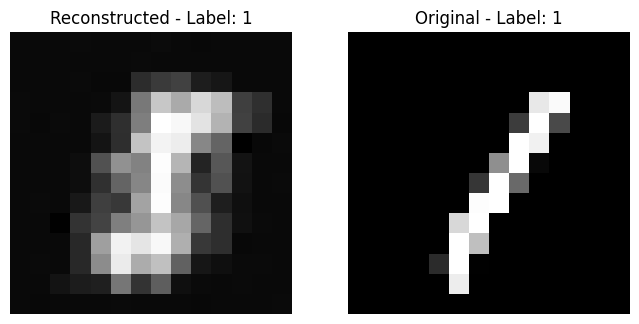

Applying profile...   success
Sweep complete.
mu tensor([[0.9124, 0.5280, 1.3475]], grad_fn=<AddmmBackward0>) and std tensor([[0.8629, 1.1332, 0.7728]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.0404671430587769 and KLD 0.2223816066980362 xshape 14


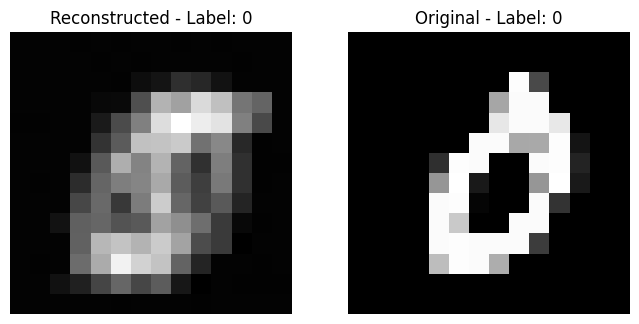

Applying profile...   success
Sweep complete.
mu tensor([[0.5035, 1.2823, 1.1537]], grad_fn=<AddmmBackward0>) and std tensor([[1.6843, 0.8472, 0.8934]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.1541463136672974 and KLD 0.2925596833229065 xshape 14


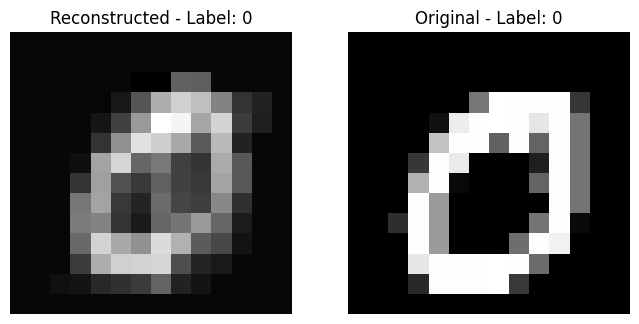

Applying profile...   success
Sweep complete.
mu tensor([[0.4796, 1.2425, 0.5219]], grad_fn=<AddmmBackward0>) and std tensor([[2.0688, 0.5638, 1.4127]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.45576366782188416 and KLD 0.3314738869667053 xshape 14


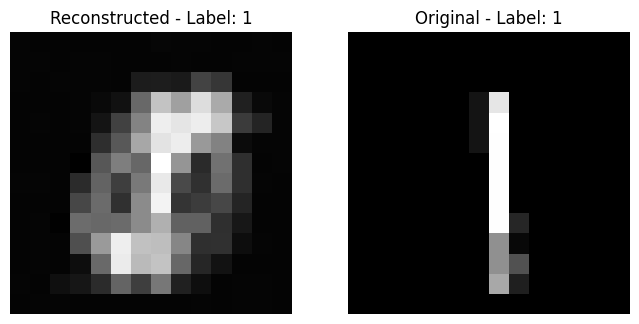

Applying profile...   success
Sweep complete.
mu tensor([[0.2690, 0.4620, 0.0052]], grad_fn=<AddmmBackward0>) and std tensor([[1.3370, 0.7608, 1.4279]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5425494909286499 and KLD 0.06747018545866013 xshape 14


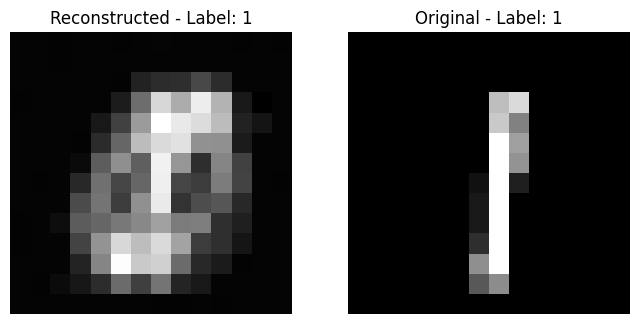

Applying profile...   success
Sweep complete.
mu tensor([[-0.2305,  0.4328, -0.2038]], grad_fn=<AddmmBackward0>) and std tensor([[1.9719, 0.7881, 1.0116]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8182363510131836 and KLD 0.13642571866512299 xshape 14


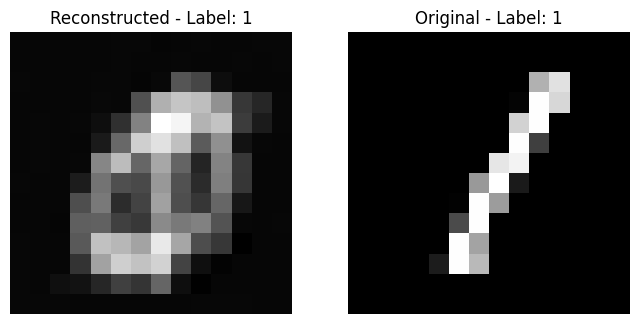

Applying profile...   success
Sweep complete.
mu tensor([[0.2344, 0.9623, 1.1445]], grad_fn=<AddmmBackward0>) and std tensor([[1.0309, 0.7919, 1.1271]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6163488030433655 and KLD 0.17269267141819 xshape 14


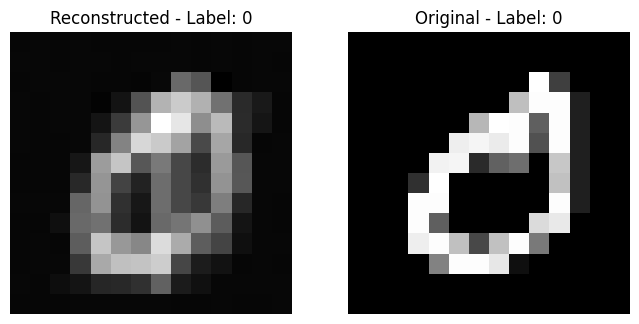

Applying profile...   success
Sweep complete.
mu tensor([[-0.2671,  0.1348,  1.0442]], grad_fn=<AddmmBackward0>) and std tensor([[2.0959, 0.6631, 0.9731]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.5183988809585571 and KLD 0.2396794706583023 xshape 14


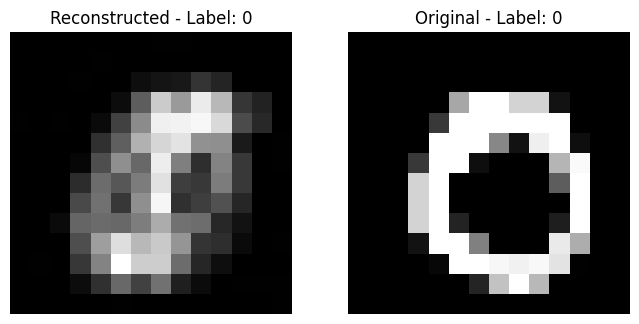

Applying profile...   success
Sweep complete.
mu tensor([[0.1344, 1.6650, 0.1320]], grad_fn=<AddmmBackward0>) and std tensor([[1.5244, 0.9267, 0.7983]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6440531611442566 and KLD 0.2419394999742508 xshape 14


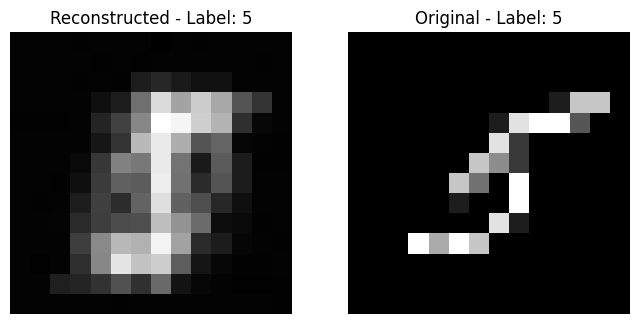

Applying profile...   success
Sweep complete.
mu tensor([[-0.1825,  0.2846,  1.3237]], grad_fn=<AddmmBackward0>) and std tensor([[1.4134, 0.5983, 1.1127]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8530173301696777 and KLD 0.1844300925731659 xshape 14


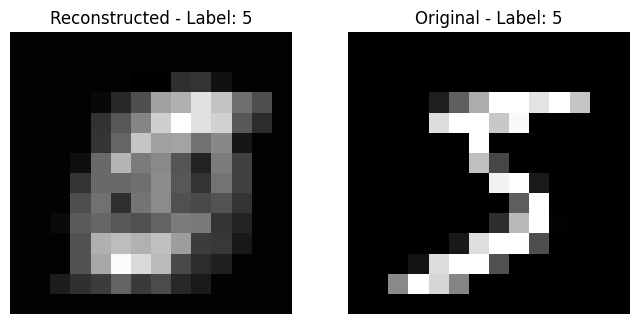

Applying profile...   success
Sweep complete.
mu tensor([[0.3628, 1.3671, 1.1420]], grad_fn=<AddmmBackward0>) and std tensor([[0.6518, 0.5607, 0.8626]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9497153162956238 and KLD 0.2926369309425354 xshape 14


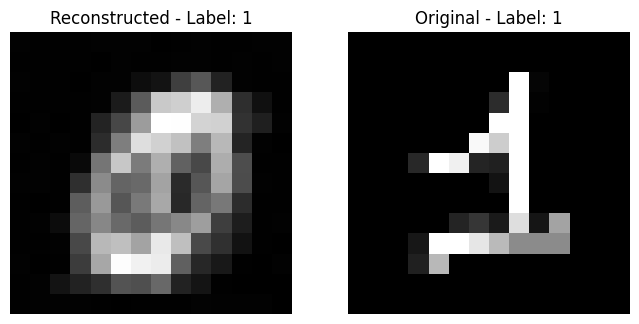

Epoch 13/15, Loss: 1.0318
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[0.3480, 1.3838, 1.1286]], grad_fn=<AddmmBackward0>) and std tensor([[0.6501, 0.5525, 0.8753]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6343442797660828 and KLD 0.2941462993621826 xshape 14


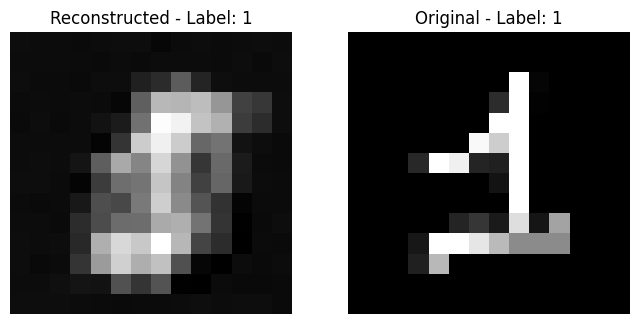

Applying profile...   success
Sweep complete.
mu tensor([[-0.2613,  0.0597,  1.0491]], grad_fn=<AddmmBackward0>) and std tensor([[1.4972, 0.7279, 1.0877]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8836243748664856 and KLD 0.1276426762342453 xshape 14


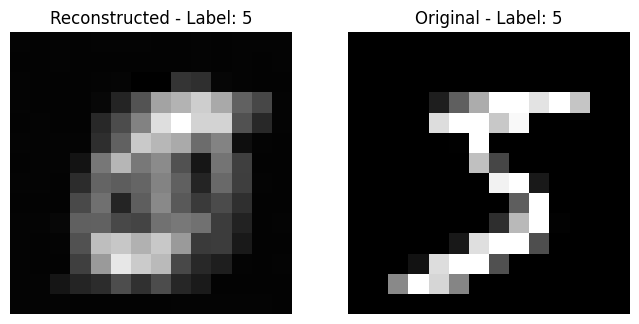

Applying profile...   success
Sweep complete.
mu tensor([[0.1121, 0.9234, 0.2976]], grad_fn=<AddmmBackward0>) and std tensor([[1.2332, 0.9456, 1.0176]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6293513178825378 and KLD 0.07585600763559341 xshape 14


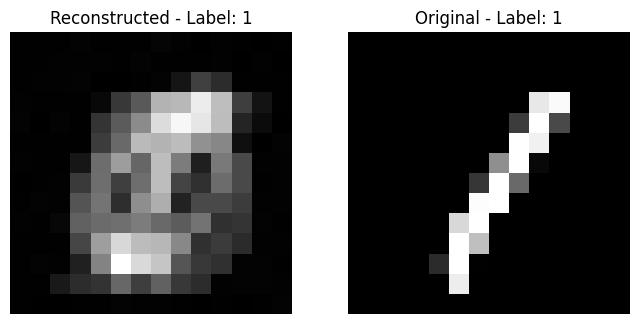

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0029,  0.4628, -0.4476]], grad_fn=<AddmmBackward0>) and std tensor([[1.8361, 0.8643, 1.1338]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.4109337329864502 and KLD 0.11739548295736313 xshape 14


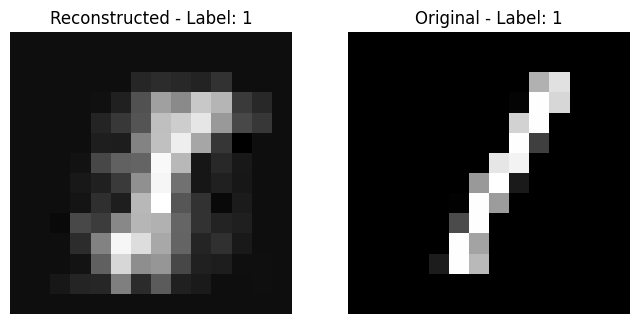

Applying profile...   success
Sweep complete.
mu tensor([[0.6606, 1.1000, 1.3323]], grad_fn=<AddmmBackward0>) and std tensor([[1.2042, 0.6451, 0.7256]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.7301915287971497 and KLD 0.28289708495140076 xshape 14


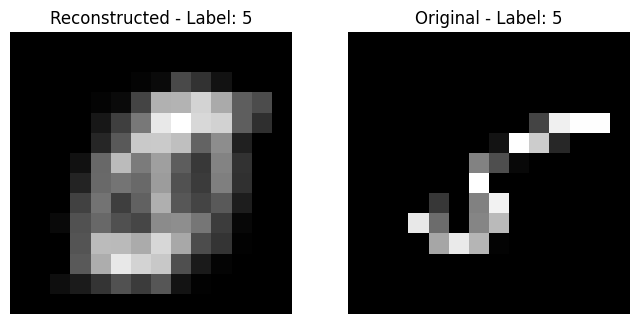

Applying profile...   success
Sweep complete.
mu tensor([[-0.2667,  0.1979,  1.0276]], grad_fn=<AddmmBackward0>) and std tensor([[2.0260, 0.6513, 0.9510]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.4825209379196167 and KLD 0.22468365728855133 xshape 14


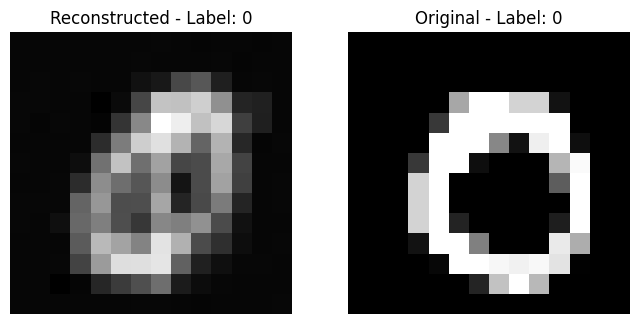

Applying profile...   success
Sweep complete.
mu tensor([[0.2510, 1.8619, 0.8852]], grad_fn=<AddmmBackward0>) and std tensor([[2.1366, 0.5190, 1.1829]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8110675811767578 and KLD 0.5002864003181458 xshape 14


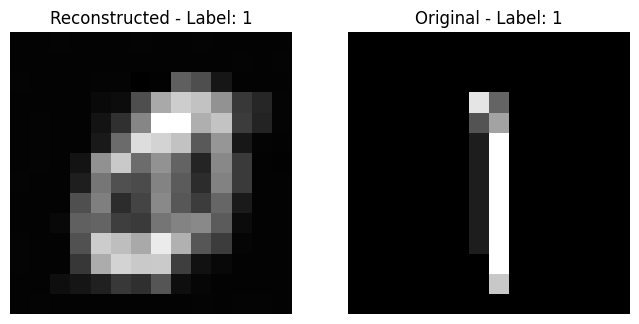

Applying profile...   success
Sweep complete.
mu tensor([[ 0.0794,  0.9270, -0.2932]], grad_fn=<AddmmBackward0>) and std tensor([[1.9592, 0.6660, 1.4795]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.514238178730011 and KLD 0.22192057967185974 xshape 14


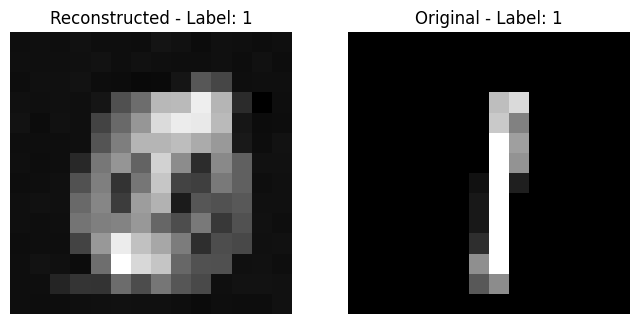

Applying profile...   success
Sweep complete.
mu tensor([[-0.1913,  0.4514, -0.0631]], grad_fn=<AddmmBackward0>) and std tensor([[2.4614, 0.7319, 1.1525]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8648070096969604 and KLD 0.2646879255771637 xshape 14


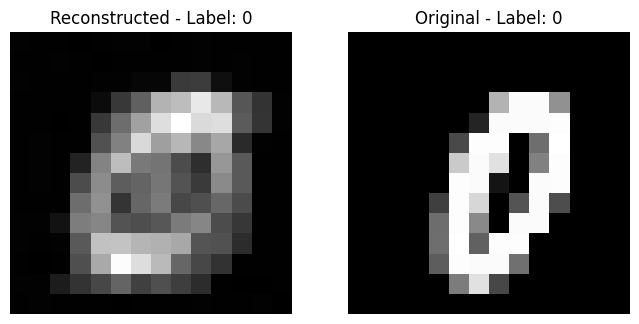

Applying profile...   success
Sweep complete.
mu tensor([[0.6904, 1.3745, 1.3012]], grad_fn=<AddmmBackward0>) and std tensor([[1.4303, 0.7629, 1.0119]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.095866322517395 and KLD 0.3223462998867035 xshape 14


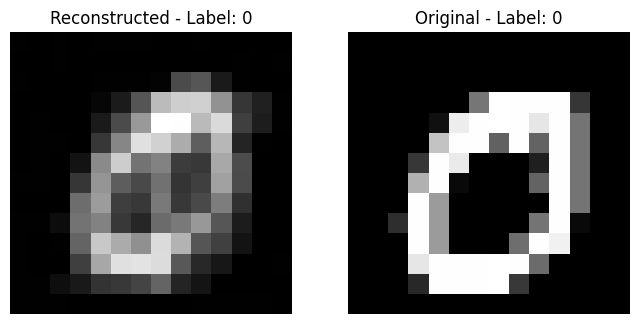

Applying profile...   success
Sweep complete.
mu tensor([[-0.3571,  0.5380,  0.7313]], grad_fn=<AddmmBackward0>) and std tensor([[1.2284, 1.0913, 0.6766]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6925997138023376 and KLD 0.09318719059228897 xshape 14


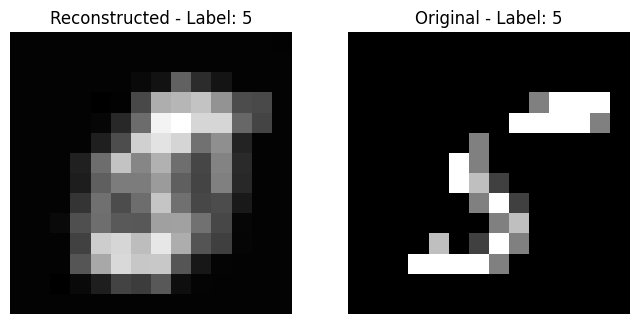

Applying profile...   success
Sweep complete.
mu tensor([[0.2851, 1.9210, 0.7635]], grad_fn=<AddmmBackward0>) and std tensor([[2.2003, 0.5240, 1.2097]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9199479818344116 and KLD 0.5191698670387268 xshape 14


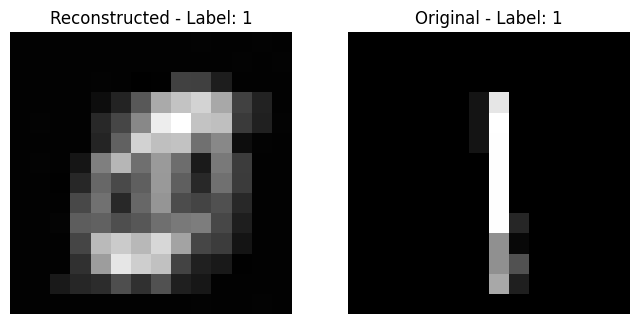

Applying profile...   success
Sweep complete.
mu tensor([[0.5648, 1.6849, 0.8344]], grad_fn=<AddmmBackward0>) and std tensor([[1.4349, 0.8981, 0.7340]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6508861184120178 and KLD 0.31212466955184937 xshape 14


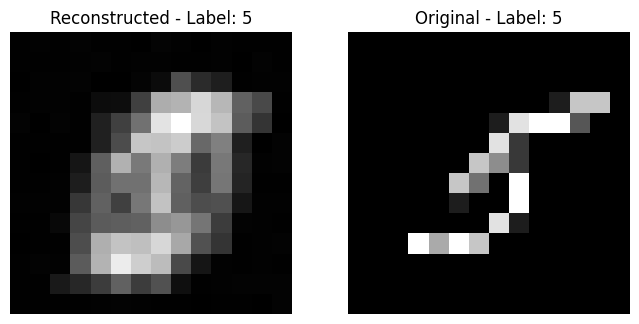

Applying profile...   success
Sweep complete.
mu tensor([[-0.4439,  0.8826,  0.5349]], grad_fn=<AddmmBackward0>) and std tensor([[2.7122, 0.6415, 1.1066]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.556253969669342 and KLD 0.4245600700378418 xshape 14


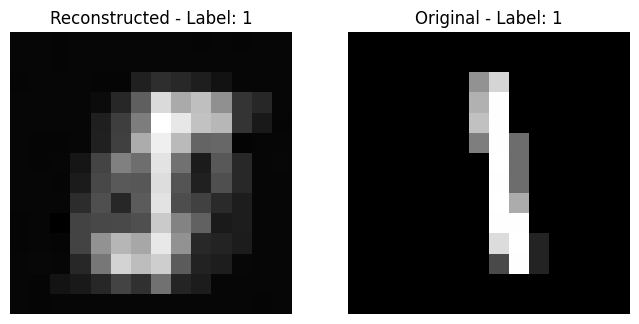

Applying profile...   success
Sweep complete.
mu tensor([[0.3676, 1.0076, 1.0008]], grad_fn=<AddmmBackward0>) and std tensor([[1.0665, 0.6609, 1.2662]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8569024801254272 and KLD 0.18264298141002655 xshape 14


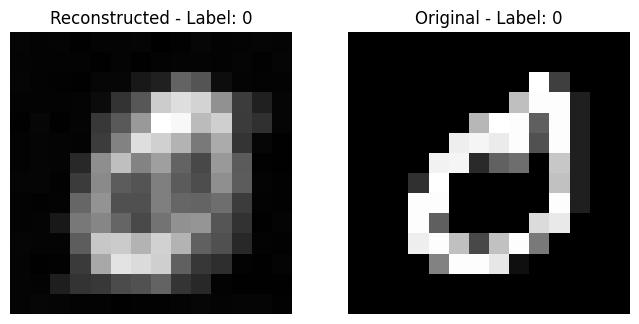

Applying profile...   success
Sweep complete.
mu tensor([[-0.4848,  0.7509, -0.0922]], grad_fn=<AddmmBackward0>) and std tensor([[1.4880, 0.8831, 1.1098]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.48691192269325256 and KLD 0.09131000190973282 xshape 14


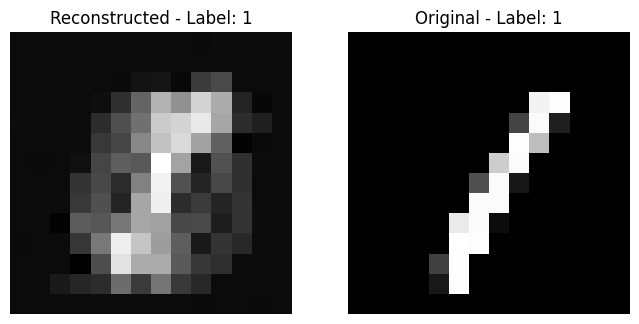

Applying profile...   success
Sweep complete.
mu tensor([[0.7365, 0.9500, 1.0878]], grad_fn=<AddmmBackward0>) and std tensor([[0.9359, 0.9111, 0.7961]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.9046544432640076 and KLD 0.19592034816741943 xshape 14


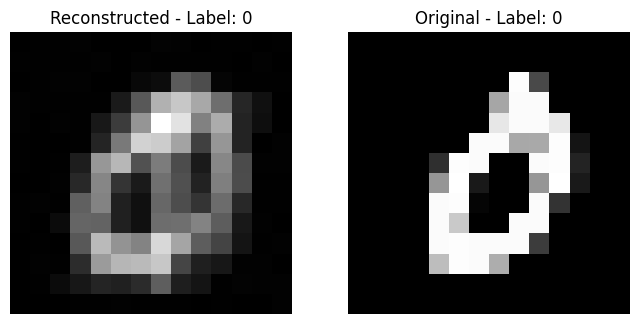

Applying profile...   success
Sweep complete.
mu tensor([[0.9026, 0.3655, 1.7185]], grad_fn=<AddmmBackward0>) and std tensor([[1.1772, 0.6592, 1.4451]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8314536213874817 and KLD 0.3272099196910858 xshape 14


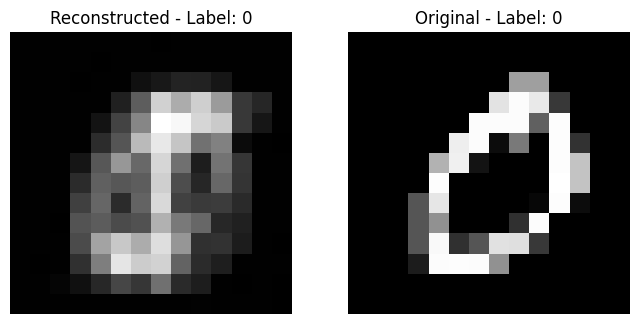

Epoch 14/15, Loss: 1.0806
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
mu tensor([[-0.0893,  1.1142,  0.0744]], grad_fn=<AddmmBackward0>) and std tensor([[1.3005, 0.8274, 1.0497]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8415595293045044 and KLD 0.10636325180530548 xshape 14


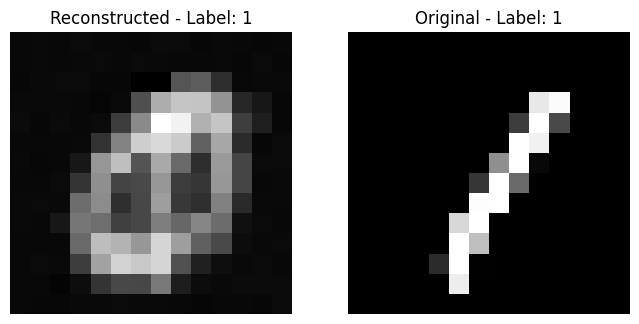

Applying profile...   success
Sweep complete.
mu tensor([[-0.3701,  0.0474, -0.3513]], grad_fn=<AddmmBackward0>) and std tensor([[1.6177, 0.9850, 0.9631]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.943132221698761 and KLD 0.06576290726661682 xshape 14


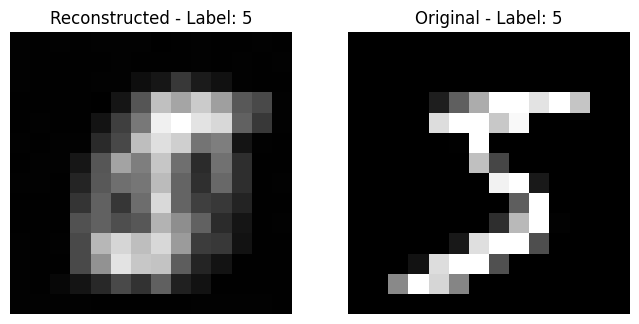

Applying profile...   success
Sweep complete.
mu tensor([[-0.5586,  0.5447, -0.4801]], grad_fn=<AddmmBackward0>) and std tensor([[1.7070, 0.9234, 1.0990]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.45441314578056335 and KLD 0.12246832996606827 xshape 14


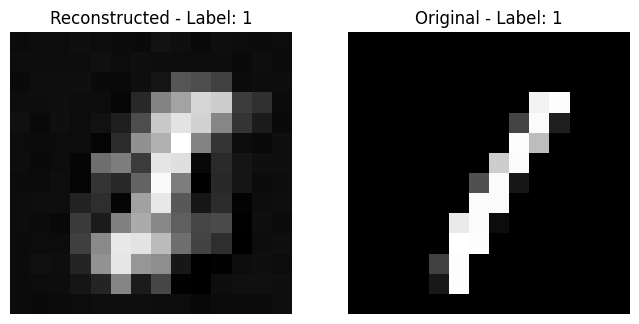

Applying profile...   success
Sweep complete.
mu tensor([[-0.0734,  0.4898, -0.5360]], grad_fn=<AddmmBackward0>) and std tensor([[1.8708, 0.8388, 1.1591]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6334680914878845 and KLD 0.13451479375362396 xshape 14


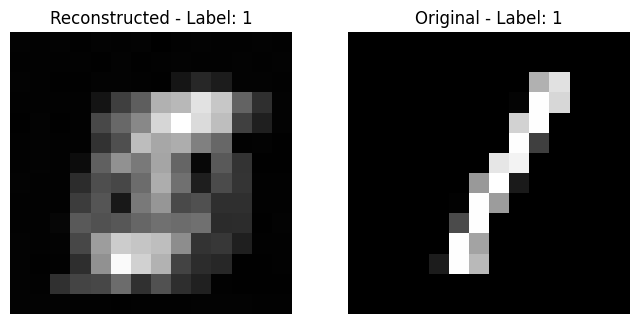

Applying profile...   success
Sweep complete.
mu tensor([[-0.0214,  0.9176, -0.1862]], grad_fn=<AddmmBackward0>) and std tensor([[1.9965, 0.6797, 1.5736]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.43558749556541443 and KLD 0.2345767319202423 xshape 14


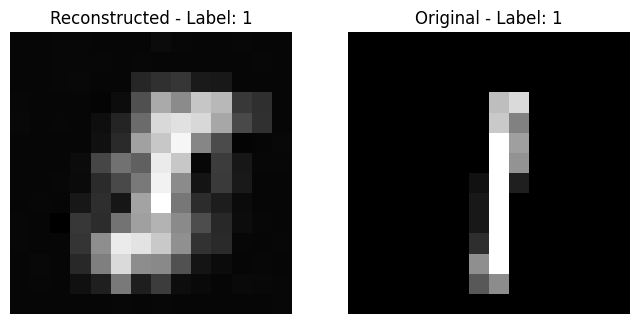

Applying profile...   success
Sweep complete.
mu tensor([[0.8378, 1.3340, 1.0901]], grad_fn=<AddmmBackward0>) and std tensor([[1.3019, 0.8765, 0.9704]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.995839536190033 and KLD 0.27647799253463745 xshape 14


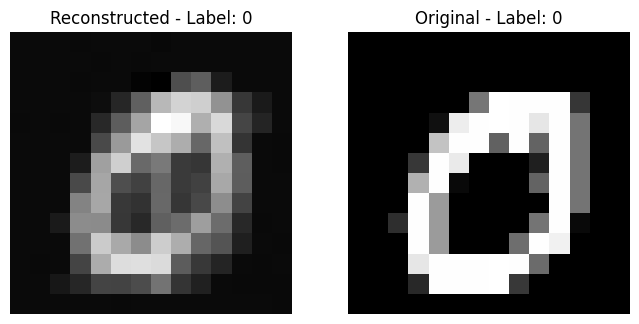

Applying profile...   success
Sweep complete.
mu tensor([[0.7773, 0.3610, 1.6755]], grad_fn=<AddmmBackward0>) and std tensor([[1.0961, 0.6238, 1.5765]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.868163526058197 and KLD 0.31910380721092224 xshape 14


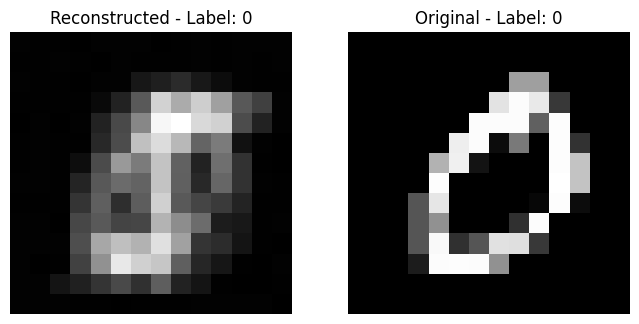

Applying profile...   success
Sweep complete.
mu tensor([[-0.3757,  0.9516,  0.6431]], grad_fn=<AddmmBackward0>) and std tensor([[2.4591, 0.6583, 1.0341]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6926453709602356 and KLD 0.3557048738002777 xshape 14


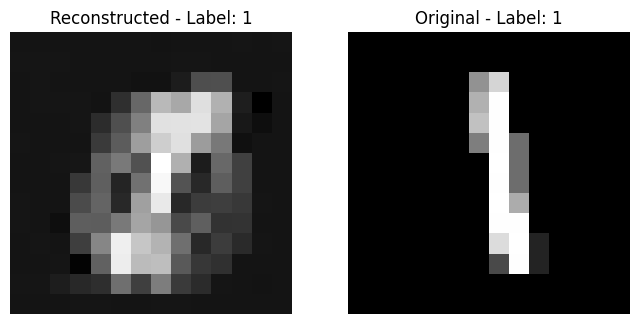

Applying profile...   success
Sweep complete.
mu tensor([[0.3698, 1.7704, 0.7477]], grad_fn=<AddmmBackward0>) and std tensor([[1.1473, 0.8833, 0.6309]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6486133933067322 and KLD 0.30137208104133606 xshape 14


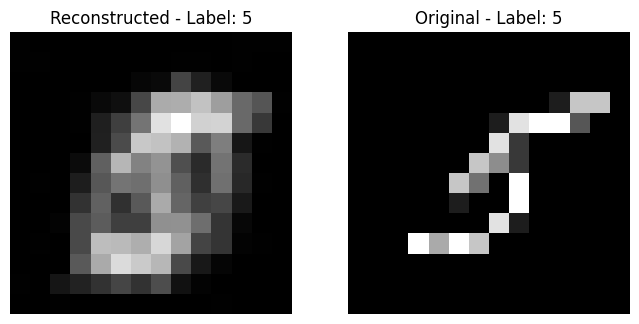

Applying profile...   success
Sweep complete.
mu tensor([[-0.1846,  0.3840, -0.3064]], grad_fn=<AddmmBackward0>) and std tensor([[2.2637, 0.7632, 1.1286]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.950951874256134 and KLD 0.20861028134822845 xshape 14


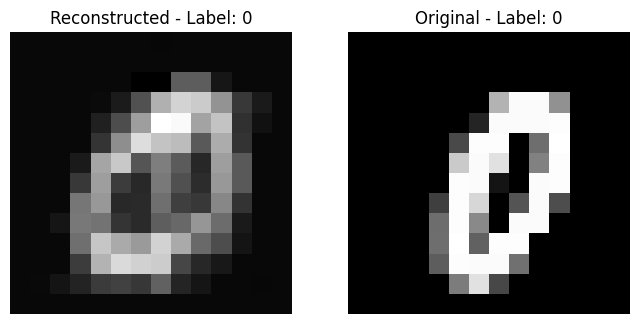

Applying profile...   success
Sweep complete.
mu tensor([[0.3042, 1.4835, 0.8581]], grad_fn=<AddmmBackward0>) and std tensor([[0.6293, 0.5526, 0.9286]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5738709568977356 and KLD 0.27527961134910583 xshape 14


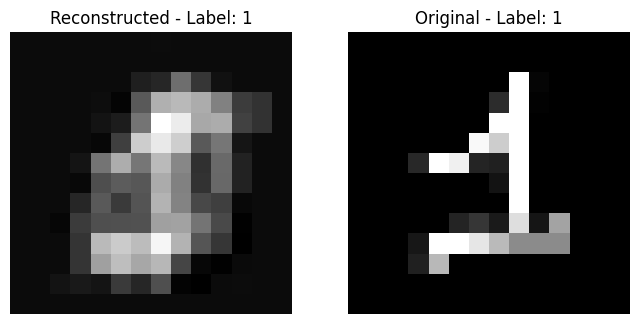

Applying profile...   success
Sweep complete.
mu tensor([[0.1782, 1.9745, 0.6722]], grad_fn=<AddmmBackward0>) and std tensor([[2.0956, 0.5232, 1.2279]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.45120397210121155 and KLD 0.4971812069416046 xshape 14


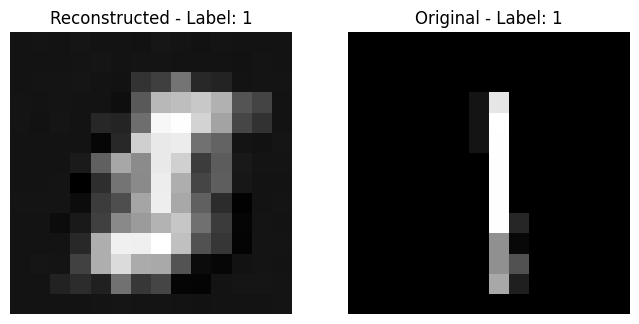

Applying profile...   success
Sweep complete.
mu tensor([[0.7443, 0.9646, 1.0912]], grad_fn=<AddmmBackward0>) and std tensor([[0.9024, 0.8828, 0.7987]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.8367218971252441 and KLD 0.2007833868265152 xshape 14


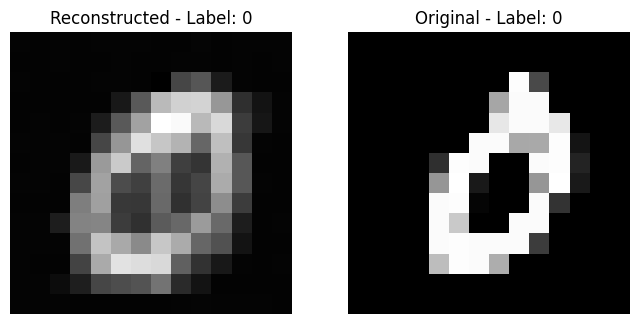

Applying profile...   success
Sweep complete.
mu tensor([[-0.2257,  0.2183,  1.0131]], grad_fn=<AddmmBackward0>) and std tensor([[2.0003, 0.6350, 0.9762]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 1.2245368957519531 and KLD 0.2180085927248001 xshape 14


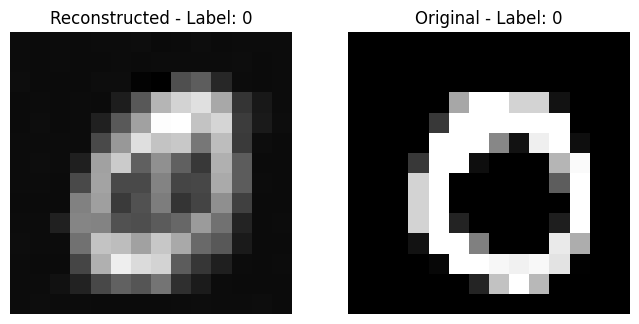

Applying profile...   success
Sweep complete.
mu tensor([[0.1288, 1.9079, 0.7032]], grad_fn=<AddmmBackward0>) and std tensor([[2.0863, 0.5182, 1.2204]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6290891766548157 and KLD 0.47910550236701965 xshape 14


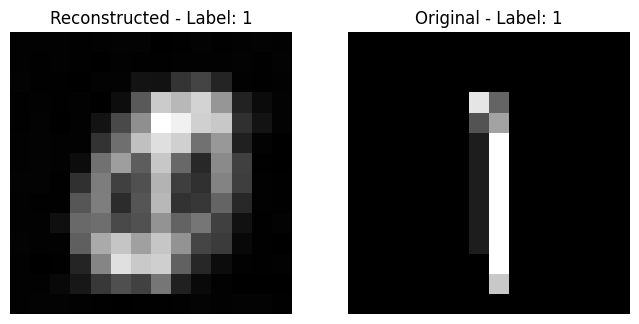

Applying profile...   success
Sweep complete.
mu tensor([[0.6024, 0.9572, 0.9746]], grad_fn=<AddmmBackward0>) and std tensor([[1.1005, 0.6346, 0.9232]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6197036504745483 and KLD 0.1837931126356125 xshape 14


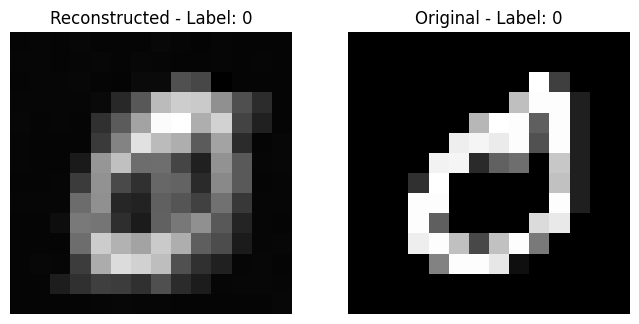

Applying profile...   success
Sweep complete.
mu tensor([[0.5061, 1.2872, 1.0402]], grad_fn=<AddmmBackward0>) and std tensor([[1.1266, 0.6839, 0.6940]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.5306430459022522 and KLD 0.24754676222801208 xshape 14


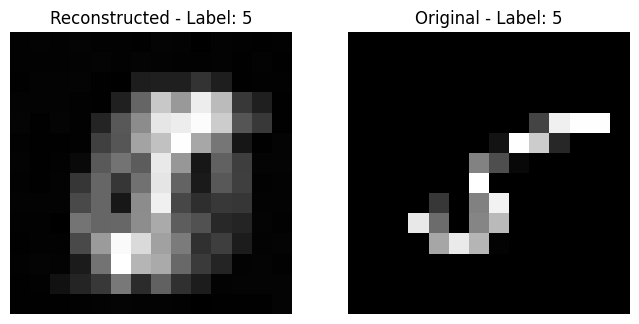

Applying profile...   success
Sweep complete.
mu tensor([[-0.2656,  0.7426,  0.5983]], grad_fn=<AddmmBackward0>) and std tensor([[1.3105, 1.0780, 0.6820]], grad_fn=<ExpBackward0>)
Applying profile...   success
Sweep complete.
MSE 0.6793724894523621 and KLD 0.09993008524179459 xshape 14


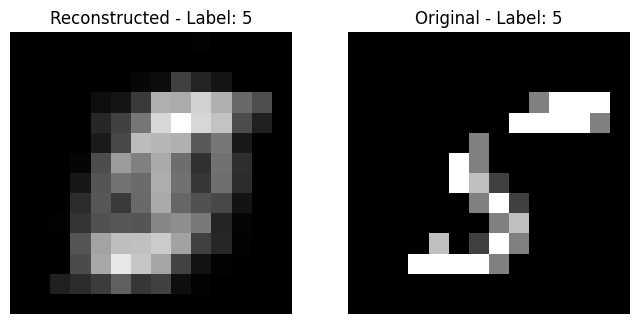

Epoch 15/15, Loss: 1.0112
Applying profile...   success
Sweep complete.


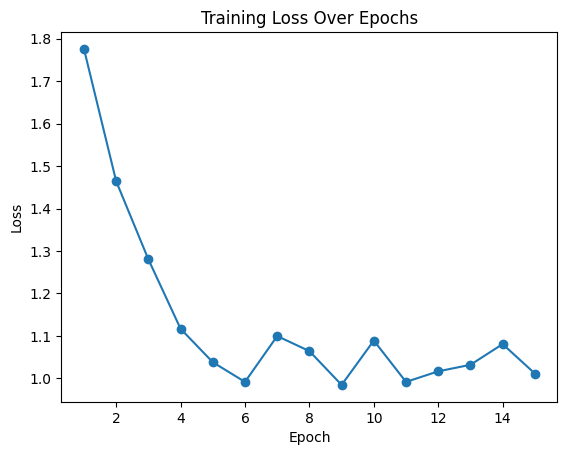

In [ ]:
name_of_experiment = "experiment_CVAE_04"  # Replace with your desired folder name
create_folders(name_of_experiment)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train(model, train_loader, optimizer, epoch, loss_history, beta, lambda_mu, normalization):
    model.train()
    train_loss = 0
    for data in train_loader:
        data, labels = data
        
        condition = F.one_hot(labels, num_classes=CONDITION_DIM).float().to(device)
        recon_batch, mu, logvar = model(data, condition, normalization)
        
        loss = vae_loss(recon_batch, data, mu, logvar, beta, lambda_mu)
        # recon_img = recon_batch[0].view(IMAGE_SIZE, IMAGE_SIZE).cpu().detach().numpy()
        # orig_img = data[0].view(IMAGE_SIZE, IMAGE_SIZE).cpu().detach().numpy()
        # plt.figure(figsize=(8, 4))
        # plt.subplot(1, 2, 1)
        # plt.imshow(recon_img, cmap='gray')
        # plt.title(f'Reconstructed - Label: {labels[0].item()}')
        # plt.axis('off')
        
        # plt.subplot(1, 2, 2)
        # plt.imshow(orig_img, cmap='gray')
        # plt.title(f'Original - Label: {labels[0].item()}')
        # plt.axis('off')
        
        # plt.show()

        optimizer.zero_grad()
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_epoch_loss = train_loss / len(train_loader.dataset)
    loss_history.append(avg_epoch_loss)  # Store the average loss in the history

        
interval_images = 1

model = VAE().to(device)
checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_init.pth', map_location=torch.device('cpu'))
state_dict = checkpoint['model_state_dict']
model.load_state_dict(state_dict, strict=True)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
model.train()

def lr_lambda(epoch):
    if epoch < 15:
        return 1          # 0.008 * 1.0 = 0.008 for epochs 0-9
    elif epoch < 25:
        return 0.5          # 0.008 * 0.25 = 0.002 for epochs 10-19
    elif epoch < 35:
        return 0.25         # 0.008 * 0.125 = 0.001 for epochs 20-29
    else:
        return 0.01        # 0.008 * 0.0125 = 0.0001 for epoch 30 and beyond
from torch.optim.lr_scheduler import LambdaLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Create the learning rate scheduler using LambdaLR
scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

import pandas as pd  # For saving data to CSV

loss_history = []

beta = 1.2
lambda_mu =60

for epoch in range(EPOCHS):
    #beta = 
    train(model, train_loader, optimizer, epoch, loss_history, beta, lambda_mu, normalization[1] )
    avg_loss = loss_history[-1]  # Get the most recent average loss
    print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss:.4f}")
    
    # Save checkpoint after each epoch (optional)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss
    }
    torch.save(checkpoint, f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint{epoch}.pth')

    # Perform measurement every 10 epochs
    if (epoch + 1) % 1 == 0:
        peaks_decopling = np.ones(n_comblines[1])
        phases_decopling = np.zeros(n_comblines[1])
        channels_decopling = np.ones(n_comblines[1])

        apply_waveshaper_profile(comblines[1], peaks_decopling, phases_decopling, channels_decopling, plot = False)
        wav, power = osa.perform_measurement_OSA(center=np.mean(comblines[1])/2, span=(np.max(comblines[1])-np.mean(comblines[1]))+0.5, level=0.006, sensitivity = "high3", resolution = 0.02)
        osa.save_trace(filename=f"./data_runs/{name_of_experiment}/stability/trace_data_{epoch}.csv")
        normalization[1] = np.max(power)
        # Store power at specified indices


# Plot the loss over epochs
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.savefig(f"./data_runs/{name_of_experiment}/loss.png")
plt.show()


Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.


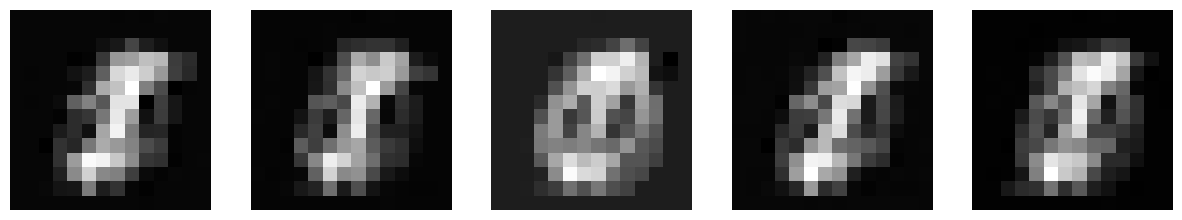

In [9]:
def generate_images(model, number_of_images, desired_digit):
    model.eval()
    samples_new = []

    with torch.no_grad():
        digit_tensor = torch.tensor([desired_digit])
        condition = F.one_hot(digit_tensor, num_classes=CONDITION_DIM).float().to(device)
        
        for i in range(number_of_images):
            z = torch.randn(1, LATENT_DIM).to(device)  # Sample random latent variables
            
            sample = model.decode(z, condition, normalization[1]).cpu()            # sample shape is [784]
            # If needed, unsqueeze to add a batch dimension, so sample becomes [1, 784]
            if sample.dim() == 1:
                sample = sample.unsqueeze(0)
            samples_new.append(sample)
    
    # Stack along the batch dimension (dim=0)
    samples_new = torch.stack(samples_new, dim=0) 
    new_data = samples_new.view(number_of_images, 1, IMAGE_SIZE, IMAGE_SIZE)
    torch.save(new_data, os.path.join(f"./data_runs/{name_of_experiment}", f"new_data{desired_digit}.pt"))
    return new_data

# Generate and visualize new images
number_of_images = 5
desired_digit = 1
generated_images = generate_images(model, number_of_images, desired_digit)

# Plot the generated images
fig, axes = plt.subplots(1, number_of_images, figsize=(15, 5))
for i in range(number_of_images):
    axes[i].imshow(generated_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.savefig(f"./data_runs/{name_of_experiment}/new_image{desired_digit}.png")

plt.show()



Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.
Applying profile...   success
Sweep complete.


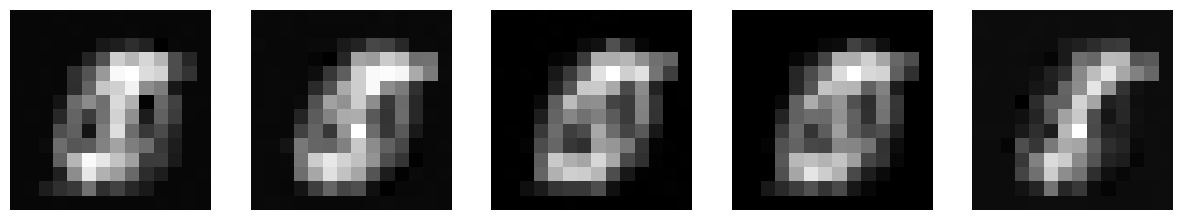

In [10]:
# Generate and visualize new images
number_of_images = 5
desired_digit = 5
generated_images = generate_images(model, number_of_images, desired_digit)

# Plot the generated images
fig, axes = plt.subplots(1, number_of_images, figsize=(15, 5))
for i in range(number_of_images):
    axes[i].imshow(generated_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.savefig(f"./data_runs/{name_of_experiment}/new_image{desired_digit}.png")

plt.show()

Applying profile...   success
Sweep complete.


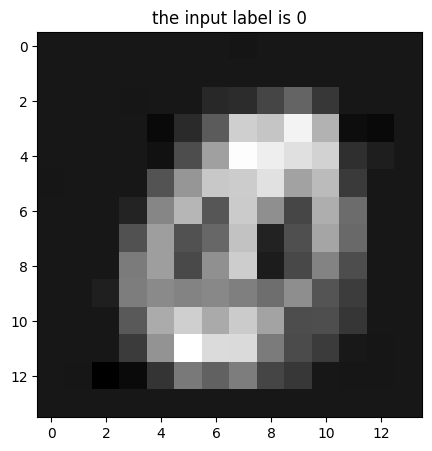

Applying profile...   success
Sweep complete.


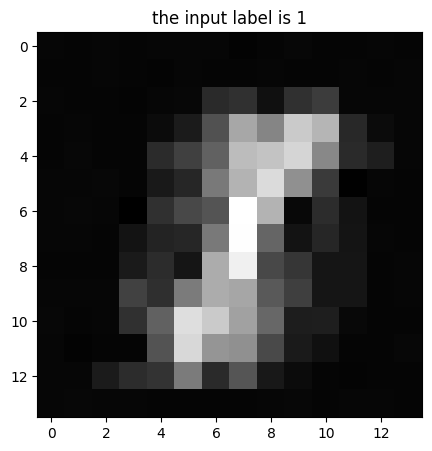

Applying profile...   success
Sweep complete.


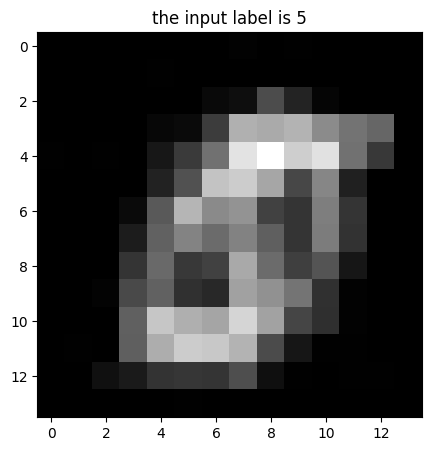

In [11]:
# Generate and visualize new images
for desired_digit in desired_digits:
    number_of_images = 1
    generated_images = generate_images(model, number_of_images, desired_digit)

    # Plot the generated images
    fig, axes = plt.subplots(1, number_of_images, figsize=(15, 5))
    plt.imshow(generated_images[0].squeeze(), cmap='gray')
    plt.title(f"the input label is {desired_digit}")
    plt.savefig(f"./data_runs/{name_of_experiment}/new_image_individual{desired_digit}.png")

    plt.show()

In [14]:
# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

Disconnecting from waveshaper...   waveshaper not found
Deliting waveshaper...   waveshaper not found
Connection closed


C:\Users\ws-server\AppData\Local\Temp\ipykernel_12692\2995232318.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path)['model_state_dict']


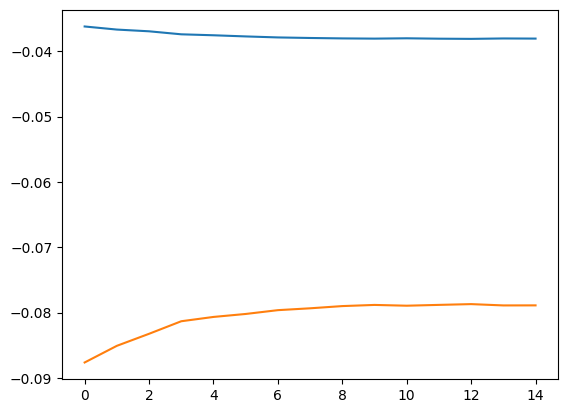

In [12]:
import torch

# Load the .pth file
# checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint4.pth', map_location=torch.device('cpu'))
# print(type(checkpoint))
# a = checkpoint['model_state_dict']
# torch.mean(a["fc_mu.weight"]).item()

directory = f"./data_runs/{name_of_experiment}/checkpoints"

# Get a sorted list of checkpoint files in numerical order
file_list = sorted(
    [f for f in os.listdir(directory) if f.startswith("model_checkpoint") and f.endswith(".pth")],
    key=lambda x: int(x.split("checkpoint")[1].split(".pth")[0])
)
# Initialize a list to store the losses
average_mu_layer_weight = []
average_mu_layer_bias = []

# Loop through all the checkpoint files in the directory
for filename in file_list:
    if filename.endswith('.pth'):
        # Construct the full file path
        file_path = os.path.join(directory, filename)
        
        # Load the checkpoint
        checkpoint = torch.load(file_path)['model_state_dict']
                
        # Extract the loss value (assuming it is stored with the key 'loss')
        if "fc3.weight" in checkpoint:
            weight = checkpoint["fc3.weight"]

            average_mu_layer_weight.append(torch.mean(weight).item())
        else:
            print(f"Loss not found in {filename}")

        if "fc3.bias" in checkpoint:
            bias = checkpoint["fc3.bias"]
            average_mu_layer_bias.append(torch.mean(bias).item())
        else:
            print(f"Accuracy not found in {filename}")

plt.plot(average_mu_layer_weight)
plt.plot(average_mu_layer_bias)


In [ ]:
# Load the .pth file
checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint4.pth', map_location=torch.device('cpu'))
print(type(checkpoint))
a = checkpoint['model_state_dict']
a["fc3.weight"]

<class 'dict'>


C:\Users\ws-server\AppData\Local\Temp\ipykernel_10456\1146760800.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'./data_runs/{name_of_experimen

tensor([[-0.0328, -0.0340, -0.0330,  ..., -0.0296, -0.0312, -0.0354],
        [-0.0338, -0.0348, -0.0322,  ..., -0.0309, -0.0304, -0.0325],
        [-0.0337, -0.0328, -0.0322,  ..., -0.0307, -0.0325, -0.0343],
        ...,
        [-0.0333, -0.0330, -0.0327,  ..., -0.0312, -0.0326, -0.0332],
        [-0.0350, -0.0335, -0.0329,  ..., -0.0312, -0.0317, -0.0341],
        [-0.0338, -0.0356, -0.0332,  ..., -0.0296, -0.0332, -0.0340]])